# Imports

In [2]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.SR_models import SR_go_ww
from ageing_packages.utils import sr_utils as utils
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib as mpl

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger


import pandas as pd
import sys, os, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import thresholds_functions as th
mpl.rcParams['pdf.fonttype'] = 42  # Ensures TrueType fonts, which stay as text


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### loading supercentenarian data

from grg

In [122]:
import pandas as pd

# Load the file
file_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/super_centenarians.txt'

# Read the tab-separated file, skipping the first empty line
df = pd.read_csv(file_path, sep='\t', skiprows=1)

# Select only the columns you want
df = df[['Born', 'Died', 'Years', 'Days', 'Sex']]

# Convert Born and Died to just years
df['Born'] = pd.to_datetime(df['Born']).dt.year
df['Died'] = pd.to_datetime(df['Died']).dt.year


from IDL

In [200]:
file_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/IDL_COMPLETE_Death_105.xlsx'

# Load the IDL data
idl_df = pd.read_excel(file_path)
# Calculate age at death using birth and death dates
birth_dates = pd.to_datetime(dict(year=idl_df['BIRTH_YEAR'],
                                  month=idl_df['BIRTH_MONTH'],
                                  day=idl_df['BIRTH_DAY']))
death_dates = pd.to_datetime(dict(year=idl_df['DEATH_YEAR'],
                                  month=idl_df['DEATH_MONTH'],
                                  day=idl_df['DEATH_DAY']))
idl_df['age_at_death'] = (death_dates - birth_dates).dt.days / 365.25
# Remove rows where VALIDATION is "SAMPLE OUT"
# idl_df = idl_df[idl_df['VALIDATION'] != 'SAMPLE OUT']

idl_df.head()


,COUNTRY,IDL_ID,AGEYEARS,DAYSSINCEBD,AGEDAYS,SEX,BIRTH_DAY,BIRTH_MONTH,BIRTH_YEAR,DEATH_DAY,DEATH_MONTH,DEATH_YEAR,BIRTH_COUNTRY,BIRTH_LOCALITY,DEATH_COUNTRY,DEATH_LOCALITY,VALIDATION,age_at_death
0,FRA,FRA1911202414992,113,139,41413,F,10.0,8.0,1911,27.0,12.0,2024,FRA,FRK23,FRA,FRL06,YES,113.382615
1,FRA,FRA1912202414989,112,92,41000,F,18.0,9.0,1912,19.0,12.0,2024,FRA,FRG03,FRA,FRJ12,YES,112.251882
2,FRA,FRA1912202414988,112,38,40946,F,3.0,5.0,1912,10.0,6.0,2024,FRA,FRI13,FRA,FRI15,YES,112.104038
3,FRA,FRA1911202414990,112,234,41142,F,25.0,11.0,1911,16.0,7.0,2024,FRA,FRE21,FRA,FRK28,YES,112.640657
4,FRA,FRA1911202414991,112,286,41194,F,26.0,6.0,1911,7.0,4.0,2024,FRA,FRM02,FRA,FR101,YES,112.783025


### left-truncation filtering (still right truncation bias)

 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/3143765044.py:106: RuntimeWarning: divide by zero encountered in divide
  weights_105 = 1.0 / (np.array(sem_remaining_105)[valid_mask_105]**2)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/polynomial.py:664: RuntimeWarning: invalid value encountered in multiply
  rhs *= w
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/lib/polynomial.py:668: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

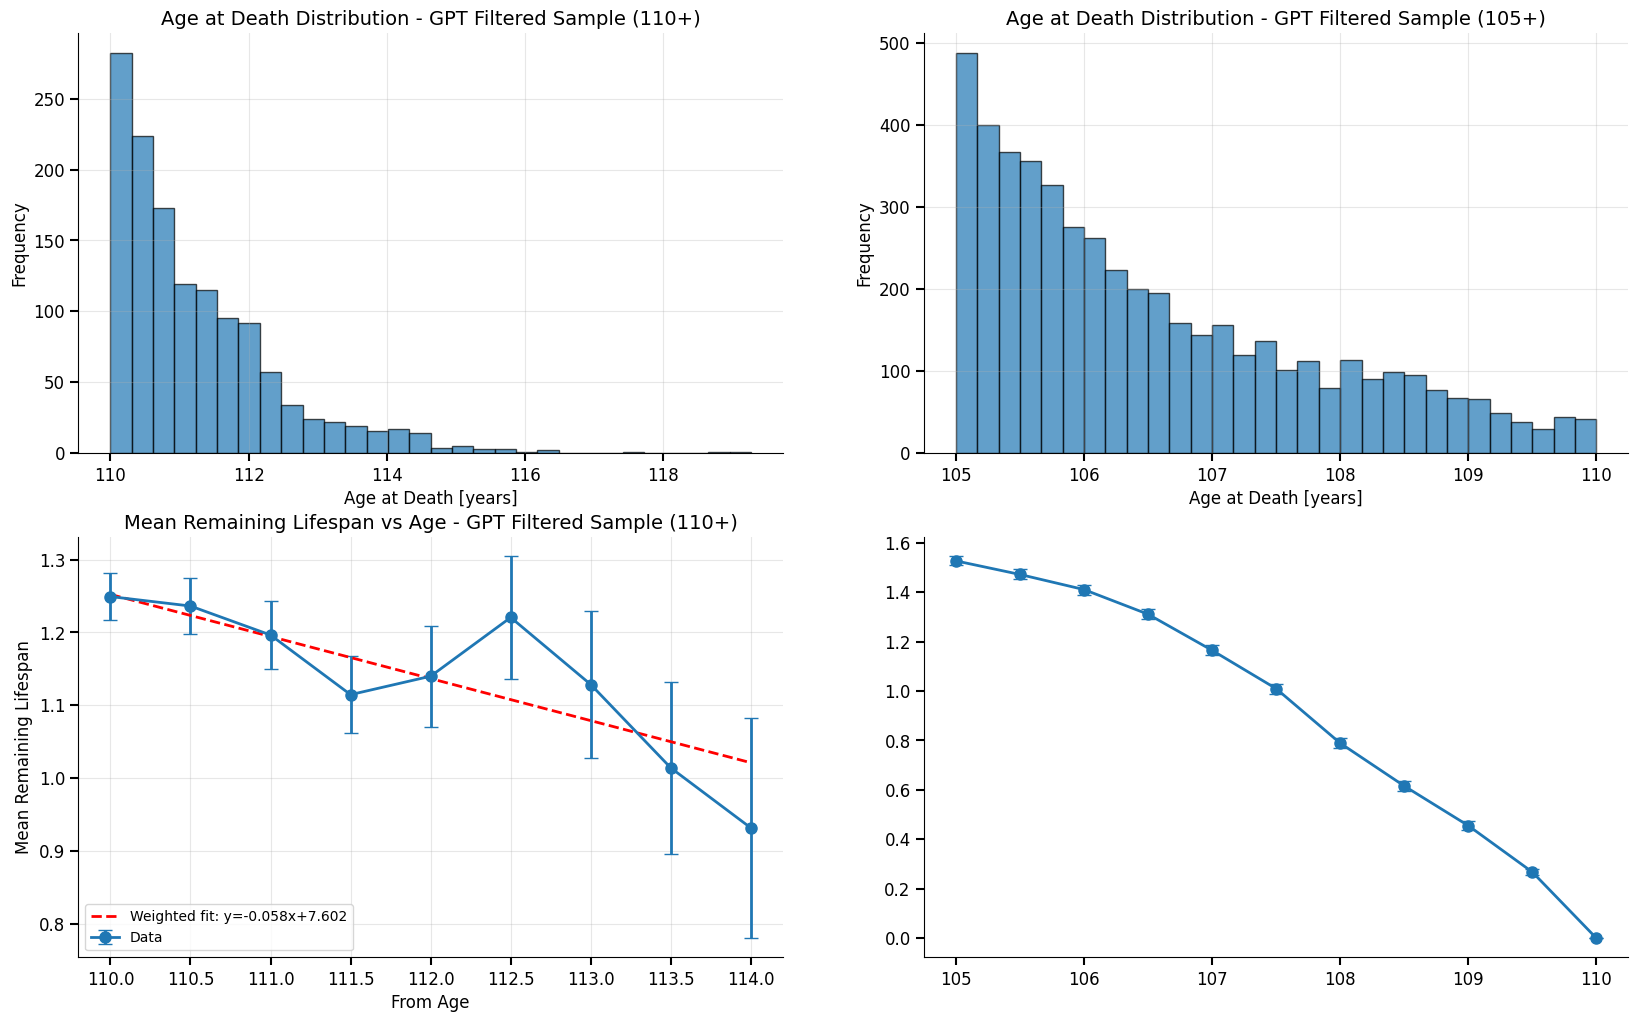

In [131]:
df_105_gpt = pd.read_csv('saved_results/idl_clean_105.csv')
df_110_gpt = pd.read_csv('saved_results/idl_clean_110.csv')


df_105_gpt['age_at_death'] = df_105_gpt['AGEYEARS'] + df_105_gpt['DAYSSINCEBD'] / 365

# Load and process real data from 110+ dataset
df_110_gpt['age_at_death'] = df_110_gpt['AGEYEARS'] + df_110_gpt['DAYSSINCEBD'] / 365


# Create figure with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# TOP ROW: Histograms
# Top left: Histogram for 110+ dataset
ax1.hist(df_110_gpt['age_at_death'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Age at Death [years]', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Age at Death Distribution - GPT Filtered Sample (110+)', fontsize=14)
ax1.grid(True, alpha=0.3)

# Top right: Histogram for 105+ dataset
ax2.hist(df_105_gpt['age_at_death'], bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Age at Death [years]', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Age at Death Distribution - GPT Filtered Sample (105+)', fontsize=14)
ax2.grid(True, alpha=0.3)

# BOTTOM ROW: Mean remaining lifespan analysis with bootstrap error bars
n_bootstrap = 1000

# Bottom left: 110+ dataset with thresholds from 110 to 114
ages_110 = np.arange(110, 114.5, 0.5)
mean_remaining_110 = []
sem_remaining_110 = []

for age in ages_110:
    subset = df_110_gpt[df_110_gpt['age_at_death'] >= age]['age_at_death']
    if len(subset) > 0:
        # Calculate observed mean
        mean_val = subset.mean() - age
        mean_remaining_110.append(mean_val)
        
        # Bootstrap to get SEM
        bootstrap_means = []
        for _ in range(n_bootstrap):
            bootstrap_sample = subset.sample(n=len(subset), replace=True)
            bootstrap_means.append(bootstrap_sample.mean() - age)
        sem_remaining_110.append(np.std(bootstrap_means))
    else:
        mean_remaining_110.append(np.nan)
        sem_remaining_110.append(np.nan)

ax3.errorbar(ages_110, mean_remaining_110, yerr=sem_remaining_110, 
             marker='o', linewidth=2, markersize=8, capsize=5, label='Data')

# Add weighted linear fit for 110+ dataset
valid_mask_110 = ~np.isnan(mean_remaining_110) & ~np.isnan(sem_remaining_110)
if np.sum(valid_mask_110) > 1:
    x_valid_110 = ages_110[valid_mask_110]
    y_valid_110 = np.array(mean_remaining_110)[valid_mask_110]
    weights_110 = 1.0 / (np.array(sem_remaining_110)[valid_mask_110]**2)
    
    # Weighted linear fit
    coeffs_110 = np.polyfit(x_valid_110, y_valid_110, 1, w=weights_110)
    fit_line_110 = np.poly1d(coeffs_110)
    ax3.plot(ages_110, fit_line_110(ages_110), 'r--', linewidth=2, 
             label=f'Weighted fit: y={coeffs_110[0]:.3f}x+{coeffs_110[1]:.3f}')

ax3.set_xlabel('From Age', fontsize=12)
ax3.set_ylabel('Mean Remaining Lifespan', fontsize=12)
ax3.set_title('Mean Remaining Lifespan vs Age - GPT Filtered Sample (110+)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend()

# Bottom right: 105+ dataset with thresholds from 105 to 114
ages_105 = np.arange(105, 114.5, 0.5)
mean_remaining_105 = []
sem_remaining_105 = []

for age in ages_105:
    subset = df_105_gpt[df_105_gpt['age_at_death'] >= age]['age_at_death']
    if len(subset) > 0:
        # Calculate observed mean
        mean_val = subset.mean() - age
        mean_remaining_105.append(mean_val)
        
        # Bootstrap to get SEM
        bootstrap_means = []
        for _ in range(n_bootstrap):
            bootstrap_sample = subset.sample(n=len(subset), replace=True)
            bootstrap_means.append(bootstrap_sample.mean() - age)
        sem_remaining_105.append(np.std(bootstrap_means))
    else:
        mean_remaining_105.append(np.nan)
        sem_remaining_105.append(np.nan)

ax4.errorbar(ages_105, mean_remaining_105, yerr=sem_remaining_105, 
             marker='o', linewidth=2, markersize=8, capsize=5, label='Data')

# Add weighted linear fit for 105+ dataset
valid_mask_105 = ~np.isnan(mean_remaining_105) & ~np.isnan(sem_remaining_105)
if np.sum(valid_mask_105) > 1:
    x_valid_105 = ages_105[valid_mask_105]
    y_valid_105 = np.array(mean_remaining_105)[valid_mask_105]
    weights_105 = 1.0 / (np.array(sem_remaining_105)[valid_mask_105]**2)
    
    # Weighted linear fit
    coeffs_105 = np.polyfit(x_valid_105, y_valid_105, 1, w=weights_105)
    fit_line_105 = np.poly1d(coeffs_105)
    ax4.plot(ages_105, fit_line_105(ages_105), 'r--', linewidth=2, 
             label=f'Weighted fit: y={coeffs_105[0]:.3f}x+{coeffs_105[1]:.3f}')

ax4.set_xlabel('From Age', fontsize=12)
ax4.set_ylabel('Mean Remaining Lifespan', fontsize=12)
ax4.set_title('Mean Remaining Lifespan vs Age - GPT Filtered Sample (105+)', fontsize=14)
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()


## one 105+ cohort

In [202]:
DAYSPERYEAR = 365.2425

# ----------------------------------------------------------------------
# 1. Metadata windows per country (from IDL PDFs)
#    Bxxx_* are birth years, Dxxx_* are death years.
#    CAN info from the Canada metadata:
#    110+: births 1872–1898, deaths 1983–2009
#    105–109: births 1877–1904, deaths 1985–2009  :contentReference[oaicite:0]{index=0}
# ----------------------------------------------------------------------

META = {
    # England & Wales :contentReference[oaicite:1]{index=1}
    "EAW": {
        "B105_min": 1890, "B105_max": 1909,
        "D105_min": 1999, "D105_max": 2014,
        "B110_min": 1856, "B110_max": 1910,
        "D110_min": 1968, "D110_max": 2020,
    },
    # France :contentReference[oaicite:2]{index=2}
    "FRA": {
        "B105_min": 1870, "B105_max": 1919,
        "D105_min": 1978, "D105_max": 2024,
        "B110_min": 1875, "B110_max": 1914,
        "D110_min": 1987, "D110_max": 2024,
    },
    # Germany :contentReference[oaicite:3]{index=3}
    "DEU": {
        "B105_min": 1881, "B105_max": 1898,
        "D105_min": 1989, "D105_max": 2005,
        "B110_min": 1883, "B110_max": 1894,
        "D110_min": 1994, "D110_max": 2005,
    },
    # Sweden :contentReference[oaicite:4]{index=4}
    "SWE": {
        "B105_min": 1800, "B105_max": 1914,
        "D105_min": 1906, "D105_max": 2024,
        "B110_min": 1874, "B110_max": 1914,
        "D110_min": 1986, "D110_max": 2024,
    },
    # United States :contentReference[oaicite:5]{index=5}
    "USA": {
        "B105_min": 1871, "B105_max": 1899,
        "D105_min": 1979, "D105_max": 2009,
        "B110_min": 1867, "B110_max": 1899,
        "D110_min": 1980, "D110_max": 2010,
    },
    # Norway :contentReference[oaicite:6]{index=6}
    "NOR": {
        "B105_min": 1877, "B105_max": 1899,
        "D105_min": 1986, "D105_max": 2006,
        "B110_min": 1876, "B110_max": 1893,
        "D110_min": 1989, "D110_max": 2004,
    },
    # Belgium :contentReference[oaicite:7]{index=7}
    "BEL": {
        "B105_min": 1870, "B105_max": 1919,
        "D105_min": 1977, "D105_max": 2024,
        "B110_min": 1878, "B110_max": 1912,
        "D110_min": 1990, "D110_max": 2023,
    },
    # Austria :contentReference[oaicite:8]{index=8}
    "AUT": {
        "B105_min": 1893, "B105_max": 1909,
        "D105_min": 2003, "D105_max": 2014,
        "B110_min": 1895, "B110_max": 1902,
        "D110_min": 2005, "D110_max": 2012,
    },
    # Denmark :contentReference[oaicite:9]{index=9}
    "DNK": {
        "B105_min": 1863, "B105_max": 1909,
        "D105_min": 1970, "D105_max": 2014,
        "B110_min": 1884, "B110_max": 1903,
        "D110_min": 1996, "D110_max": 2014,
    },
    # Canada (Quebec) :contentReference[oaicite:10]{index=10}
    "CAN": {
        "B105_min": 1877, "B105_max": 1904,
        "D105_min": 1985, "D105_max": 2009,
        "B110_min": 1872, "B110_max": 1898,
        "D110_min": 1983, "D110_max": 2009,
    },
    # Japan is 110+ only in the metadata we have; skip it for 105+ NPMLE
}

# ----------------------------------------------------------------------
# 2. Compute a single birth-year band per country for 105–114
# ----------------------------------------------------------------------

def compute_birth_band(meta, age_min=105, age_max=114):
    """
    Given metadata dict for one country with keys
      B105_min, B105_max, D105_min, D105_max,
      B110_min, B110_max, D110_min, D110_max
    compute a single birth-year band [B_low, B_high] such that:
      - 105th birthday lies inside 105-109 window,
      - 110th birthday lies inside 110+ window,
      - age range [age_min, age_max] lies inside the union of the death windows,
      - and we stay inside the original IDL birth ranges.

    Uses only years, because the metadata are year-based.
    Returns (B_low, B_high) as ints, or None if the intersection is empty.
    """
    B105_min = meta["B105_min"]; B105_max = meta["B105_max"]
    D105_min = meta["D105_min"]; D105_max = meta["D105_max"]
    B110_min = meta["B110_min"]; B110_max = meta["B110_max"]
    D110_min = meta["D110_min"]; D110_max = meta["D110_max"]

    # Overall 105+ death window for this country in calendar years
    D_min = min(D105_min, D110_min)
    D_max = max(D105_max, D110_max)

    # Require 105th birthday inside 105-109 window
    low_105  = D105_min - 105
    high_105 = D105_max - 105

    # Require 110th birthday inside 110+ window
    low_110  = D110_min - 110
    high_110 = D110_max - 110

    # Require the entire age_min-age_max band to lie inside [D_min, D_max]
    low_band  = D_min - age_min
    high_band = D_max - age_max

    B_low = max(low_105, low_110, low_band, B105_min, B110_min)
    B_high = min(high_105, high_110, high_band, B105_max, B110_max)

    if B_low > B_high:
        return None
    return int(B_low), int(B_high)

# Quick sanity check on bands

for c, meta in META.items():
    print(c, compute_birth_band(meta))




EAW (1894, 1906)
FRA (1877, 1910)
DEU (1884, 1891)
SWE (1876, 1910)
USA (1874, 1896)
NOR (1881, 1892)
BEL (1880, 1910)
AUT (1898, 1900)
DNK (1886, 1900)
CAN (1880, 1895)


In [203]:
import pandas as pd
import numpy as np
from datetime import datetime

DAYSPERYEAR = 365.2425

def load_idl_and_build_trimmed(path_xlsx, META, age_min=105, age_max=114):
    """
    path_xlsx: IDL_COMPLETE_Death_105.xlsx
    META: dict of country -> metadata, including B105_*,D105_*,B110_*,D110_*.
    age_min, age_max: minimal and maximal ages you want clean support for.

    Returns:
      df_trim: dataframe restricted to 105+ in intersection birth bands,
      bands:   dict country -> (B_low,B_high) used.
    """
    df = pd.read_excel(path_xlsx, sheet_name=0)

    # Keep only age-validated records
    val = df["VALIDATION"].astype(str).str.upper()
    df = df[val.isin(["YES", "EXHAUSTIVE"])].copy()

    # Build full dates from year, month, day
    df["BIRTHDATE"] = pd.to_datetime(
        dict(
            year=df["BIRTH_YEAR"],
            month=df["BIRTH_MONTH"],
            day=df["BIRTH_DAY"]
        ),
        errors="coerce"
    )
    df["DEATHDATE"] = pd.to_datetime(
        dict(
            year=df["DEATH_YEAR"],
            month=df["DEATH_MONTH"],
            day=df["DEATH_DAY"]
        ),
        errors="coerce"
    )

    # Compute age at death in years from full dates
    df["AGEYRS"] = (df["DEATHDATE"] - df["BIRTHDATE"]).dt.days / DAYSPERYEAR

    # Keep 105+ (in years)
    df = df[df["AGEYRS"] >= age_min].copy()

    # Compute birth-year bands from metadata
    bands = {}
    for c, meta in META.items():
        band = compute_birth_band(meta, age_min=age_min, age_max=age_max)
        if band is not None:
            bands[c] = band

    # Apply cohort filter based on birth year
    keep = []
    for idx, row in df.iterrows():
        c = row["COUNTRY"]
        if c not in bands:
            keep.append(False)
            continue
        B_low, B_high = bands[c]
        by = row["BIRTH_YEAR"]
        keep.append((by >= B_low) and (by <= B_high))

    df_trim = df[keep].copy()
    return df_trim, bands


# ----------------------------------------------------------------------
# 4. Add truncation bounds [L_i, U_i] in age (years) for each person
# ----------------------------------------------------------------------

def add_truncation_bounds_dates(df_trim, META, age_min=105):
    """
    df_trim: trimmed 105+ dataframe from load_idl_and_build_trimmed,
             must have BIRTHDATE column and COUNTRY column.
    META:   metadata dict used to construct per-country calendar windows.

    Uses birthdate and synthetic calendar dates for each country's
    observation window to compute truncation bounds [L_i, U_i] in age (years).

    - For each country c, define:
        Cmin_date = Jan 1 of min(D105_min, D110_min)
        Cmax_date = Dec 31 of max(D105_max, D110_max)

    - For each person i in country c:
        L_raw = age at Cmin_date
        U_raw = age at Cmax_date
        L_i   = max(age_min, L_raw)
        U_i   = U_raw

    Returns a copy of df_trim with L_bound and U_bound columns, dropping rows
    where U_bound <= L_bound or BIRTHDATE is missing.
    """
    # Build calendar date windows from year-level metadata
    C_windows = {}
    for c, meta in META.items():
        D105_min = meta["D105_min"]; D105_max = meta["D105_max"]
        D110_min = meta["D110_min"]; D110_max = meta["D110_max"]
        D_min = min(D105_min, D110_min)
        D_max = max(D105_max, D110_max)
        Cmin_date = datetime(D_min, 1, 1)
        Cmax_date = datetime(D_max, 12, 31)
        C_windows[c] = (Cmin_date, Cmax_date)

    L_list = []
    U_list = []

    for idx, row in df_trim.iterrows():
        c = row["COUNTRY"]
        if c not in C_windows:
            L_list.append(np.nan)
            U_list.append(np.nan)
            continue

        Cmin_date, Cmax_date = C_windows[c]
        birth = row["BIRTHDATE"]

        if pd.isna(birth):
            L_list.append(np.nan)
            U_list.append(np.nan)
            continue

        # Age at the start and end of the observation window, in years
        L_raw = (Cmin_date - birth).days / DAYSPERYEAR
        U_raw = (Cmax_date - birth).days / DAYSPERYEAR

        # Left truncation: at least age_min, and at least L_raw
        L = max(age_min, L_raw)
        U = U_raw

        L_list.append(L)
        U_list.append(U)

    df_out = df_trim.copy()
    df_out["L_bound"] = L_list
    df_out["U_bound"] = U_list

    # Drop rows where we do not have a meaningful truncation interval
    df_out = df_out[df_out["U_bound"] > df_out["L_bound"]].copy()
    return df_out

# ----------------------------------------------------------------------
# 5. NPMLE for doubly truncated data
# ----------------------------------------------------------------------

def npmle_double_trunc(T, L, U, max_iter=1000, tol=1e-8, return_extra=False):
    """
    Nonparametric MLE of F(T) from i.i.d. observations T_i subject to
    double truncation intervals [L_i, U_i].

    T, L, U: 1D arrays of same length.
    Returns:
      t_vals, p_hat
    If return_extra=True, also returns:
      M:     truncation matrix (n x m, bool),
      inv:   index of T_i in t_vals for each i
    """
    T = np.asarray(T, float)
    L = np.asarray(L, float)
    U = np.asarray(U, float)
    assert T.shape == L.shape == U.shape

    # Unique support points t_j and indices inv s.t. T_i = t_vals[inv[i]]
    t_vals, inv = np.unique(T, return_inverse=True)
    m = len(t_vals)
    n = len(T)

    # Counts per support point
    counts = np.bincount(inv, minlength=m).astype(float)

    # Truncation matrix M_ij = 1 if t_j in [L_i, U_i]
    M = (t_vals[None, :] >= L[:, None]) & (t_vals[None, :] <= U[:, None])

    # Initialize p_j uniform
    p = np.full(m, 1.0 / m, dtype=float)

    for it in range(max_iter):
        # G_i = sum_j M_ij * p_j
        G = M.dot(p)
        if np.any(G <= 0):
            raise RuntimeError("Some G_i <= 0; truncation pattern incompatible with p")

        # denom_j = sum_i M_ij / G_i
        denom = (M / G[:, None]).sum(axis=0)

        new_p = counts / denom
        new_p /= new_p.sum()

        delta = np.max(np.abs(new_p - p))
        p = new_p
        if delta < tol:
            break

    if return_extra:
        return t_vals, p, M, inv
    return t_vals, p

# ----------------------------------------------------------------------
# 6. Mean remaining life curve m(u) from NPMLE
# ----------------------------------------------------------------------

def mean_remaining_life_curve(t_vals, p, u_grid):
    """
    t_vals: sorted ages (support points)
    p:      probability masses (sum 1)
    u_grid: list or array of thresholds (e.g. range(105,115))

    Returns DataFrame with columns: u, mrl_hat
    """
    t_vals = np.asarray(t_vals, float)
    p = np.asarray(p, float)

    rows = []
    for u in u_grid:
        mask = t_vals >= u
        if not np.any(mask):
            rows.append({"u": float(u), "mrl_hat": np.nan})
            continue
        S_u = p[mask].sum()
        num = np.sum((t_vals[mask] - u) * p[mask])
        mrl = num / S_u
        rows.append({"u": float(u), "mrl_hat": float(mrl)})
    return pd.DataFrame(rows)

# ----------------------------------------------------------------------
# 7. Naive empirical mean remaining life (for comparison)
# ----------------------------------------------------------------------

def naive_mrl(df_trunc, u_grid):
    """
    Naive mean(T - u | T >= u) ignoring truncation, just for comparison.
    df_trunc must have AG EYRS column.
    """
    ages = df_trunc["AGEYRS"].values
    rows = []
    for u in u_grid:
        y = ages[ages >= u] - u
        if y.size == 0:
            rows.append({"u": float(u), "mrl_naive": np.nan})
        else:
            rows.append({"u": float(u), "mrl_naive": float(y.mean())})
    return pd.DataFrame(rows)

# ----------------------------------------------------------------------
# 8. Bootstrap for the NPMLE MRL curve
# ----------------------------------------------------------------------

def bootstrap_mrl(T, L, U, u_grid, B=200, max_iter=500, tol=1e-7, random_state=None):
    """
    Parametric-style bootstrap for the NPMLE under double truncation.

    T, L, U: original observed ages and truncation bounds.
    u_grid:  thresholds where you want m(u).
    B:       number of bootstrap replicates (200-500 is reasonable, but slow).
    Returns:
      mrl_df: DataFrame with columns
              u, mrl_hat (original), mrl_lo, mrl_hi (2.5% and 97.5%)
    """
    rng = np.random.default_rng(random_state)

    # Fit NPMLE once and keep t_vals, p_hat, and M
    t_vals, p_hat, M, inv = npmle_double_trunc(
        T, L, U, max_iter=max_iter, tol=tol, return_extra=True
    )

    # Original MRL
    base_mrl_df = mean_remaining_life_curve(t_vals, p_hat, u_grid)

    # Precompute, for each individual i, the indices of support points allowed by its truncation
    allowed_idx = [np.where(M[i])[0] for i in range(M.shape[0])]

    n = len(T)
    mrl_boot = np.zeros((B, len(u_grid)), dtype=float)

    for b in range(B):
        # Simulate T* for each individual:
        T_star = np.empty_like(T, dtype=float)
        for i in range(n):
            idxs = allowed_idx[i]
            # probabilities proportional to p_hat within [L_i, U_i]
            w = p_hat[idxs]
            s = w.sum()
            if s <= 0:
                # if this happens, something is inconsistent; skip this replicate
                T_star[i] = T[i]
                continue
            w = w / s
            j = rng.choice(idxs, p=w)
            T_star[i] = t_vals[j]

        # Refit NPMLE on the bootstrap sample
        try:
            t_star, p_star = npmle_double_trunc(
                T_star, L, U, max_iter=max_iter, tol=tol, return_extra=False
            )
        except RuntimeError:
            # Fallback: if NPMLE fails, copy original
            t_star, p_star = t_vals, p_hat

        mrl_star_df = mean_remaining_life_curve(t_star, p_star, u_grid)
        mrl_boot[b, :] = mrl_star_df["mrl_hat"].values

    # Compute percentile intervals per u
    lo = np.percentile(mrl_boot, 2.5, axis=0)
    hi = np.percentile(mrl_boot, 97.5, axis=0)

    out = base_mrl_df.copy()
    out["mrl_lo"] = lo
    out["mrl_hi"] = hi
    return out

# ----------------------------------------------------------------------
# 9. Driver: run the whole pipeline
# ----------------------------------------------------------------------



In [204]:
idl_path = "/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/IDL_COMPLETE_Death_105.xlsx"  # adjust path

age_min = 105
age_max = 114
u_grid = list(range(age_min, age_max + 1))

# 1) Build trimmed 105+ cohort from metadata, with ages from full dates
df_trim, bands = load_idl_and_build_trimmed(idl_path, META, age_min=age_min, age_max=age_max)
print("Trimmed 105+ cohort size:", df_trim.shape[0])
print("Birth bands used per country:", bands)

# 2) Add truncation bounds using full birthdate and calendar windows
df_trunc = add_truncation_bounds_dates(df_trim, META, age_min=age_min)

# 3) Prepare arrays for NPMLE
T = df_trunc["AGEYRS"].values
L = df_trunc["L_bound"].values
U = df_trunc["U_bound"].values

# 4) Fit NPMLE and compute MRL curve
t_vals, p_hat = npmle_double_trunc(T, L, U)
mrl_df = mean_remaining_life_curve(t_vals, p_hat, u_grid)

# 5) Naive MRL for comparison
naive_df = naive_mrl(df_trunc, u_grid)

# 6) Bootstrap CIs
mrl_boot_df = bootstrap_mrl(T, L, U, u_grid, B=200, random_state=123)

# Merge
mrl_all = (
    mrl_boot_df
    .merge(naive_df, on="u", how="left")
    .merge(mrl_df.rename(columns={"mrl_hat": "mrl_hat_noCI"}), on="u", how="left")
)

print(mrl_all)


Trimmed 105+ cohort size: 3293
Birth bands used per country: {'EAW': (1894, 1906), 'FRA': (1877, 1910), 'DEU': (1884, 1891), 'SWE': (1876, 1910), 'USA': (1874, 1896), 'NOR': (1881, 1892), 'BEL': (1880, 1910), 'AUT': (1898, 1900), 'DNK': (1886, 1900), 'CAN': (1880, 1895)}
       u   mrl_hat    mrl_lo    mrl_hi  mrl_naive  mrl_hat_noCI
0  105.0  2.311477  2.236544  2.382180   2.306557      2.311477
1  106.0  2.359667  2.268518  2.439339   2.352814      2.359667
2  107.0  2.229030  2.129303  2.327571   2.220064      2.229030
3  108.0  2.022209  1.938690  2.115605   2.010573      2.022209
4  109.0  1.772197  1.677233  1.857863   1.756804      1.772197
5  110.0  1.235018  1.139269  1.343144   1.215709      1.235018
6  111.0  1.144649  0.997984  1.325765   1.110136      1.144649
7  112.0  1.096485  0.861734  1.398762   1.028756      1.096485
8  113.0  1.182284  0.733789  1.791932   1.061206      1.182284
9  114.0  1.166168  0.500442  2.134461   0.970191      1.166168


# go with winners sim

In [297]:
import numpy as np
from scipy.interpolate import interp1d

import model_param_calibrations as mcal

n_sim = 10000
factor = 1.5

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']

# Adjust Xc for the given factor
danish_dict['Xc'] = 0.85 * factor * danish_dict['Xc']

# Create parameter distribution as in your calibrations
danish_param_dist = utils.create_param_distribution_dict(
    params_dict=danish_dict, params='Xc', std=danish_Xc_std,
    n=n_sim, family='None', dist_type='lognormal'
)

# Run the go-with-winners simulation
sim = utils.create_go_ww_simulation(
    params_dict=danish_param_dist, n=n_sim, tmin=0, tmax=200,
    x0=1e-6, dt=0.005, units='years', calc_pdf=False, print_out=True
)



Heterogeneous mode: 50 parameter groups
  Group sizes: min=200, max=200, mean=200.0
  Varying parameters: ['Xc']
Pruned Group 0 at t=147.79
Pruned Group 1 at t=150.65
Pruned Group 2 at t=151.485
Pruned Group 3 at t=152.035
Pruned Group 4 at t=152.635
Pruned Group 5 at t=153.05
Pruned Group 6 at t=153.68
Pruned Group 7 at t=153.87
Pruned Group 8 at t=154.125
Pruned Group 10 at t=154.13
Pruned Group 9 at t=154.415
Pruned Group 13 at t=154.73
Pruned Group 11 at t=155.185
Pruned Group 15 at t=155.215
Pruned Group 12 at t=155.22
Pruned Group 14 at t=155.57
Pruned Group 18 at t=155.8
Pruned Group 17 at t=155.91
Pruned Group 19 at t=156.255
Pruned Group 16 at t=156.28
Pruned Group 22 at t=156.365
Pruned Group 20 at t=156.445
Pruned Group 23 at t=156.56
Pruned Group 24 at t=156.6
Pruned Group 25 at t=156.78
Pruned Group 21 at t=156.8
Pruned Group 29 at t=156.92000000000002
Pruned Group 31 at t=157.43
Pruned Group 26 at t=157.69
Pruned Group 35 at t=157.72
Pruned Group 30 at t=157.735
Pruned Gr

In [298]:
import matplotlib.pyplot as plt

thresholds = np.arange(100, 200, 1)
mean_lifespans = []

n_samples = 1000

for threshold in thresholds:
    # Find the index where tspan is (almost) equal to threshold
    t_idx = np.argmin(np.abs(sim.tspan - threshold))
    t_val = sim.tspan[t_idx]

    # Get survival curve from that index onward, normalized
    surv_from_thresh = sim.survival[t_idx:]
    surv_from_thresh = surv_from_thresh / surv_from_thresh[0]  # start at one

    # Build CDF for sampling conditional on survival to threshold
    cdf_from_thresh = 1 - surv_from_thresh      # CDF(t | T >= threshold)
    tspan_from_thresh = sim.tspan[t_idx:]

    # Enforce monotonicity
    if not np.all(np.diff(cdf_from_thresh) >= -1e-12):
        cdf_from_thresh = np.maximum.accumulate(cdf_from_thresh)

    # Need strictly increasing for interp1d, so offset very small repeated values
    eps = 1e-10
    for i in range(1, len(cdf_from_thresh)):
        if cdf_from_thresh[i] <= cdf_from_thresh[i-1]:
            cdf_from_thresh[i] = cdf_from_thresh[i-1] + eps

    # Do inverse sampling in log space for better tail sampling
    # Avoid log(0) by taking only strictly positive cdf values and matching spans
    # We set a small value for the lower cutoff to avoid log(0)
    min_cdf = np.min(cdf_from_thresh[cdf_from_thresh > 0]) if np.any(cdf_from_thresh > 0) else 1e-12
    cdf_safe = np.copy(cdf_from_thresh)
    cdf_safe[cdf_safe <= 0] = min_cdf

    # Interpolator in log-cdf space
    inv_logcdf_sampler = interp1d(
        np.log(cdf_safe), tspan_from_thresh, kind="linear", 
        fill_value=(tspan_from_thresh[0], tspan_from_thresh[-1]), bounds_error=False
    )

    # Sample uniform values, but in (almost) log-space CDF range 
    # Note: log_cdf runs from log(min_cdf) to log(1) ~0
    samples_u = np.random.uniform(min_cdf, 1, size=n_samples)
    lifespans = inv_logcdf_sampler(np.log(samples_u))
    mean_lifespan = np.mean(lifespans)

    mean_lifespans.append(mean_lifespan)




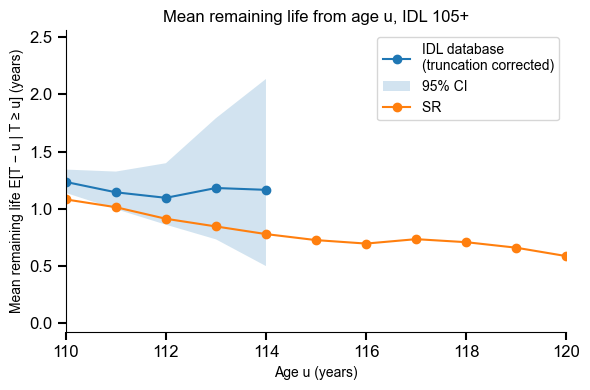

In [299]:
import matplotlib.pyplot as plt

# Suppose you have:
# mrl_boot_df from bootstrap_mrl (columns: u, mrl_hat, mrl_lo, mrl_hi)
# naive_df from naive_mrl (columns: u, mrl_naive)

fig, ax = plt.subplots(figsize=(6,4))

# NPMLE estimate
ax.plot(
    mrl_boot_df["u"],
    mrl_boot_df["mrl_hat"],
    marker="o",
    linestyle="-",
    label="IDL database\n(truncation corrected)"
)

# Bootstrap confidence band
ax.fill_between(
    mrl_boot_df["u"],
    mrl_boot_df["mrl_lo"],
    mrl_boot_df["mrl_hi"],
    alpha=0.2,
    label="95% CI"
)


ax.plot(thresholds, np.array(mean_lifespans) - thresholds, marker='o', label='SR ')


ax.set_xlabel("Age u (years)")
ax.set_ylabel("Mean remaining life E[T − u | T ≥ u] (years)")
ax.set_title("Mean remaining life from age u, IDL 105+")
ax.set_xlim(110, 120)
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()


In [347]:
import numpy as np
from scipy.interpolate import interp1d

import model_param_calibrations as mcal

n_sim = 10000
factor = 1.5

danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']

# Adjust Xc for the given factor
danish_dict['Xc'] = 0.85 * factor * danish_dict['Xc']
danish_dict['eta'] = danish_dict['eta']

# Create parameter distribution as in your calibrations
danish_param_dist = utils.create_param_distribution_dict(
    params_dict=danish_dict, params='Xc', std=danish_Xc_std,
    n=n_sim, family='None', dist_type='lognormal'
)

# Run the go-with-winners simulation
sim = utils.create_go_ww_simulation(
    params_dict=danish_param_dist, n=n_sim, tmin=0, tmax=140,
    x0=1e-6, dt=0.005, units='years', calc_pdf=False, print_out=True
)



Heterogeneous mode: 50 parameter groups
  Group sizes: min=200, max=200, mean=200.0
  Varying parameters: ['Xc']


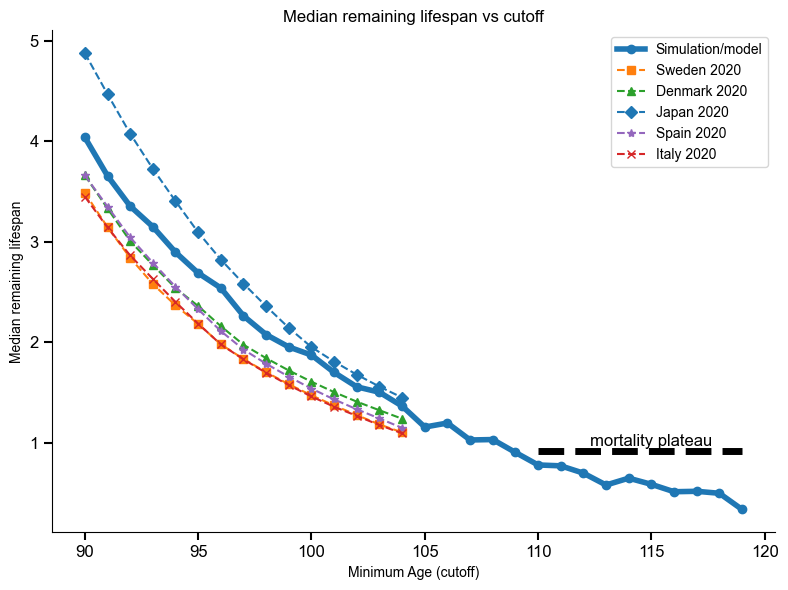

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated (or model) curve
cutoffs = np.arange(90, 120)
medians = []

for cutoff in cutoffs:
    # Find index where sim.tspan is equal to cutoff (or the closest greater or equal value)
    idx = np.searchsorted(sim.tspan, cutoff)
    if idx >= len(sim.tspan) or sim.tspan[idx] < cutoff:
        medians.append(np.nan)
        continue  # skip if cutoff not achievable
    t_c = sim.tspan[idx:]
    s_c = sim.survival[idx:]
    # Normalize survival so s_c[0] = 1
    s_norm = s_c / s_c[0]

    # Find median lifespan above cutoff (where s_norm crosses 0.5)
    median = np.nan
    below = np.where(s_norm <= 0.5)[0]
    if below.size > 0 and below[0] > 0:
        i = below[0]
        # Linear interpolation for median
        x0, x1 = t_c[i-1], t_c[i]
        y0, y1 = s_norm[i-1], s_norm[i]
        if y1 != y0:
            median = x0 + (0.5 - y0) * (x1 - x0) / (y1 - y0)
        else:
            median = x0
    medians.append(median - cutoff if not np.isnan(median) else np.nan)

# Helper to get HMD curve medians for a country, year, cutoff array
def get_country_medians(country_code, year, cutoffs, HMD_class, cutoff_cap=104):
    hmd_obj = HMD_class(country=country_code, gender='both', data_type='period')
    return [
        (hmd_obj.calculate_median_lifespan(year, cutoff) - cutoff) if cutoff <= cutoff_cap
        else np.nan
        for cutoff in cutoffs
    ]

sweden_2020_medians  = get_country_medians('swe', 2019, cutoffs, HMD)
denmark_2020_medians = get_country_medians('dan', 2019, cutoffs, HMD)
japan_2020_medians   = get_country_medians('jpn', 2019, cutoffs, HMD)
spain_2020_medians   = get_country_medians('esp', 2020, cutoffs, HMD)
italy_2020_medians   = get_country_medians('ita', 2020, cutoffs, HMD)

plt.figure(figsize=(8, 6))
plt.plot(cutoffs, medians, marker='o', label='Simulation/model', linewidth=4)
plt.plot(cutoffs, sweden_2020_medians, marker='s', label='Sweden 2020', color='tab:orange', linestyle='--')
plt.plot(cutoffs, denmark_2020_medians, marker='^', label='Denmark 2020', color='tab:green', linestyle='--')
plt.plot(cutoffs, japan_2020_medians, marker='D', label='Japan 2020', color='tab:blue', linestyle='--')
plt.plot(cutoffs, spain_2020_medians, marker='*', label='Spain 2020', color='tab:purple', linestyle='--')
plt.plot(cutoffs, italy_2020_medians, marker='x', label='Italy 2020', color='tab:red', linestyle='--')
plt.hlines(y=0.92, xmin=110, xmax=119, colors='k', linestyles='dashed', label=None, linewidth=5)
plt.text(115, 0.94, "mortality plateau", fontsize=12, ha='center', va='bottom')
plt.xlabel("Minimum Age (cutoff)")
plt.ylabel("Median remaining lifespan")
plt.title("Median remaining lifespan vs cutoff")
plt.legend()
plt.tight_layout()
plt.show()


In [333]:
np.log(2) / 0.75

0.9241962407465937

/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/1584361369.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  deaths = pd.read_csv('/Users/benshenhar/Downloads/FRATNP/STATS/Deaths_1x1.txt', delim_whitespace=True, skiprows=2)
/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/1584361369.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  exposures = pd.read_csv('/Users/benshenhar/Downloads/FRATNP/STATS/Exposures_1x1.txt', delim_whitespace=True, skiprows=2)


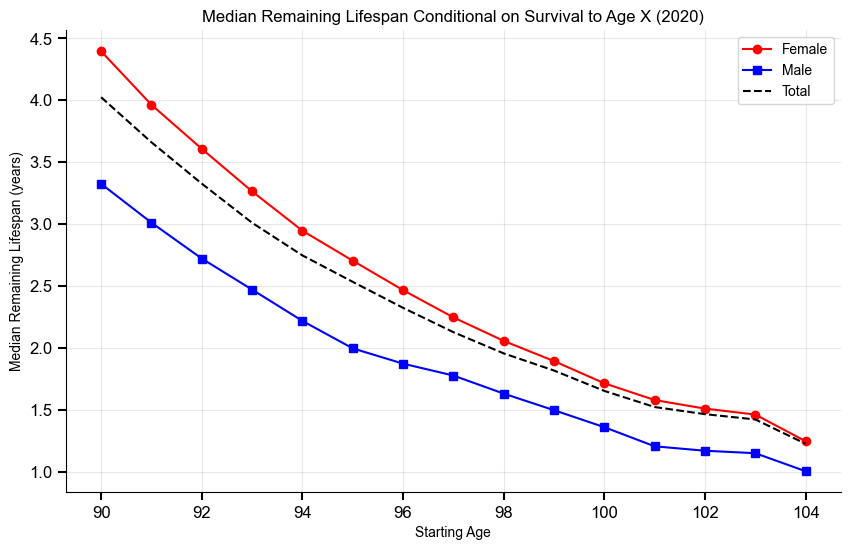

In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
deaths = pd.read_csv('/Users/benshenhar/Downloads/FRATNP/STATS/Deaths_1x1.txt', delim_whitespace=True, skiprows=2)
exposures = pd.read_csv('/Users/benshenhar/Downloads/FRATNP/STATS/Exposures_1x1.txt', delim_whitespace=True, skiprows=2)

# 2. Filter for Year 2020
year = 2020
d_yr = deaths[deaths['Year'] == year].copy()
e_yr = exposures[exposures['Year'] == year].copy()

# 3. Clean 'Age' column (Convert "110+" to 110)
def clean_age(x):
    return 110 if str(x).strip() == '110+' else int(x)

d_yr['Age_Clean'] = d_yr['Age'].apply(clean_age)
e_yr['Age_Clean'] = e_yr['Age'].apply(clean_age)

# Merge Deaths and Exposures
data = pd.merge(d_yr[['Age_Clean', 'Total', 'Female', 'Male']], 
                e_yr[['Age_Clean', 'Total', 'Female', 'Male']], 
                on='Age_Clean', suffixes=('_D', '_E'))
data = data.sort_values('Age_Clean')

# 4. Calculate Rates (Mx) and Probability of Death (qx)
for sex in ['Total', 'Female', 'Male']:
    # Mx = Deaths / Exposures
    data[f'Mx_{sex}'] = data[f'{sex}_D'] / data[f'{sex}_E']
    
    # Physics/Biophysics conversion: qx = 1 - exp(-Mx)
    data[f'qx_{sex}'] = 1 - np.exp(-data[f'Mx_{sex}'].fillna(0))

# 5. Function to calculate Median Lifespan from a specific starting age
def get_median_lifespan(start_age, qx_series, age_series):
    # Slice data starting from current age
    mask = age_series >= start_age
    qs = qx_series[mask].values
    ages = age_series[mask].values
    
    lx = 1.0
    target_lx = 0.5
    
    for i, q in enumerate(qs):
        lx_next = lx * (1 - q)
        
        # If we cross the 0.5 threshold, interpolate
        if lx_next <= target_lx:
            fraction = (lx - target_lx) / (lx - lx_next)
            return ages[i] + fraction
        lx = lx_next
    return np.nan

# 6. Execute for Ages 90-104
results = []
for age in range(90, 105):
    res = {'Age': age}
    for sex in ['Total', 'Female', 'Male']:
        median_life = get_median_lifespan(age, data[f'qx_{sex}'], data['Age_Clean'])
        if pd.isnull(median_life):
            res[sex] = np.nan
        else:
            res[sex] = median_life - age  # Remaining median lifespan
    results.append(res)

df_res = pd.DataFrame(results)

# 7. Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_res['Age'], df_res['Female'], 'r-o', label='Female')
plt.plot(df_res['Age'], df_res['Male'], 'b-s', label='Male')
plt.plot(df_res['Age'], df_res['Total'], 'k--', label='Total')
plt.xlabel('Starting Age')
plt.ylabel('Median Remaining Lifespan (years)')
plt.title(f'Median Remaining Lifespan Conditional on Survival to Age X ({year})')
plt.legend()
plt.grid(True, alpha=0.3)


# likelihood test on rising mortality, mirroring the paper that was published on this

In [105]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import chi2



# Load Data
file_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/IDL_COMPLETE_Death_105.xlsx'

# Load the IDL data
df = pd.read_excel(file_path) 
# 1. Load and Clean Data
# Filter: Validated Only
df = df[df['VALIDATION'].isin(['YES', 'EXHAUSTIVE'])].copy()

# Calculate Exact Age
def get_age(row):
    if pd.notnull(row['AGEDAYS']): return row['AGEDAYS'] / 365.25
    if pd.notnull(row['AGEYEARS']): return row['AGEYEARS']
    return np.nan

df['Age'] = df.apply(get_age, axis=1)
df = df.dropna(subset=['Age', 'DEATH_YEAR', 'BIRTH_YEAR'])

# 2. Define Country Windows (L_c, R_c)
# We calculate the min and max DEATH YEAR observed for each country
# This defines the "Window of Observation" for the truncation correction.
country_windows = df.groupby('DEATH_COUNTRY')['DEATH_YEAR'].agg(['min', 'max']).to_dict('index')

# 3. Define the Hazard Models and Cumulative Hazards (H)

def hazard_linear(t, u, a, b):
    # h(t) = a + b*(t-u)
    # Ensure non-negative hazard
    val = a + b * (t - u)
    return np.maximum(val, 1e-9) 

def cum_hazard_linear(t, u, a, b):
    # Integral of (a + b(x-u)) dx from u to t
    # = a(t-u) + 0.5*b(t-u)^2
    dt = np.maximum(0, t - u) # Survival is conditioned on t >= u
    return a * dt + 0.5 * b * (dt**2)

def hazard_constant(t, u, lam):
    return lam

def cum_hazard_constant(t, u, lam):
    dt = np.maximum(0, t - u)
    return lam * dt

# 4. The Truncated Negative Log-Likelihood Function
def neg_log_likelihood(params, ages, birth_years, countries, u, model_type='linear'):
    # Params: [a, b] for linear; [lam] for constant
    if model_type == 'linear':
        a, b = params
        if a <= 0 or b < 0: return 1e9 # Constraints: a>0, b>=0
    else:
        lam = params[0]
        if lam <= 0: return 1e9

    log_lik = 0
    
    # Iterate is slow in Python, but readable. Vectorization possible but tricky with groups.
    # Group by country to vectorize window bounds
    for country, group in pd.DataFrame({'Age': ages, 'Birth': birth_years, 'C': countries}).groupby('C'):
        if country not in country_windows: continue
        
        L_c = country_windows[country]['min']
        R_c = country_windows[country]['max']
        
        t = group['Age'].values
        birth = group['Birth'].values
        
        # Calculate Bounds for this individual
        # They must die between L_c and R_c
        # So Age must be between (L_c - Birth) and (R_c - Birth)
        # BUT we also condition on Age >= u
        
        lower_bound = np.maximum(u, L_c - birth)
        upper_bound = R_c - birth
        
        # If upper_bound < lower_bound, observation is impossible (shouldn't happen in valid data)
        valid_mask = upper_bound >= lower_bound
        t = t[valid_mask]
        lower_bound = lower_bound[valid_mask]
        upper_bound = upper_bound[valid_mask]
        
        if len(t) == 0: continue

        # Calculate Hazard and Cumulative Hazard
        if model_type == 'linear':
            h = hazard_linear(t, u, a, b)
            H_t = cum_hazard_linear(t, u, a, b)
            H_upper = cum_hazard_linear(upper_bound, u, a, b)
            H_lower = cum_hazard_linear(lower_bound, u, a, b)
        else:
            h = hazard_constant(t, u, lam)
            H_t = cum_hazard_constant(t, u, lam)
            H_upper = cum_hazard_constant(upper_bound, u, lam)
            H_lower = cum_hazard_constant(lower_bound, u, lam)
            
        # Probability of falling in window = S(lower) - S(upper)
        # S(x) = exp(-H(x))
        # Prob = exp(-H_lower) - exp(-H_upper)
        P_window = np.exp(-H_lower) - np.exp(-H_upper)
        
        # Avoid log(0)
        P_window = np.maximum(P_window, 1e-9)
        
        # Log Likelihood contribution: log(f(t)) - log(P_window)
        # f(t) = h(t) * S(t) = h(t) * exp(-H_t)
        # log(f) = log(h) - H_t
        ll = np.sum(np.log(h) - H_t - np.log(P_window))
        log_lik += ll

    return -log_lik # Minimize NLL

# 5. Run the Analysis for Supercentenarians (u=110)
u_thresh = 110
data_110 = df[df['Age'] >= u_thresh].copy()

if len(data_110) > 0:
    print(f"Analyzing {len(data_110)} individuals above age {u_thresh}")
    
    # Fit Constant Model (M0)
    res_m0 = minimize(neg_log_likelihood, x0=[0.7], 
                      args=(data_110['Age'], data_110['BIRTH_YEAR'], data_110['DEATH_COUNTRY'], u_thresh, 'constant'),
                      bounds=[(1e-4, 5.0)])
    
    # Fit Linear Model (M1)
    res_m1 = minimize(neg_log_likelihood, x0=[0.5, 0.05], 
                      args=(data_110['Age'], data_110['BIRTH_YEAR'], data_110['DEATH_COUNTRY'], u_thresh, 'linear'),
                      bounds=[(1e-4, 5.0), (0.0, 1.0)])

    print("\n--- Results ---")
    print(f"M0 (Constant) LL: {-res_m0.fun:.4f} | Lambda: {res_m0.x[0]:.4f}")
    print(f"M1 (Linear)   LL: {-res_m1.fun:.4f} | a: {res_m1.x[0]:.4f}, b: {res_m1.x[1]:.4f}")
    
    # Likelihood Ratio Test
    D = 2 * ((-res_m1.fun) - (-res_m0.fun))
    p_value = chi2.sf(D, df=1)
    
    print(f"\nLikelihood Ratio Statistic D: {D:.4f}")
    print(f"P-value: {p_value:.5f}")
    
    if p_value < 0.05:
        print("Conclusion: Reject M0. Hazard is INCREASING (Linear Model fits better).")
    else:
        print("Conclusion: Cannot Reject M0. Hazard is CONSTANT (Plateau).")
else:
    print("No data above threshold.")

Analyzing 1347 individuals above age 110

--- Results ---
M0 (Constant) LL: -1257.3254 | Lambda: 0.7411
M1 (Linear)   LL: -1257.1157 | a: 0.7273, b: 0.0121

Likelihood Ratio Statistic D: 0.4194
P-value: 0.51723
Conclusion: Cannot Reject M0. Hazard is CONSTANT (Plateau).


# rank fitting

### IDL plot

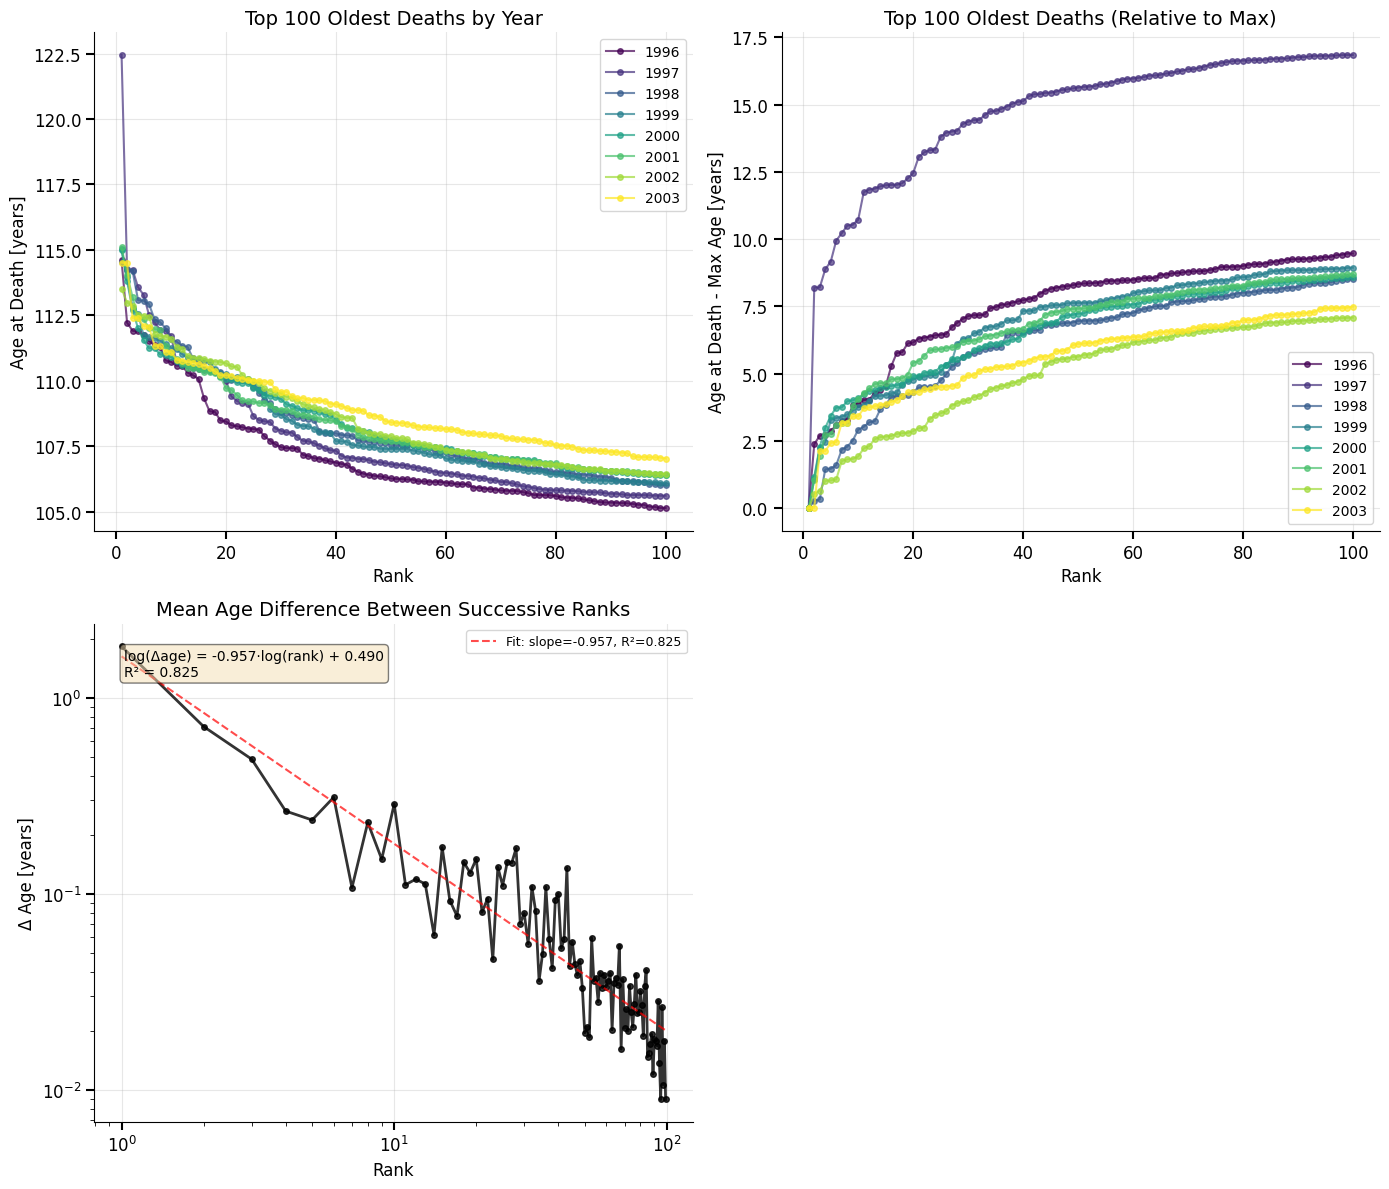

In [5]:
# Define parameter for top rank
top_rank = 100

# Filter for France
#france_df = idl_df[idl_df['BIRTH_COUNTRY'] == 'FRA']

# Define years to analyze
years_france = range(1996, 2004)

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Create color map
colors = plt.cm.viridis(np.linspace(0, 1, len(years_france)))

# Top left: Original plot (age vs rank)
ax1 = axes[0, 0]
for i, year in enumerate(years_france):
    # Filter deaths in this year
    died_this_year = idl_df[idl_df['DEATH_YEAR'] == year]
    
    if len(died_this_year) > 0:
        # Get ages at death and sort in descending order
        ages_at_death = died_this_year['age_at_death'].sort_values(ascending=False).reset_index(drop=True)
        
        # Take top n (or fewer if not enough data)
        top_n = ages_at_death.head(top_rank)
        
        # Create rank array (1 to len(top_n))
        ranks = np.arange(1, len(top_n) + 1)
        
        # Plot age vs rank
        ax1.plot(ranks, top_n.values, marker='o', markersize=4, 
                label=f'{year}', color=colors[i], alpha=0.7)

ax1.set_xlabel('Rank', fontsize=12)
ax1.set_ylabel('Age at Death [years]', fontsize=12)
ax1.set_title(f'Top {top_rank} Oldest Deaths by Year', fontsize=14)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Top right: Same but minus the top age value (so first value is 0)
ax2 = axes[0, 1]
for i, year in enumerate(years_france):
    # Filter deaths in this year
    died_this_year = idl_df[idl_df['DEATH_YEAR'] == year]
    
    if len(died_this_year) > 0:
        # Get ages at death and sort in descending order
        ages_at_death = died_this_year['age_at_death'].sort_values(ascending=False).reset_index(drop=True)
        
        # Take top n (or fewer if not enough data)
        top_n = ages_at_death.head(top_rank)
        
        if len(top_n) > 0:
            # Subtract the maximum age (rank 1) from all ages
            top_age = top_n.iloc[0]
            ages_relative = top_age - top_n.values
            
            # Create rank array (1 to len(top_n))
            ranks = np.arange(1, len(top_n) + 1)
            
            # Plot relative age vs rank
            ax2.plot(ranks, ages_relative, marker='o', markersize=4, 
                    label=f'{year}', color=colors[i], alpha=0.7)

ax2.set_xlabel('Rank', fontsize=12)
ax2.set_ylabel('Age at Death - Max Age [years]', fontsize=12)
ax2.set_title(f'Top {top_rank} Oldest Deaths (Relative to Max)', fontsize=14)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# Bottom left: Delta age between successive ranks vs rank (log-log)
ax3 = axes[1, 0]

# Collect delta ages for each rank across all years
delta_ages_by_rank = []

for i, year in enumerate(years_france):
    # Filter deaths in this year
    died_this_year = idl_df[idl_df['DEATH_YEAR'] == year]
    
    if len(died_this_year) > 0:
        # Get ages at death and sort in descending order
        ages_at_death = died_this_year['age_at_death'].sort_values(ascending=False).reset_index(drop=True)
        
        # Take top n (or fewer if not enough data)
        top_n = ages_at_death.head(top_rank)
        
        if len(top_n) > 1:
            # Calculate differences between successive ranks
            delta_ages = -np.diff(top_n.values)  # Negative because ages decrease with rank
            delta_ages_by_rank.append(delta_ages)

# Convert to array and calculate mean across years for each rank
if len(delta_ages_by_rank) > 0:
    # Stack arrays (pad with NaN if needed for different lengths)
    max_len = max(len(d) for d in delta_ages_by_rank)
    delta_ages_array = np.full((len(delta_ages_by_rank), max_len), np.nan)
    for i, delta_ages in enumerate(delta_ages_by_rank):
        delta_ages_array[i, :len(delta_ages)] = delta_ages
    
    # Calculate mean across years (ignoring NaNs)
    mean_delta_ages = np.nanmean(delta_ages_array, axis=0)
    
    # Create rank array for the deltas (starting at rank 1)
    ranks = np.arange(1, len(mean_delta_ages) + 1)
    
    # Plot mean delta age vs rank
    ax3.plot(ranks, mean_delta_ages, marker='o', markersize=4, 
            color='black', linewidth=2, alpha=0.8)
    
    # Perform linear regression on log-log data
    log_ranks = np.log(ranks)
    log_delta_ages = np.log(mean_delta_ages)
    
    # Remove any NaN or inf values
    valid_mask = np.isfinite(log_ranks) & np.isfinite(log_delta_ages)
    log_ranks_valid = log_ranks[valid_mask]
    log_delta_ages_valid = log_delta_ages[valid_mask]
    
    if len(log_ranks_valid) > 1:
        # Fit linear regression: log(Δage) = slope * log(rank) + intercept
        slope, intercept = np.polyfit(log_ranks_valid, log_delta_ages_valid, 1)
        
        # Calculate R-squared
        y_pred = slope * log_ranks_valid + intercept
        ss_res = np.sum((log_delta_ages_valid - y_pred) ** 2)
        ss_tot = np.sum((log_delta_ages_valid - np.mean(log_delta_ages_valid)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Plot regression line
        ax3.plot(ranks, np.exp(intercept) * ranks**slope, 
                linestyle='--', color='red', linewidth=1.5, alpha=0.7, 
                label=f'Fit: slope={slope:.3f}, R²={r_squared:.3f}')
        
        # Add text box with regression parameters
        textstr = f'log(Δage) = {slope:.3f}·log(rank) + {intercept:.3f}\nR² = {r_squared:.3f}'
        ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax3.set_xlabel('Rank', fontsize=12)
ax3.set_ylabel('Δ Age [years]', fontsize=12)
ax3.set_title('Mean Age Difference Between Successive Ranks', fontsize=14)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best', fontsize=9)

# Bottom right: Leave blank
ax4 = axes[1, 1]
ax4.axis('off')

plt.tight_layout()
plt.show()


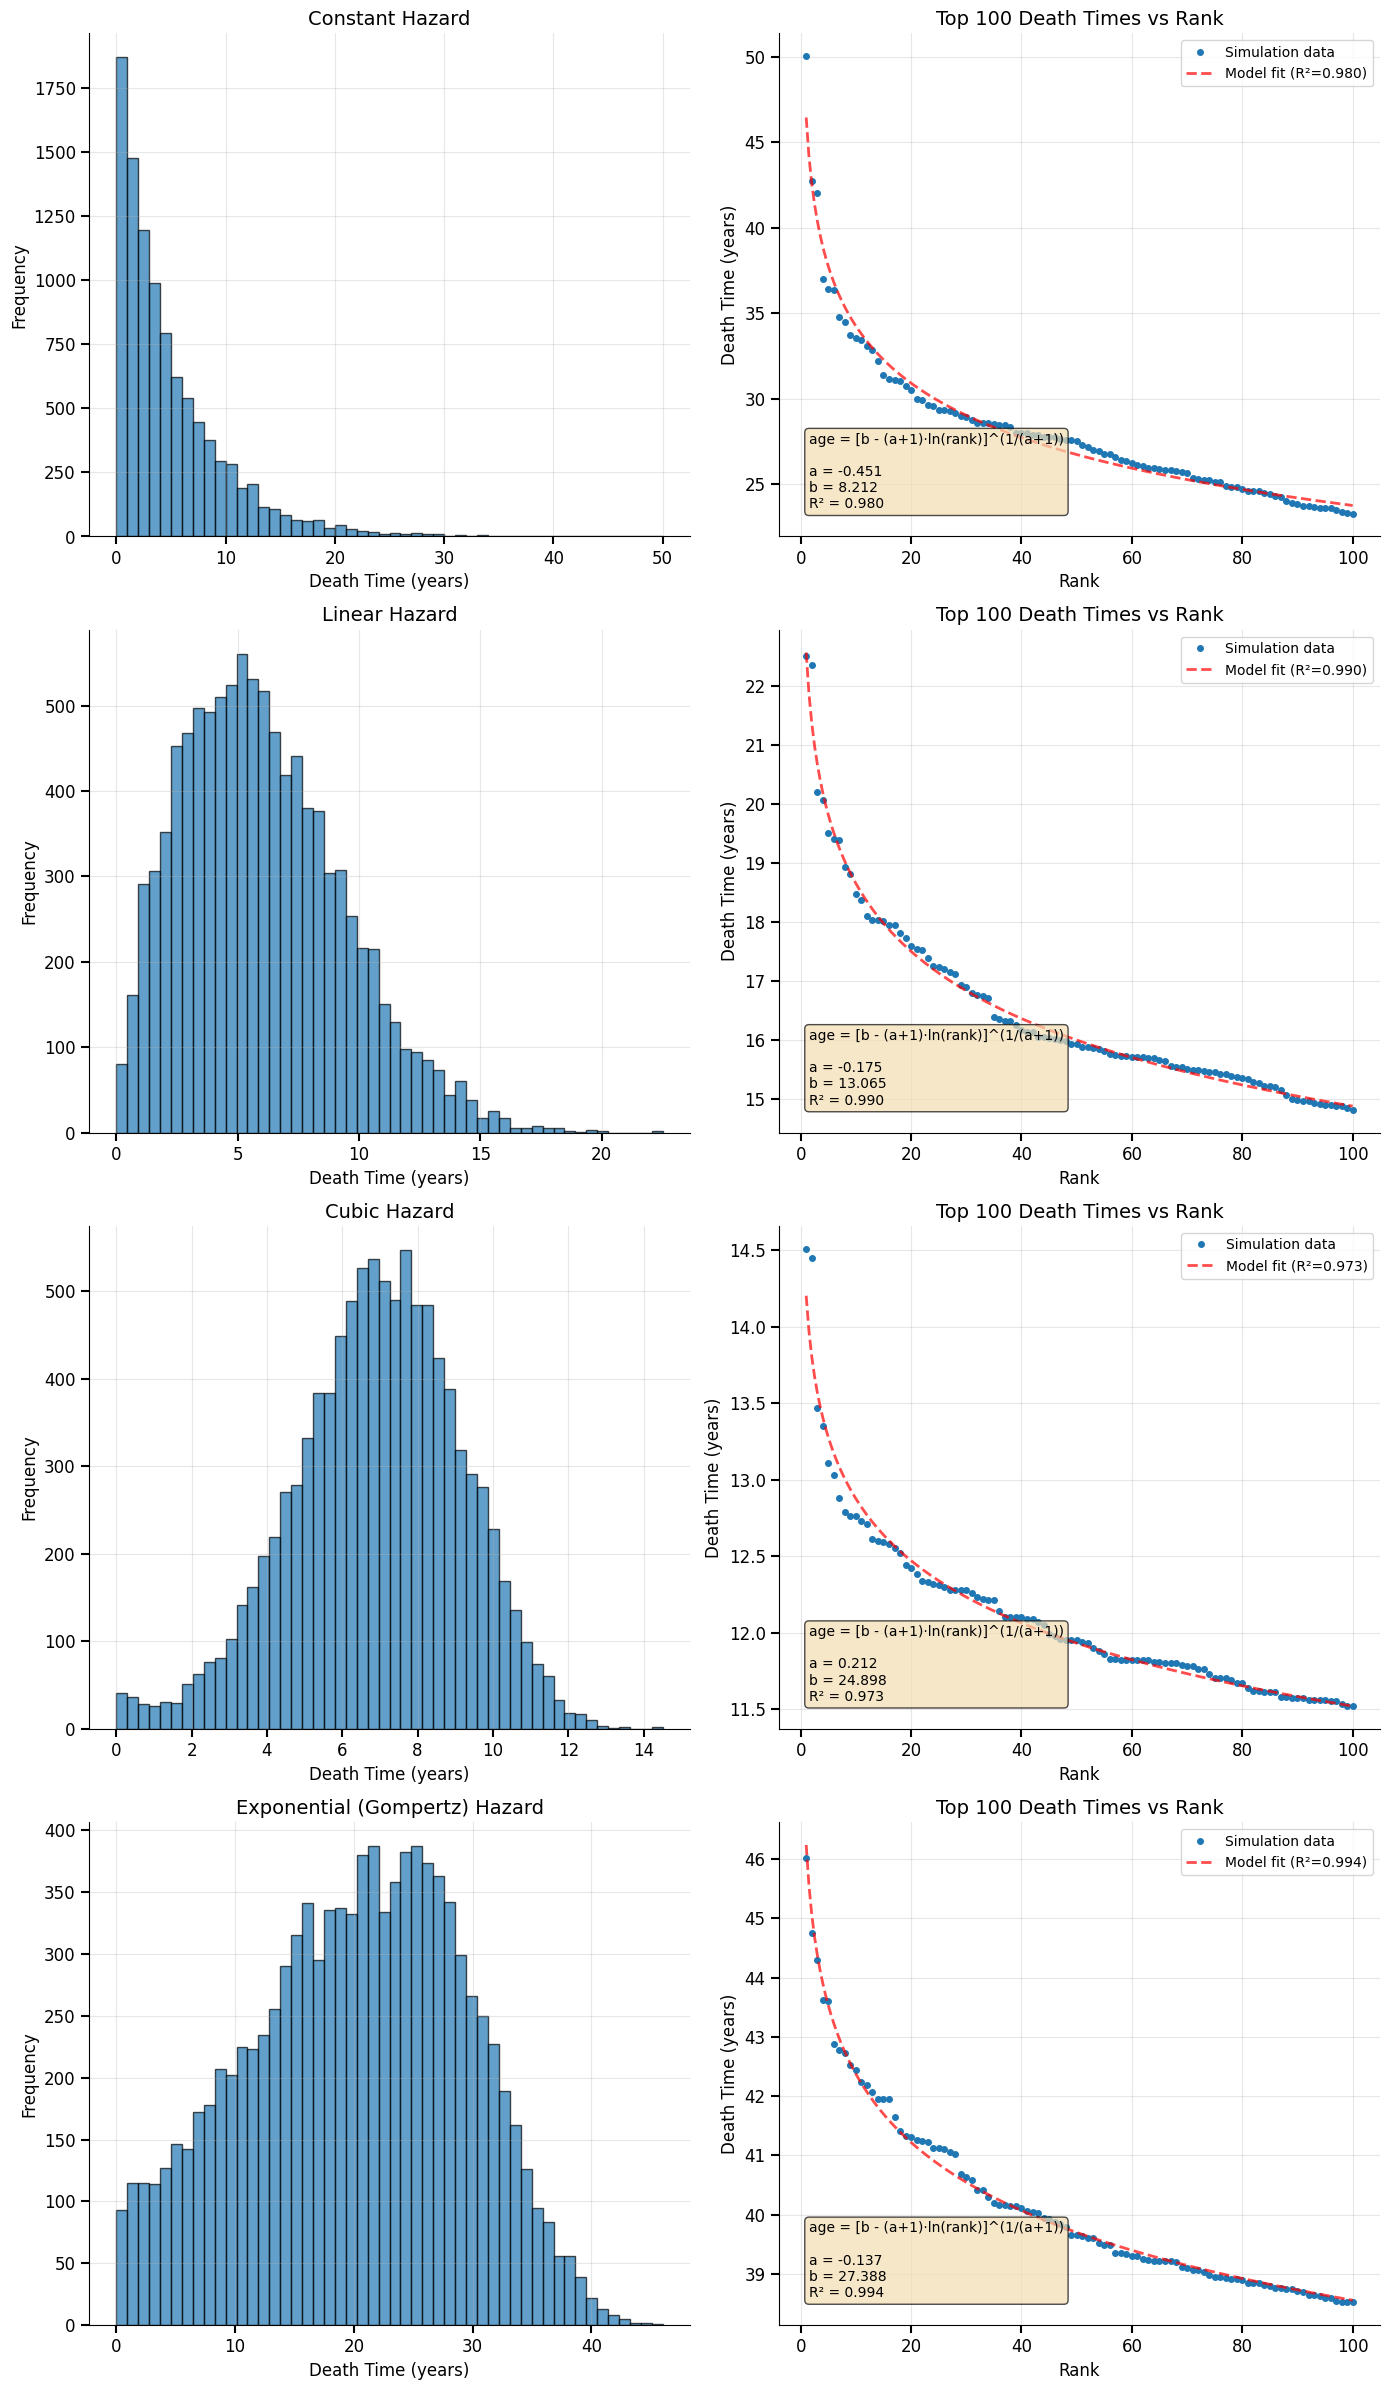

Number of individuals: 10000


In [31]:
# Simulation: Different hazard models
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the age model
def age_model(rank, a, b):
    return (b - (a + 1) * np.log(rank)) ** (1 / (a + 1))

# Parameters
n_individuals = 10000
dt = 0.01  # Small time step (years)
max_time = 200  # Maximum simulation time

# Create figure with 4 rows, 2 columns
fig, axes = plt.subplots(4, 2, figsize=(14, 24))

# Hazard models to simulate
hazard_models = [
    ('Constant', lambda t: 0.2),
    ('Linear', lambda t: 0.01 + 0.04 * t),
    ('Cubic', lambda t: 0.01 + 0.001 * (t ** 3)),
    ('Exponential (Gompertz)', lambda t: 0.01 * np.exp(0.1 * t))
]

for row_idx, (model_name, hazard_func) in enumerate(hazard_models):
    # Initialize all individuals
    alive = np.ones(n_individuals, dtype=bool)
    death_times = np.full(n_individuals, np.nan)
    
    # Simulate over time
    t = 0.0
    while t <= max_time and np.any(alive):
        # Calculate hazard for current time
        h_t = hazard_func(t)
        
        # Probability of death in this time step
        p_death = 1 - np.exp(-h_t * dt)
        
        # Determine who dies
        dies_now = alive & (np.random.random(n_individuals) < p_death)
        death_times[dies_now] = t
        alive[dies_now] = False
        
        t += dt
    
    # Set remaining alive individuals to max_time
    death_times[alive] = max_time
    
    # Get top 100
    death_times_sorted = np.sort(death_times)[::-1]
    top_100 = death_times_sorted[:100]
    ranks = np.arange(1, 101)
    
    # Plot 1: Death time distribution
    ax = axes[row_idx, 0]
    ax.hist(death_times[np.isfinite(death_times)], bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Death Time (years)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{model_name} Hazard', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Top 100 death times vs rank with model fit
    ax = axes[row_idx, 1]
    ax.plot(ranks, top_100, 'o', markersize=4, label='Simulation data')
    
    try:
        p0 = [0, 10]
        popt, _ = curve_fit(age_model, ranks, top_100, p0=p0, maxfev=10000)
        a_fit, b_fit = popt
        
        ages_pred = age_model(ranks, a_fit, b_fit)
        ss_res = np.sum((top_100 - ages_pred) ** 2)
        ss_tot = np.sum((top_100 - np.mean(top_100)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        ranks_smooth = np.linspace(ranks.min(), ranks.max(), 200)
        ages_fit = age_model(ranks_smooth, a_fit, b_fit)
        ax.plot(ranks_smooth, ages_fit, '--', color='red', linewidth=2, 
               alpha=0.7, label=f'Model fit (R²={r_squared:.3f})')
        
        textstr = 'age = [b - (a+1)·ln(rank)]^(1/(a+1))\n\n'
        textstr += f'a = {a_fit:.3f}\n'
        textstr += f'b = {b_fit:.3f}\n'
        textstr += f'R² = {r_squared:.3f}'
        ax.text(0.05, 0.05, textstr, transform=ax.transAxes, 
               fontsize=10, verticalalignment='bottom',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    except Exception as e:
        print(f"{model_name} hazard fit failed: {e}")
    
    ax.set_xlabel('Rank', fontsize=12)
    ax.set_ylabel('Death Time (years)', fontsize=12)
    ax.set_title('Top 100 Death Times vs Rank', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Number of individuals: {n_individuals}")


doesn't seem like it

### in general, linear vs gompertz vs constant hazard for this large N don't really show a difference in delta age vs rank


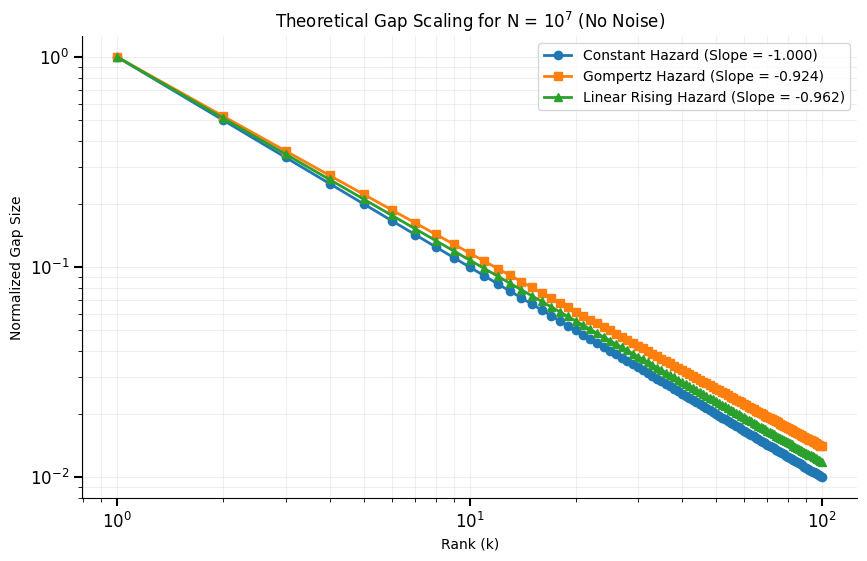

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Parameters
N = 1e7
k = np.arange(1, 101) # Ranks 1 to 100

# Theoretical Gap Scaling (Proportionalities)
# We normalize them all to start at 1.0 at k=1 to compare slopes easily.

# 1. Constant Hazard: proportional to 1/k
gap_const = 1.0 / k
gap_const /= gap_const[0]

# 2. Linear Hazard: proportional to 1 / (k * sqrt(lnN - lnk))
# Note: This is an approximation of the derivative of sqrt(lnN - lnk)
# Exact derivative of t = sqrt(lnN - lnk) is proportional to 1/(k * sqrt(lnN - lnk))
denom_lin = k * np.sqrt(np.log(N) - np.log(k))
gap_lin = 1.0 / denom_lin
gap_lin /= gap_lin[0]

# 3. Gompertz Hazard: proportional to 1 / (k * (lnN - lnk))
# Exact derivative of t = ln(lnN - lnk) is proportional to 1/(k * (lnN - lnk))
denom_gomp = k * (np.log(N) - np.log(k))
gap_gomp = 1.0 / denom_gomp
gap_gomp /= gap_gomp[0]

# --- Calculate Slopes ---
slope_c, _, _, _, _ = linregress(np.log(k), np.log(gap_const))
slope_l, _, _, _, _ = linregress(np.log(k), np.log(gap_lin))
slope_g, _, _, _, _ = linregress(np.log(k), np.log(gap_gomp))

# --- Plotting ---
plt.figure(figsize=(10, 6))

plt.loglog(k, gap_const, 'o-', linewidth=2, label=f'Constant Hazard (Slope = {slope_c:.3f})')
plt.loglog(k, gap_gomp, 's-', linewidth=2, label=f'Gompertz Hazard (Slope = {slope_g:.3f})')
plt.loglog(k, gap_lin, '^-', linewidth=2, label=f'Linear Rising Hazard (Slope = {slope_l:.3f})')

plt.xlabel('Rank (k)')
plt.ylabel('Normalized Gap Size')
plt.title(f'Theoretical Gap Scaling for N = $10^7$ (No Noise)')
plt.legend()
plt.grid(True, which="both", alpha=0.2)
plt.show()

neither can we from fitting diff in ranks

# mean remaining lifespan

In [76]:
import pandas as pd

# Load the file
file_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/super_centenarians.txt'

# Read the tab-separated file, skipping the first empty line
df = pd.read_csv(file_path, sep='\t', skiprows=1)

# Select only the columns you want
df = df[['Born', 'Died', 'Years', 'Days', 'Sex']]

# Convert Born and Died to just years
df['Born'] = pd.to_datetime(df['Born']).dt.year
df['Died'] = pd.to_datetime(df['Died']).dt.year

file_path = '/Users/benshenhar/Library/CloudStorage/GoogleDrive-benshenhar@gmail.com/My Drive/Weizmann/Alon Lab/Aging/python/notebooks/thresholds, noise/saved_results/IDL_COMPLETE_Death_105.xlsx'

# Load the IDL data
idl_df = pd.read_excel(file_path)
# Calculate age at death using birth and death dates
birth_dates = pd.to_datetime(dict(year=idl_df['BIRTH_YEAR'],
                                  month=idl_df['BIRTH_MONTH'],
                                  day=idl_df['BIRTH_DAY']))
death_dates = pd.to_datetime(dict(year=idl_df['DEATH_YEAR'],
                                  month=idl_df['DEATH_MONTH'],
                                  day=idl_df['DEATH_DAY']))
idl_df['age_at_death'] = (death_dates - birth_dates).dt.days / 365.25
# Remove rows where VALIDATION is "SAMPLE OUT"
idl_df = idl_df[idl_df['VALIDATION'] != 'SAMPLE OUT']




Simulating death times...


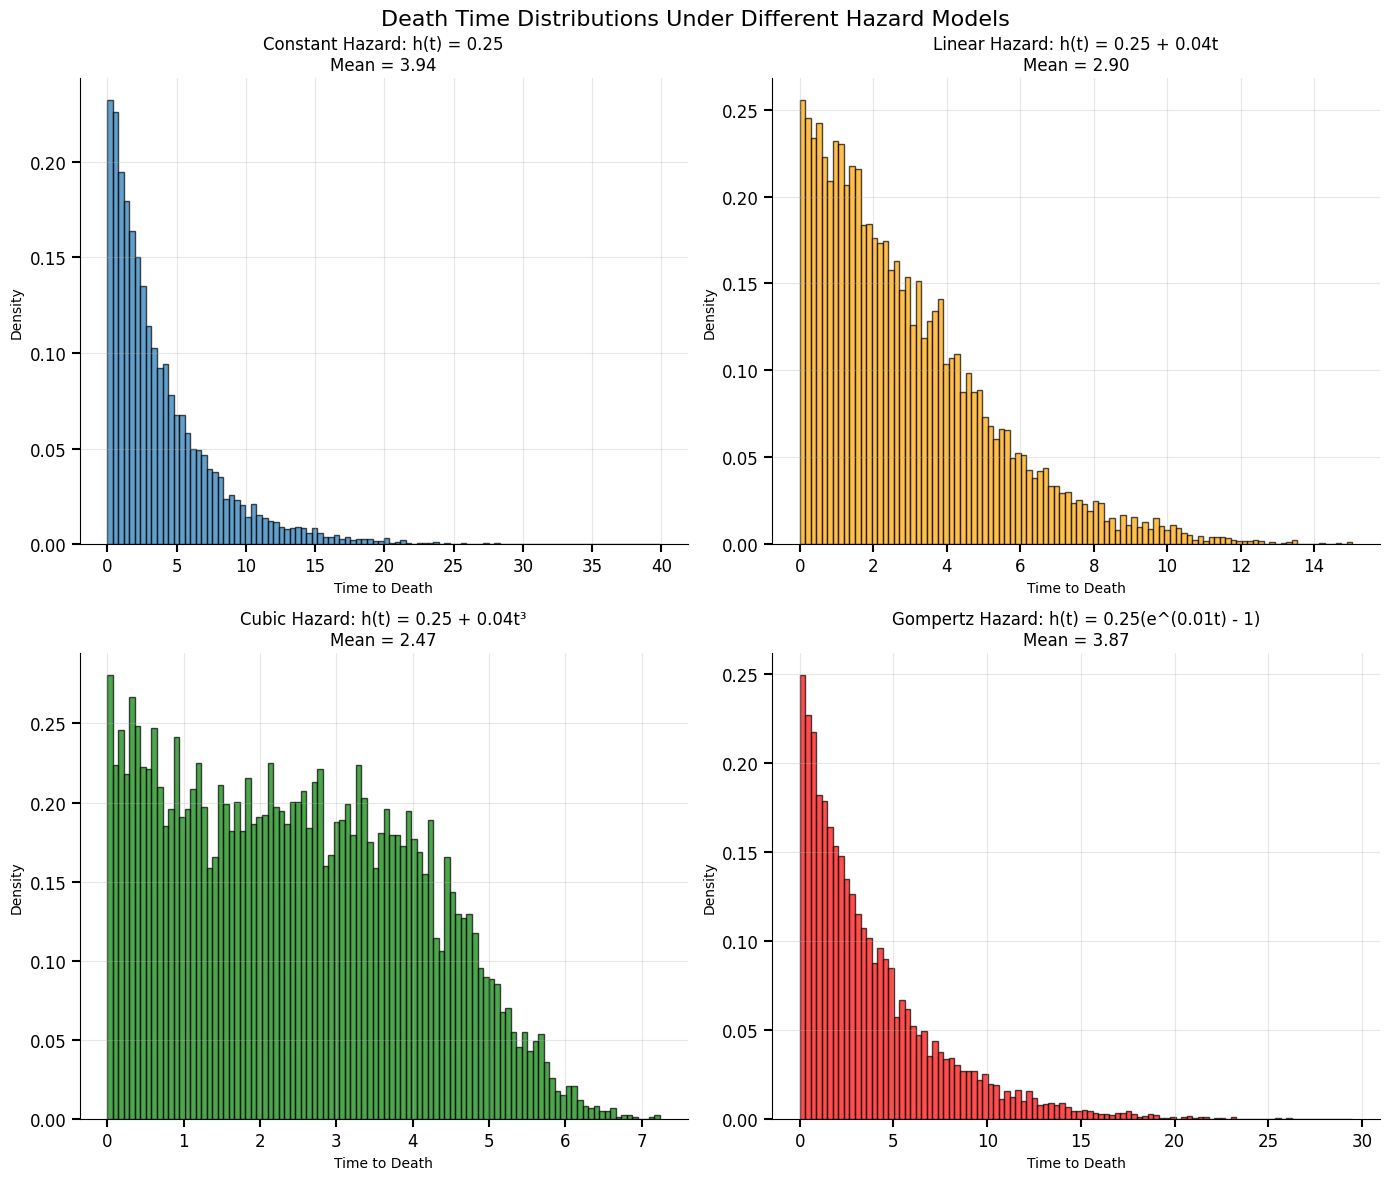


Summary Statistics:
Constant Hazard - Mean: 3.94, Median: 2.71, Max: 39.89
Linear Hazard   - Mean: 2.90, Median: 2.33, Max: 15.04
Cubic Hazard    - Mean: 2.47, Median: 2.38, Max: 7.24
Gompertz Hazard - Mean: 3.87, Median: 2.76, Max: 29.48


In [77]:
# Simulate death times under different hazard models (vectorized approach)
np.random.seed(42)
n_individuals = 10000

# Define hazard models
def constant_hazard(t):
    return 0.25

def linear_hazard(t):
    return 0.25 + 0.04 * t

def cubic_hazard(t):
    return 0.25 + 0.01 * t**3

def gompertz_hazard(t, b=0.01):
    return 0.25 * np.exp(b * t) 

# Vectorized simulation of death times
def simulate_deaths_vectorized(hazard_func, n_individuals, max_time=200, dt=0.01):
    """Simulate death times given a hazard function using vectorized operations"""
    # Initialize arrays
    alive_mask = np.ones(n_individuals, dtype=bool)
    death_times = np.full(n_individuals, np.nan)
    
    t = 0
    while np.any(alive_mask) and t < max_time:
        # Calculate hazard for current time
        h = hazard_func(t)
        
        # Probability of death in small time interval dt for alive individuals
        p_death = h * dt
        
        # Generate random numbers for alive individuals
        random_vals = np.random.random(n_individuals)
        
        # Determine who dies at this time step (among those still alive)
        dies_now = alive_mask & (random_vals < p_death)
        
        # Record death times
        death_times[dies_now] = t
        
        # Update alive mask
        alive_mask[dies_now] = False
        
        # Progress time
        t += dt
    
    # Anyone still alive at max_time gets assigned max_time as death time
    death_times[alive_mask] = max_time
    
    return death_times

# Simulate for each model
print("Simulating death times...")
deaths_constant = simulate_deaths_vectorized(constant_hazard, n_individuals)
deaths_linear = simulate_deaths_vectorized(linear_hazard, n_individuals)
deaths_cubic = simulate_deaths_vectorized(cubic_hazard, n_individuals)
deaths_gompertz = simulate_deaths_vectorized(lambda t: gompertz_hazard(t, b=0.01), n_individuals)

# Plot histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Death Time Distributions Under Different Hazard Models', fontsize=16)

# Constant hazard
ax = axes[0, 0]
ax.hist(deaths_constant, bins=100, alpha=0.7, edgecolor='black', density=True)
ax.set_xlabel('Time to Death')
ax.set_ylabel('Density')
ax.set_title(f'Constant Hazard: h(t) = 0.25\nMean = {deaths_constant.mean():.2f}')
ax.grid(True, alpha=0.3)

# Linear hazard
ax = axes[0, 1]
ax.hist(deaths_linear, bins=100, alpha=0.7, edgecolor='black', density=True, color='orange')
ax.set_xlabel('Time to Death')
ax.set_ylabel('Density')
ax.set_title(f'Linear Hazard: h(t) = 0.25 + 0.04t\nMean = {deaths_linear.mean():.2f}')
ax.grid(True, alpha=0.3)

# Cubic hazard
ax = axes[1, 0]
ax.hist(deaths_cubic, bins=100, alpha=0.7, edgecolor='black', density=True, color='green')
ax.set_xlabel('Time to Death')
ax.set_ylabel('Density')
ax.set_title(f'Cubic Hazard: h(t) = 0.25 + 0.04t³\nMean = {deaths_cubic.mean():.2f}')
ax.grid(True, alpha=0.3)

# Gompertz hazard
ax = axes[1, 1]
ax.hist(deaths_gompertz, bins=100, alpha=0.7, edgecolor='black', density=True, color='red')
ax.set_xlabel('Time to Death')
ax.set_ylabel('Density')
ax.set_title(f'Gompertz Hazard: h(t) = 0.25(e^(0.01t) - 1)\nMean = {deaths_gompertz.mean():.2f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Constant Hazard - Mean: {deaths_constant.mean():.2f}, Median: {np.median(deaths_constant):.2f}, Max: {deaths_constant.max():.2f}")
print(f"Linear Hazard   - Mean: {deaths_linear.mean():.2f}, Median: {np.median(deaths_linear):.2f}, Max: {deaths_linear.max():.2f}")
print(f"Cubic Hazard    - Mean: {deaths_cubic.mean():.2f}, Median: {np.median(deaths_cubic):.2f}, Max: {deaths_cubic.max():.2f}")
print(f"Gompertz Hazard - Mean: {deaths_gompertz.mean():.2f}, Median: {np.median(deaths_gompertz):.2f}, Max: {deaths_gompertz.max():.2f}")



/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/2104649735.py:20: RuntimeWarning: Mean of empty slice.
  mean_remaining_cubic.append(deaths_after_cubic.mean() - age)


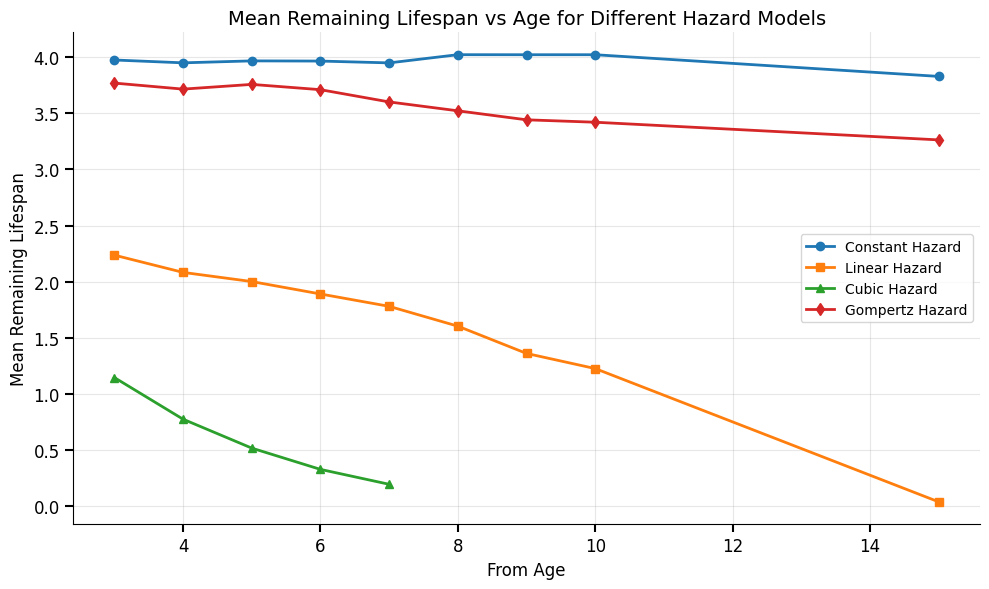

In [37]:
# Define ages to analyze
ages = [3, 4, 5, 6, 7, 8, 9, 10, 15]

# Calculate mean remaining lifespan for each age and hazard model
mean_remaining_constant = []
mean_remaining_linear = []
mean_remaining_cubic = []
mean_remaining_gompertz = []

for age in ages:
    # Filter deaths >= age and calculate mean remaining lifespan
    deaths_after_constant = deaths_constant[deaths_constant >= age]
    deaths_after_linear = deaths_linear[deaths_linear >= age]
    deaths_after_cubic = deaths_cubic[deaths_cubic >= age]
    deaths_after_gompertz = deaths_gompertz[deaths_gompertz >= age]
    
    # Calculate mean remaining lifespan (mean death time - current age)
    mean_remaining_constant.append(deaths_after_constant.mean() - age)
    mean_remaining_linear.append(deaths_after_linear.mean() - age)
    mean_remaining_cubic.append(deaths_after_cubic.mean() - age)
    mean_remaining_gompertz.append(deaths_after_gompertz.mean() - age)

# Plot mean remaining lifespan vs age
plt.figure(figsize=(10, 6))
plt.plot(ages, mean_remaining_constant, marker='o', label='Constant Hazard', linewidth=2)
plt.plot(ages, mean_remaining_linear, marker='s', label='Linear Hazard', linewidth=2)
plt.plot(ages, mean_remaining_cubic, marker='^', label='Cubic Hazard', linewidth=2)
plt.plot(ages, mean_remaining_gompertz, marker='d', label='Gompertz Hazard', linewidth=2)

plt.xlabel('From Age', fontsize=12)
plt.ylabel('Mean Remaining Lifespan', fontsize=12)
plt.title('Mean Remaining Lifespan vs Age for Different Hazard Models', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Results loaded from saved_results/max_lifespan_Xc_factors_1.00to1.50_top1000_n10000000_repeats1_both_dists.pkl
Distributions included: ['gaussian', 'lognormal']


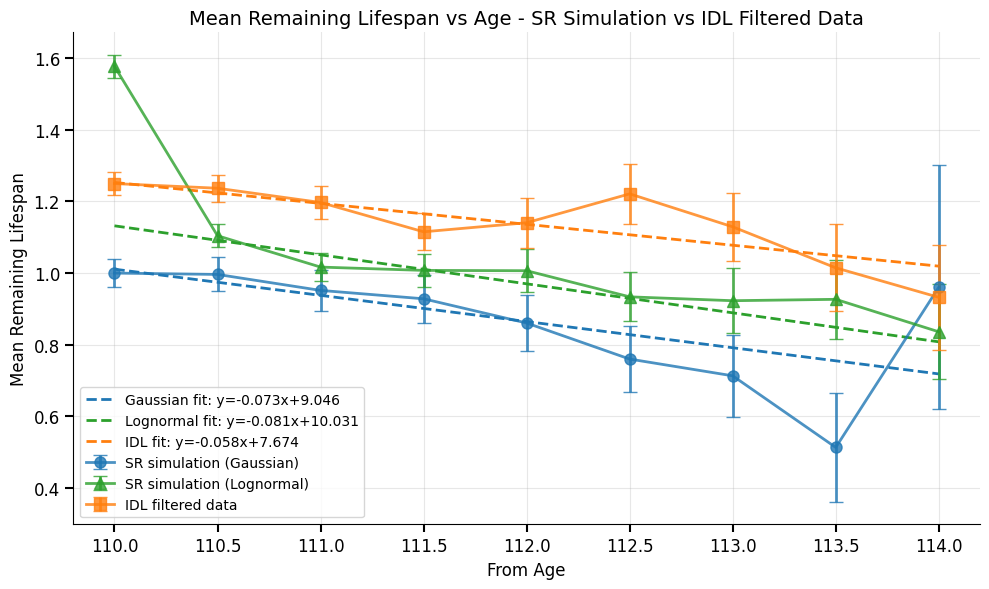

In [143]:
# Load saved results
import pickle
import seaborn as sns

# Define the factor to check
factor_to_check = 1.5

# Load the saved results
pickle_filename = 'saved_results/max_lifespan_Xc_factors_1.00to1.50_top1000_n10000000_repeats1_both_dists.pkl'

with open(pickle_filename, 'rb') as f:
    results_by_dist = pickle.load(f)

print(f"Results loaded from {pickle_filename}")
print(f"Distributions included: {list(results_by_dist.keys())}")

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Find results for the specified factor for Gaussian distribution
gaussian_factor_result = None
lognormal_factor_result = None

for result in results_by_dist['gaussian']['factor_results']:
    if abs(result['factor'] - factor_to_check) < 0.01:
        gaussian_factor_result = result['top_1000_averaged']
        break

for result in results_by_dist['lognormal']['factor_results']:
    if abs(result['factor'] - factor_to_check) < 0.01:
        lognormal_factor_result = result['top_1000_averaged']
        break

# Bootstrap parameters
n_bootstrap = 1000

# Ages to analyze
ages_to_check = [110, 110.5, 111, 111.5, 112, 112.5, 113, 113.5, 114]

# Calculate mean remaining lifespan for Gaussian (SR simulation) with bootstrap SEM
mean_remaining_gaussian = []
sem_remaining_gaussian = []

for age in ages_to_check:
    deaths_after_age = gaussian_factor_result[gaussian_factor_result >= age]
    if len(deaths_after_age) > 0:
        # Calculate observed mean
        mean_val = deaths_after_age.mean() - age
        mean_remaining_gaussian.append(mean_val)
        
        # Bootstrap to get SEM
        bootstrap_means = []
        for _ in range(n_bootstrap):
            bootstrap_sample = np.random.choice(deaths_after_age, size=len(deaths_after_age), replace=True)
            bootstrap_means.append(bootstrap_sample.mean() - age)
        sem_remaining_gaussian.append(np.std(bootstrap_means))
    else:
        mean_remaining_gaussian.append(np.nan)
        sem_remaining_gaussian.append(np.nan)

# Calculate mean remaining lifespan for Lognormal (SR simulation) with bootstrap SEM
mean_remaining_lognormal = []
sem_remaining_lognormal = []

for age in ages_to_check:
    deaths_after_age = lognormal_factor_result[lognormal_factor_result >= age]
    if len(deaths_after_age) > 0:
        # Calculate observed mean
        mean_val = deaths_after_age.mean() - age
        mean_remaining_lognormal.append(mean_val)
        
        # Bootstrap to get SEM
        bootstrap_means = []
        for _ in range(n_bootstrap):
            bootstrap_sample = np.random.choice(deaths_after_age, size=len(deaths_after_age), replace=True)
            bootstrap_means.append(bootstrap_sample.mean() - age)
        sem_remaining_lognormal.append(np.std(bootstrap_means))
    else:
        mean_remaining_lognormal.append(np.nan)
        sem_remaining_lognormal.append(np.nan)

# Plot SR simulation (Gaussian) with error bars
ax.errorbar(ages_to_check, mean_remaining_gaussian, yerr=sem_remaining_gaussian,
            marker='o', linewidth=2, markersize=8, capsize=5, 
            label='SR simulation (Gaussian)', color='#1f77b4', alpha=0.8)

# Add weighted linear fit for SR simulation (Gaussian)
valid_mask_gaussian = ~np.isnan(mean_remaining_gaussian) & ~np.isnan(sem_remaining_gaussian)
if np.sum(valid_mask_gaussian) > 1:
    x_valid_gaussian = np.array(ages_to_check)[valid_mask_gaussian]
    y_valid_gaussian = np.array(mean_remaining_gaussian)[valid_mask_gaussian]
    weights_gaussian = 1.0 / (np.array(sem_remaining_gaussian)[valid_mask_gaussian]**2)
    
    # Weighted linear fit
    coeffs_gaussian = np.polyfit(x_valid_gaussian, y_valid_gaussian, 1, w=weights_gaussian)
    fit_line_gaussian = np.poly1d(coeffs_gaussian)
    ax.plot(ages_to_check, fit_line_gaussian(ages_to_check), '--', linewidth=2, 
            color='#1f77b4', label=f'Gaussian fit: y={coeffs_gaussian[0]:.3f}x+{coeffs_gaussian[1]:.3f}')

# Plot SR simulation (Lognormal) with error bars
ax.errorbar(ages_to_check, mean_remaining_lognormal, yerr=sem_remaining_lognormal,
            marker='^', linewidth=2, markersize=8, capsize=5, 
            label='SR simulation (Lognormal)', color='#2ca02c', alpha=0.8)

# Add weighted linear fit for SR simulation (Lognormal) - starting from 110.5
ages_to_check_array = np.array(ages_to_check)
valid_mask_lognormal = ~np.isnan(mean_remaining_lognormal) & ~np.isnan(sem_remaining_lognormal) & (ages_to_check_array >= 110.5)
if np.sum(valid_mask_lognormal) > 1:
    x_valid_lognormal = ages_to_check_array[valid_mask_lognormal]
    y_valid_lognormal = np.array(mean_remaining_lognormal)[valid_mask_lognormal]
    weights_lognormal = 1.0 / (np.array(sem_remaining_lognormal)[valid_mask_lognormal]**2)
    
    # Weighted linear fit
    coeffs_lognormal = np.polyfit(x_valid_lognormal, y_valid_lognormal, 1, w=weights_lognormal)
    fit_line_lognormal = np.poly1d(coeffs_lognormal)
    ax.plot(ages_to_check, fit_line_lognormal(ages_to_check), '--', linewidth=2, 
            color='#2ca02c', label=f'Lognormal fit: y={coeffs_lognormal[0]:.3f}x+{coeffs_lognormal[1]:.3f}')

# Ages to analyze for 110+ dataset
ages_110 = np.arange(110, 114.5, 0.5)
mean_remaining_110 = []
sem_remaining_110 = []

for age in ages_110:
    subset = df_110_gpt[df_110_gpt['age_at_death'] >= age]['age_at_death']
    if len(subset) > 0:
        # Calculate observed mean
        mean_val = subset.mean() - age
        mean_remaining_110.append(mean_val)
        
        # Bootstrap to get SEM
        bootstrap_means = []
        for _ in range(n_bootstrap):
            bootstrap_sample = subset.sample(n=len(subset), replace=True)
            bootstrap_means.append(bootstrap_sample.mean() - age)
        sem_remaining_110.append(np.std(bootstrap_means))
    else:
        mean_remaining_110.append(np.nan)
        sem_remaining_110.append(np.nan)

# Plot IDL filtered data with error bars
ax.errorbar(ages_110, mean_remaining_110, yerr=sem_remaining_110, 
            marker='s', linewidth=2, markersize=8, capsize=5, 
            label='IDL filtered data', color='#ff7f0e', alpha=0.8)

# Add weighted linear fit for IDL filtered data
valid_mask_110 = ~np.isnan(mean_remaining_110) & ~np.isnan(sem_remaining_110)
if np.sum(valid_mask_110) > 1:
    x_valid_110 = ages_110[valid_mask_110]
    y_valid_110 = np.array(mean_remaining_110)[valid_mask_110]
    weights_110 = 1.0 / (np.array(sem_remaining_110)[valid_mask_110]**2)
    
    # Weighted linear fit
    coeffs_110 = np.polyfit(x_valid_110, y_valid_110, 1, w=weights_110)
    fit_line_110 = np.poly1d(coeffs_110)
    ax.plot(ages_110, fit_line_110(ages_110), '--', linewidth=2, 
            color='#ff7f0e', label=f'IDL fit: y={coeffs_110[0]:.3f}x+{coeffs_110[1]:.3f}')

ax.set_xlabel('From Age', fontsize=12)
ax.set_ylabel('Mean Remaining Lifespan', fontsize=12)
ax.set_title('Mean Remaining Lifespan vs Age - SR Simulation vs IDL Filtered Data', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


# distribution above threshold, extreme value analysis

Gaussian GPD - Sigma (Scale): 1.0979, Gamma (Shape): -0.0756
Lognormal GPD - Sigma (Scale): 1.9183, Gamma (Shape): -0.2501
IDL Filtered GPD - Sigma (Scale): 1.3178, Gamma (Shape): -0.0526
GRG GPD - Sigma (Scale): 1.3727, Gamma (Shape): -0.0488


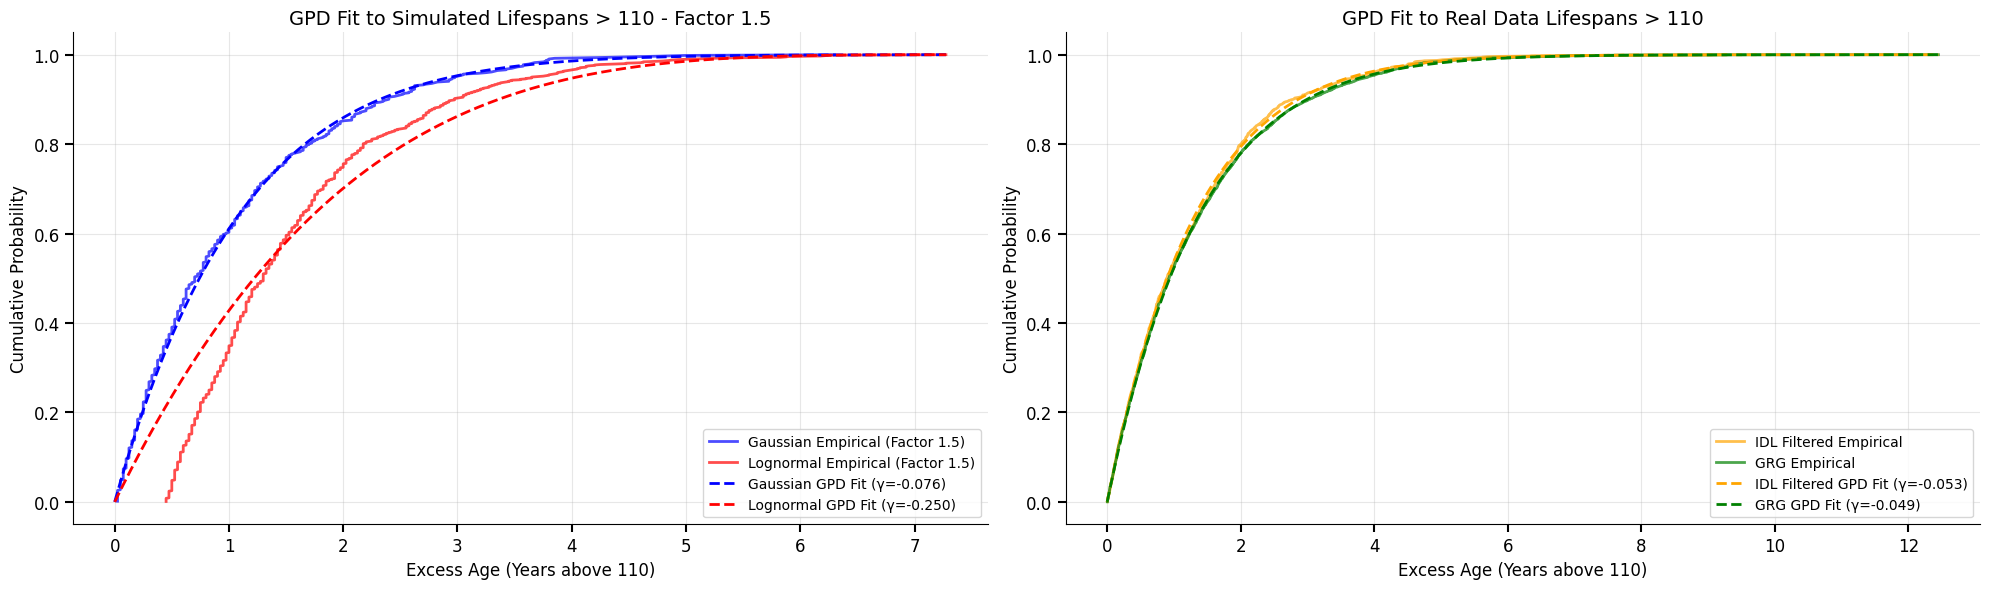

In [132]:
# Fit and plot Generalized Pareto Distributions for both distributions
from scipy.stats import genpareto

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

threshold = 110

# LEFT PLOT: Simulated distributions (Gaussian and Lognormal)
# Filter lifespans > 110 for Gaussian
gaussian_above_110 = gaussian_factor_result[gaussian_factor_result > threshold]
gaussian_excess = gaussian_above_110 - threshold

# Filter lifespans > 110 for Lognormal
lognormal_above_110 = lognormal_factor_result[lognormal_factor_result > threshold]
lognormal_excess = lognormal_above_110 - threshold

# Fit GPD to Gaussian excess ages
gaussian_shape, gaussian_loc, gaussian_scale = genpareto.fit(gaussian_excess, floc=0)
print(f"Gaussian GPD - Sigma (Scale): {gaussian_scale:.4f}, Gamma (Shape): {gaussian_shape:.4f}")

# Fit GPD to Lognormal excess ages
lognormal_shape, lognormal_loc, lognormal_scale = genpareto.fit(lognormal_excess, floc=0)
print(f"Lognormal GPD - Sigma (Scale): {lognormal_scale:.4f}, Gamma (Shape): {lognormal_shape:.4f}")

# Sort for empirical CDF
gaussian_sorted = np.sort(gaussian_excess)
gaussian_cdf = np.arange(1, len(gaussian_sorted) + 1) / len(gaussian_sorted)

lognormal_sorted = np.sort(lognormal_excess)
lognormal_cdf = np.arange(1, len(lognormal_sorted) + 1) / len(lognormal_sorted)

# Plot empirical CDFs
ax1.plot(gaussian_sorted, gaussian_cdf, linewidth=2, 
        label=f'Gaussian Empirical (Factor {factor_to_check})', color='blue', alpha=0.7)
ax1.plot(lognormal_sorted, lognormal_cdf, linewidth=2, 
        label=f'Lognormal Empirical (Factor {factor_to_check})', color='red', alpha=0.7)

# Plot fitted GPD CDFs
x_range = np.linspace(0, max(gaussian_sorted.max(), lognormal_sorted.max()), 1000)
gaussian_gpd_cdf = genpareto.cdf(x_range, gaussian_shape, loc=0, scale=gaussian_scale)
lognormal_gpd_cdf = genpareto.cdf(x_range, lognormal_shape, loc=0, scale=lognormal_scale)

ax1.plot(x_range, gaussian_gpd_cdf, linewidth=2, linestyle='--',
        label=f'Gaussian GPD Fit (γ={gaussian_shape:.3f})', color='blue')
ax1.plot(x_range, lognormal_gpd_cdf, linewidth=2, linestyle='--',
        label=f'Lognormal GPD Fit (γ={lognormal_shape:.3f})', color='red')

ax1.set_xlabel('Excess Age (Years above 110)', fontsize=12)
ax1.set_ylabel('Cumulative Probability', fontsize=12)
ax1.set_title(f'GPD Fit to Simulated Lifespans > 110 - Factor {factor_to_check}', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# RIGHT PLOT: Real data (IDL filtered and GRG)
# IDL filtered data (df_110_gpt)
idl_110_above_110 = df_110_gpt[df_110_gpt['age_at_death'] > threshold]['age_at_death']
idl_110_excess = idl_110_above_110 - threshold

# GRG data
all_deaths_df = df.copy()
all_deaths_df['age_at_death'] = all_deaths_df['Years'] + all_deaths_df['Days'] / 365.25
grg_above_110 = all_deaths_df[all_deaths_df['age_at_death'] > threshold]['age_at_death']
grg_excess = grg_above_110 - threshold

# Fit GPD to IDL filtered excess ages
idl_110_shape, idl_110_loc, idl_110_scale = genpareto.fit(idl_110_excess, floc=0)
print(f"IDL Filtered GPD - Sigma (Scale): {idl_110_scale:.4f}, Gamma (Shape): {idl_110_shape:.4f}")

# Fit GPD to GRG excess ages
grg_shape, grg_loc, grg_scale = genpareto.fit(grg_excess, floc=0)
print(f"GRG GPD - Sigma (Scale): {grg_scale:.4f}, Gamma (Shape): {grg_shape:.4f}")

# Sort for empirical CDF
idl_110_sorted = np.sort(idl_110_excess)
idl_110_cdf = np.arange(1, len(idl_110_sorted) + 1) / len(idl_110_sorted)

grg_sorted = np.sort(grg_excess)
grg_cdf = np.arange(1, len(grg_sorted) + 1) / len(grg_sorted)

# Plot empirical CDFs
ax2.plot(idl_110_sorted, idl_110_cdf, linewidth=2, 
        label='IDL Filtered Empirical', color='orange', alpha=0.7)
ax2.plot(grg_sorted, grg_cdf, linewidth=2, 
        label='GRG Empirical', color='green', alpha=0.7)

# Plot fitted GPD CDFs
x_range_real = np.linspace(0, max(idl_110_sorted.max(), grg_sorted.max()), 1000)
idl_110_gpd_cdf = genpareto.cdf(x_range_real, idl_110_shape, loc=0, scale=idl_110_scale)
grg_gpd_cdf = genpareto.cdf(x_range_real, grg_shape, loc=0, scale=grg_scale)

ax2.plot(x_range_real, idl_110_gpd_cdf, linewidth=2, linestyle='--',
        label=f'IDL Filtered GPD Fit (γ={idl_110_shape:.3f})', color='orange')
ax2.plot(x_range_real, grg_gpd_cdf, linewidth=2, linestyle='--',
        label=f'GRG GPD Fit (γ={grg_shape:.3f})', color='green')

ax2.set_xlabel('Excess Age (Years above 110)', fontsize=12)
ax2.set_ylabel('Cumulative Probability', fontsize=12)
ax2.set_title('GPD Fit to Real Data Lifespans > 110', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Gaussian GPD - Sigma (Scale): 1.0979, Gamma (Shape): -0.0756
Lognormal GPD - Sigma (Scale): 1.2335, Gamma (Shape): -0.0954
IDL Filtered GPD - Sigma (Scale): 1.3178, Gamma (Shape): -0.0526
GRG GPD - Sigma (Scale): 1.3727, Gamma (Shape): -0.0488


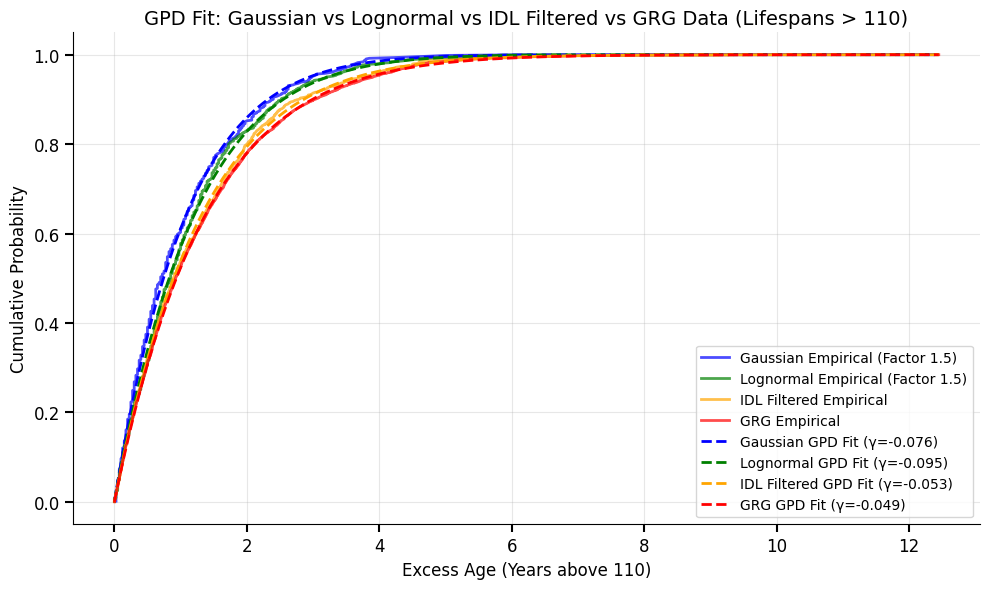

In [146]:
# Fit and plot Generalized Pareto Distributions for Gaussian simulation, Lognormal simulation, IDL filtered data, and GRG data
from scipy.stats import genpareto

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

threshold = 110

# Gaussian simulation
gaussian_above_110 = gaussian_factor_result[gaussian_factor_result > threshold]
gaussian_excess = gaussian_above_110 - threshold

# Lognormal simulation
lognormal_above_110 = lognormal_factor_result[lognormal_factor_result > threshold]
lognormal_excess = lognormal_above_110 - threshold
lognormal_excess_shifted = lognormal_excess - lognormal_excess.min()

# IDL filtered data
idl_110_above_110 = df_110_gpt[df_110_gpt['age_at_death'] > threshold]['age_at_death']
idl_110_excess = idl_110_above_110 - threshold

# GRG data
all_deaths_df = df.copy()
all_deaths_df['age_at_death'] = all_deaths_df['Years'] + all_deaths_df['Days'] / 365.25
grg_above_110 = all_deaths_df[all_deaths_df['age_at_death'] > threshold]['age_at_death']
grg_excess = grg_above_110 - threshold

# Fit GPD to Gaussian excess ages
gaussian_shape, gaussian_loc, gaussian_scale = genpareto.fit(gaussian_excess, floc=0)
print(f"Gaussian GPD - Sigma (Scale): {gaussian_scale:.4f}, Gamma (Shape): {gaussian_shape:.4f}")

# Fit GPD to Lognormal excess ages (shifted)
lognormal_shape, lognormal_loc, lognormal_scale = genpareto.fit(lognormal_excess_shifted, floc=0)
print(f"Lognormal GPD - Sigma (Scale): {lognormal_scale:.4f}, Gamma (Shape): {lognormal_shape:.4f}")

# Fit GPD to IDL filtered excess ages
idl_110_shape, idl_110_loc, idl_110_scale = genpareto.fit(idl_110_excess, floc=0)
print(f"IDL Filtered GPD - Sigma (Scale): {idl_110_scale:.4f}, Gamma (Shape): {idl_110_shape:.4f}")

# Fit GPD to GRG excess ages
grg_shape, grg_loc, grg_scale = genpareto.fit(grg_excess, floc=0)
print(f"GRG GPD - Sigma (Scale): {grg_scale:.4f}, Gamma (Shape): {grg_shape:.4f}")

# Sort for empirical CDF
gaussian_sorted = np.sort(gaussian_excess)
gaussian_cdf = np.arange(1, len(gaussian_sorted) + 1) / len(gaussian_sorted)

lognormal_sorted = np.sort(lognormal_excess_shifted)
lognormal_cdf = np.arange(1, len(lognormal_sorted) + 1) / len(lognormal_sorted)

idl_110_sorted = np.sort(idl_110_excess)
idl_110_cdf = np.arange(1, len(idl_110_sorted) + 1) / len(idl_110_sorted)

grg_sorted = np.sort(grg_excess)
grg_cdf = np.arange(1, len(grg_sorted) + 1) / len(grg_sorted)

# Plot empirical CDFs
ax.plot(gaussian_sorted, gaussian_cdf, linewidth=2, 
        label=f'Gaussian Empirical (Factor {factor_to_check})', color='blue', alpha=0.7)
ax.plot(lognormal_sorted, lognormal_cdf, linewidth=2, 
        label=f'Lognormal Empirical (Factor {factor_to_check})', color='green', alpha=0.7)
ax.plot(idl_110_sorted, idl_110_cdf, linewidth=2, 
        label='IDL Filtered Empirical', color='orange', alpha=0.7)
ax.plot(grg_sorted, grg_cdf, linewidth=2, 
        label='GRG Empirical', color='red', alpha=0.7)

# Plot fitted GPD CDFs
x_range = np.linspace(0, max(gaussian_sorted.max(), lognormal_sorted.max(), idl_110_sorted.max(), grg_sorted.max()), 1000)
gaussian_gpd_cdf = genpareto.cdf(x_range, gaussian_shape, loc=0, scale=gaussian_scale)
lognormal_gpd_cdf = genpareto.cdf(x_range, lognormal_shape, loc=0, scale=lognormal_scale)
idl_110_gpd_cdf = genpareto.cdf(x_range, idl_110_shape, loc=0, scale=idl_110_scale)
grg_gpd_cdf = genpareto.cdf(x_range, grg_shape, loc=0, scale=grg_scale)

ax.plot(x_range, gaussian_gpd_cdf, linewidth=2, linestyle='--',
        label=f'Gaussian GPD Fit (γ={gaussian_shape:.3f})', color='blue')
ax.plot(x_range, lognormal_gpd_cdf, linewidth=2, linestyle='--',
        label=f'Lognormal GPD Fit (γ={lognormal_shape:.3f})', color='green')
ax.plot(x_range, idl_110_gpd_cdf, linewidth=2, linestyle='--',
        label=f'IDL Filtered GPD Fit (γ={idl_110_shape:.3f})', color='orange')
ax.plot(x_range, grg_gpd_cdf, linewidth=2, linestyle='--',
        label=f'GRG GPD Fit (γ={grg_shape:.3f})', color='red')

ax.set_xlabel('Excess Age (Years above 110)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title(f'GPD Fit: Gaussian vs Lognormal vs IDL Filtered vs GRG Data (Lifespans > 110)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


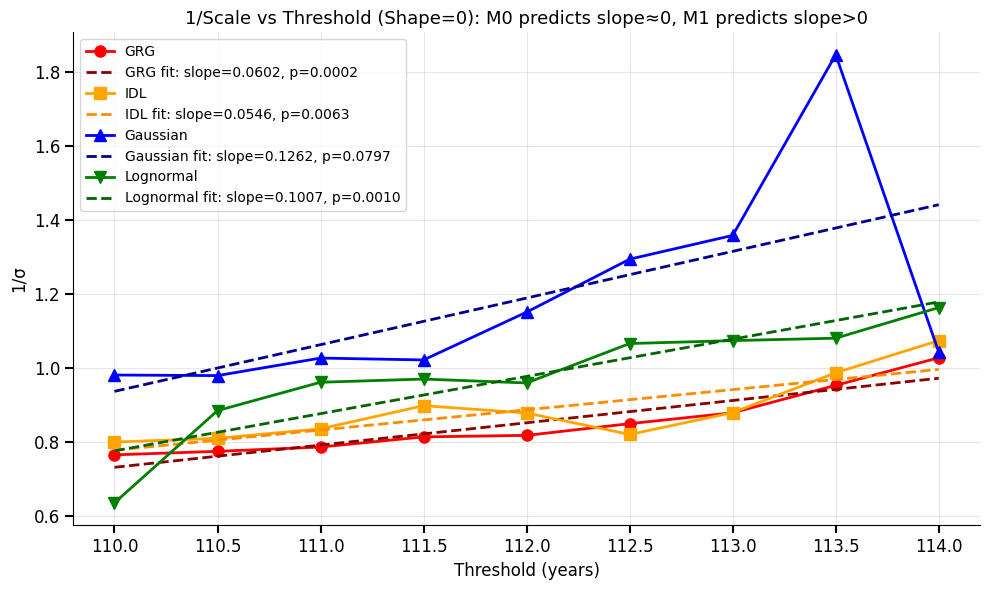

In [147]:
# Threshold stability analysis: Fit GPD with fixed shape=0 at multiple thresholds
from scipy.stats import genpareto, linregress

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

thresholds = [110, 110.5, 111, 111.5, 112, 112.5, 113, 113.5, 114]
all_deaths_df = df.copy()
all_deaths_df['age_at_death'] = all_deaths_df['Years'] + all_deaths_df['Days'] / 365.25

grg_scales, idl_scales, gaussian_scales, lognormal_scales = [], [], [], []

# Get top 1000 deaths from simulations
gaussian_top_1000 = np.sort(gaussian_factor_result)[-1000:]
lognormal_top_1000 = np.sort(lognormal_factor_result)[-1000:]

for threshold in thresholds:
    grg_excess = all_deaths_df[all_deaths_df['age_at_death'] > threshold]['age_at_death'] - threshold
    idl_excess = df_110_gpt[df_110_gpt['age_at_death'] > threshold]['age_at_death'] - threshold
    gaussian_excess = gaussian_top_1000[gaussian_top_1000 > threshold] - threshold
    lognormal_excess = lognormal_top_1000[lognormal_top_1000 > threshold] - threshold
    
    grg_scales.append(genpareto.fit(grg_excess, floc=0, f0=0)[2])
    idl_scales.append(genpareto.fit(idl_excess, floc=0, f0=0)[2])
    gaussian_scales.append(genpareto.fit(gaussian_excess, floc=0, f0=0)[2])
    lognormal_scales.append(genpareto.fit(lognormal_excess, floc=0, f0=0)[2])

grg_inv = [1/s for s in grg_scales]
idl_inv = [1/s for s in idl_scales]
gaussian_inv = [1/s for s in gaussian_scales]
lognormal_inv = [1/s for s in lognormal_scales]

grg_slope, grg_int, grg_r, grg_p, _ = linregress(thresholds, grg_inv)
idl_slope, idl_int, idl_r, idl_p, _ = linregress(thresholds, idl_inv)
gaussian_slope, gaussian_int, gaussian_r, gaussian_p, _ = linregress(thresholds, gaussian_inv)
lognormal_slope, lognormal_int, lognormal_r, lognormal_p, _ = linregress(thresholds, lognormal_inv)

ax.plot(thresholds, grg_inv, 'o-', linewidth=2, markersize=8, color='red', label='GRG')
ax.plot(thresholds, [grg_slope*t + grg_int for t in thresholds], '--', linewidth=2, color='darkred', 
        label=f'GRG fit: slope={grg_slope:.4f}, p={grg_p:.4f}')
ax.plot(thresholds, idl_inv, 's-', linewidth=2, markersize=8, color='orange', label='IDL')
ax.plot(thresholds, [idl_slope*t + idl_int for t in thresholds], '--', linewidth=2, color='darkorange', 
        label=f'IDL fit: slope={idl_slope:.4f}, p={idl_p:.4f}')
ax.plot(thresholds, gaussian_inv, '^-', linewidth=2, markersize=8, color='blue', label='Gaussian')
ax.plot(thresholds, [gaussian_slope*t + gaussian_int for t in thresholds], '--', linewidth=2, color='darkblue', 
        label=f'Gaussian fit: slope={gaussian_slope:.4f}, p={gaussian_p:.4f}')
ax.plot(thresholds, lognormal_inv, 'v-', linewidth=2, markersize=8, color='green', label='Lognormal')
ax.plot(thresholds, [lognormal_slope*t + lognormal_int for t in thresholds], '--', linewidth=2, color='darkgreen', 
        label=f'Lognormal fit: slope={lognormal_slope:.4f}, p={lognormal_p:.4f}')

ax.set_xlabel('Threshold (years)', fontsize=12)
ax.set_ylabel('1/σ', fontsize=12)
ax.set_title('1/Scale vs Threshold (Shape=0): M0 predicts slope≈0, M1 predicts slope>0', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Gaussian Gamma (Shape) 95% CI: [-0.1667, -0.0047]
Gaussian Sigma (Scale) 95% CI: [0.9794, 1.2399]
Lognormal Gamma (Shape) 95% CI: [-0.3128, -0.2272]
Lognormal Sigma (Scale) 95% CI: [1.8304, 2.0618]
GRG Gamma (Shape) 95% CI: [-0.0807, -0.0199]
GRG Sigma (Scale) 95% CI: [1.3193, 1.4291]
IDL Gamma (Shape) 95% CI: [-0.1111, -0.0039]
IDL Sigma (Scale) 95% CI: [1.2229, 1.4269]


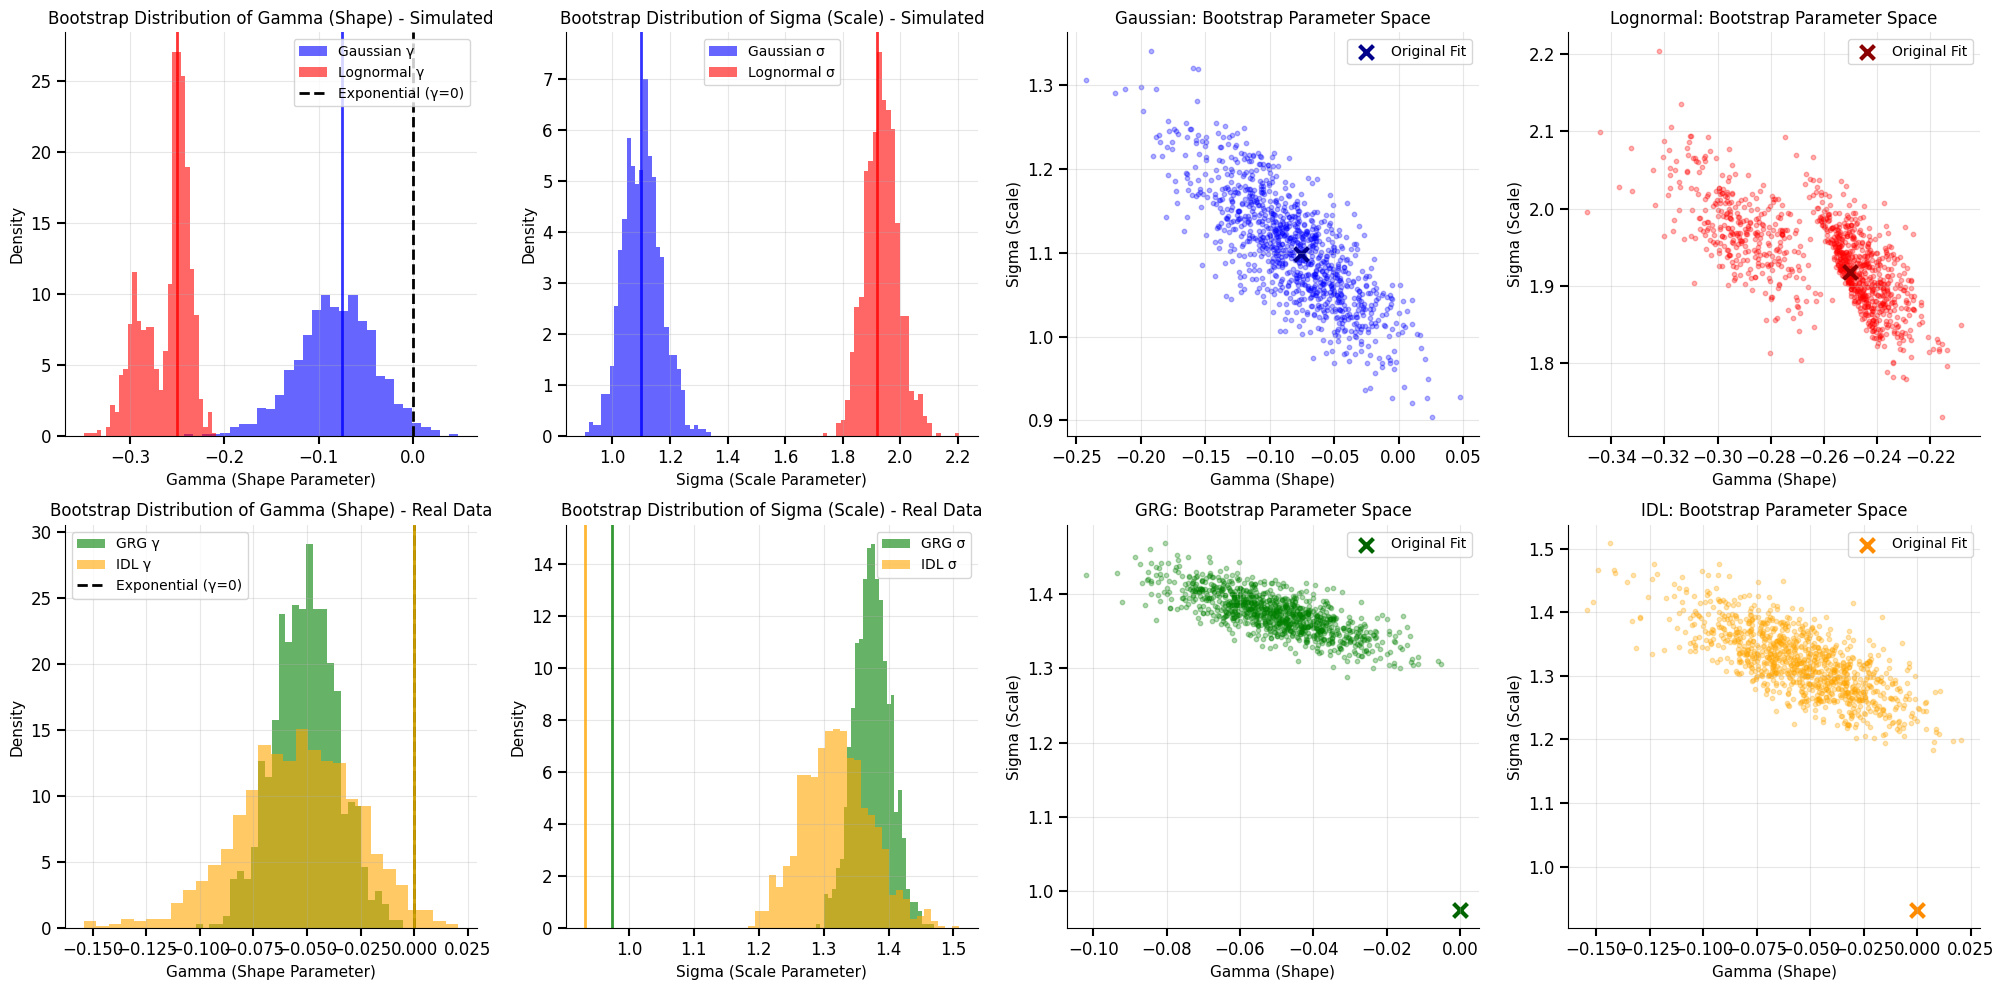

In [134]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

def bootstrap_gpd_params(data, threshold, n_boot=1000, confidence=0.95):
    """Bootstrap GPD parameters for excess ages above threshold"""
    boot_shapes = []
    boot_scales = []
    
    for _ in range(n_boot):
        # Resample with replacement
        sample = np.random.choice(data, size=len(data), replace=True)
        
        # Filter above threshold and calculate excess
        sample_above = sample[sample > threshold]
        sample_excess = sample_above - threshold
        
        # Fit GPD (fix location at 0 since we are modeling excess)
        shape, _, scale = genpareto.fit(sample_excess, floc=0)
        boot_shapes.append(shape)
        boot_scales.append(scale)
        
    boot_shapes = np.array(boot_shapes)
    boot_scales = np.array(boot_scales)
    
    # Calculate Confidence Intervals
    alpha = (1 - confidence) / 2
    shape_lower = np.percentile(boot_shapes, alpha * 100)
    shape_upper = np.percentile(boot_shapes, (1 - alpha) * 100)
    scale_lower = np.percentile(boot_scales, alpha * 100)
    scale_upper = np.percentile(boot_scales, (1 - alpha) * 100)
    
    return boot_shapes, boot_scales, (shape_lower, shape_upper), (scale_lower, scale_upper)

threshold = 110

# Run Bootstrap for Gaussian
g_shapes, g_scales, g_shape_ci, g_scale_ci = bootstrap_gpd_params(gaussian_factor_result, threshold)
print(f"Gaussian Gamma (Shape) 95% CI: [{g_shape_ci[0]:.4f}, {g_shape_ci[1]:.4f}]")
print(f"Gaussian Sigma (Scale) 95% CI: [{g_scale_ci[0]:.4f}, {g_scale_ci[1]:.4f}]")

# Run Bootstrap for Lognormal
l_shapes, l_scales, l_shape_ci, l_scale_ci = bootstrap_gpd_params(lognormal_factor_result, threshold)
print(f"Lognormal Gamma (Shape) 95% CI: [{l_shape_ci[0]:.4f}, {l_shape_ci[1]:.4f}]")
print(f"Lognormal Sigma (Scale) 95% CI: [{l_scale_ci[0]:.4f}, {l_scale_ci[1]:.4f}]")

# Run Bootstrap for GRG
all_deaths_df = df.copy()
all_deaths_df['age_at_death'] = all_deaths_df['Years'] + all_deaths_df['Days'] / 365.25
grg_ages = all_deaths_df['age_at_death'].values
grg_shapes, grg_scales, grg_shape_ci, grg_scale_ci = bootstrap_gpd_params(grg_ages, threshold)
print(f"GRG Gamma (Shape) 95% CI: [{grg_shape_ci[0]:.4f}, {grg_shape_ci[1]:.4f}]")
print(f"GRG Sigma (Scale) 95% CI: [{grg_scale_ci[0]:.4f}, {grg_scale_ci[1]:.4f}]")

# Run Bootstrap for IDL
idl_ages = df_110_gpt['age_at_death'].values
idl_shapes, idl_scales, idl_shape_ci, idl_scale_ci = bootstrap_gpd_params(idl_ages, threshold)
print(f"IDL Gamma (Shape) 95% CI: [{idl_shape_ci[0]:.4f}, {idl_shape_ci[1]:.4f}]")
print(f"IDL Sigma (Scale) 95% CI: [{idl_scale_ci[0]:.4f}, {idl_scale_ci[1]:.4f}]")

# Plot histograms - 2 rows, 4 columns
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Simulated data (Gaussian and Lognormal)
# Plot Gamma (Shape) distributions
axes[0, 0].hist(g_shapes, bins=30, alpha=0.6, label='Gaussian γ', color='blue', density=True)
axes[0, 0].hist(l_shapes, bins=30, alpha=0.6, label='Lognormal γ', color='red', density=True)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=2, label='Exponential (γ=0)')
axes[0, 0].axvline(gaussian_shape, color='blue', linestyle='-', linewidth=2, alpha=0.8)
axes[0, 0].axvline(lognormal_shape, color='red', linestyle='-', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Gamma (Shape Parameter)', fontsize=11)
axes[0, 0].set_ylabel('Density', fontsize=11)
axes[0, 0].set_title('Bootstrap Distribution of Gamma (Shape) - Simulated', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot Sigma (Scale) distributions
axes[0, 1].hist(g_scales, bins=30, alpha=0.6, label='Gaussian σ', color='blue', density=True)
axes[0, 1].hist(l_scales, bins=30, alpha=0.6, label='Lognormal σ', color='red', density=True)
axes[0, 1].axvline(gaussian_scale, color='blue', linestyle='-', linewidth=2, alpha=0.8)
axes[0, 1].axvline(lognormal_scale, color='red', linestyle='-', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Sigma (Scale Parameter)', fontsize=11)
axes[0, 1].set_ylabel('Density', fontsize=11)
axes[0, 1].set_title('Bootstrap Distribution of Sigma (Scale) - Simulated', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot Gaussian parameters scatter
axes[0, 2].scatter(g_shapes, g_scales, alpha=0.3, s=10, color='blue')
axes[0, 2].scatter(gaussian_shape, gaussian_scale, color='darkblue', s=100, marker='x', linewidths=3, label='Original Fit')
axes[0, 2].set_xlabel('Gamma (Shape)', fontsize=11)
axes[0, 2].set_ylabel('Sigma (Scale)', fontsize=11)
axes[0, 2].set_title('Gaussian: Bootstrap Parameter Space', fontsize=12)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot Lognormal parameters scatter
axes[0, 3].scatter(l_shapes, l_scales, alpha=0.3, s=10, color='red')
axes[0, 3].scatter(lognormal_shape, lognormal_scale, color='darkred', s=100, marker='x', linewidths=3, label='Original Fit')
axes[0, 3].set_xlabel('Gamma (Shape)', fontsize=11)
axes[0, 3].set_ylabel('Sigma (Scale)', fontsize=11)
axes[0, 3].set_title('Lognormal: Bootstrap Parameter Space', fontsize=12)
axes[0, 3].legend()
axes[0, 3].grid(True, alpha=0.3)

# Row 2: Real data (GRG and IDL)
# Plot Gamma (Shape) distributions
axes[1, 0].hist(grg_shapes, bins=30, alpha=0.6, label='GRG γ', color='green', density=True)
axes[1, 0].hist(idl_shapes, bins=30, alpha=0.6, label='IDL γ', color='orange', density=True)
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=2, label='Exponential (γ=0)')
axes[1, 0].axvline(grg_shape, color='green', linestyle='-', linewidth=2, alpha=0.8)
axes[1, 0].axvline(idl_shape, color='orange', linestyle='-', linewidth=2, alpha=0.8)
axes[1, 0].set_xlabel('Gamma (Shape Parameter)', fontsize=11)
axes[1, 0].set_ylabel('Density', fontsize=11)
axes[1, 0].set_title('Bootstrap Distribution of Gamma (Shape) - Real Data', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot Sigma (Scale) distributions
axes[1, 1].hist(grg_scales, bins=30, alpha=0.6, label='GRG σ', color='green', density=True)
axes[1, 1].hist(idl_scales, bins=30, alpha=0.6, label='IDL σ', color='orange', density=True)
axes[1, 1].axvline(grg_scale, color='green', linestyle='-', linewidth=2, alpha=0.8)
axes[1, 1].axvline(idl_scale, color='orange', linestyle='-', linewidth=2, alpha=0.8)
axes[1, 1].set_xlabel('Sigma (Scale Parameter)', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('Bootstrap Distribution of Sigma (Scale) - Real Data', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot GRG parameters scatter
axes[1, 2].scatter(grg_shapes, grg_scales, alpha=0.3, s=10, color='green')
axes[1, 2].scatter(grg_shape, grg_scale, color='darkgreen', s=100, marker='x', linewidths=3, label='Original Fit')
axes[1, 2].set_xlabel('Gamma (Shape)', fontsize=11)
axes[1, 2].set_ylabel('Sigma (Scale)', fontsize=11)
axes[1, 2].set_title('GRG: Bootstrap Parameter Space', fontsize=12)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Plot IDL parameters scatter
axes[1, 3].scatter(idl_shapes, idl_scales, alpha=0.3, s=10, color='orange')
axes[1, 3].scatter(idl_shape, idl_scale, color='darkorange', s=100, marker='x', linewidths=3, label='Original Fit')
axes[1, 3].set_xlabel('Gamma (Shape)', fontsize=11)
axes[1, 3].set_ylabel('Sigma (Scale)', fontsize=11)
axes[1, 3].set_title('IDL: Bootstrap Parameter Space', fontsize=12)
axes[1, 3].legend()
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Gaussian Gamma (Shape) 95% CI: [-0.1665, 0.0008]
Gaussian Sigma (Scale) 95% CI: [0.9746, 1.2428]
Lognormal Gamma (Shape) 95% CI: [-0.1554, -0.0467]
Lognormal Sigma (Scale) 95% CI: [1.1362, 1.3340]
IDL Gamma (Shape) 95% CI: [-0.1139, -0.0029]
IDL Sigma (Scale) 95% CI: [1.2288, 1.4145]
IDL Original Fit - Gamma (Shape): -0.0526, Sigma (Scale): 1.3178


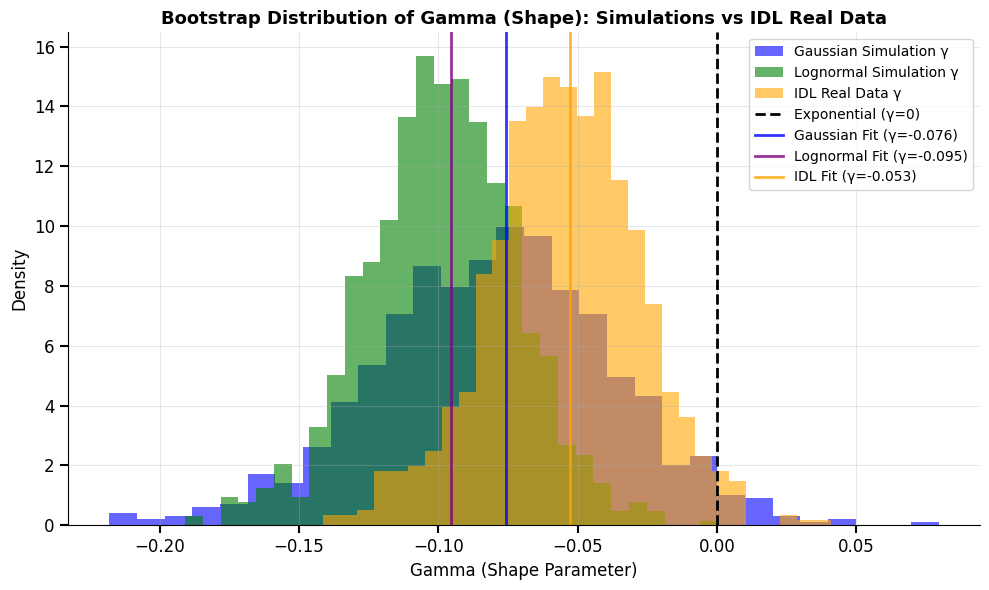

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

def bootstrap_gpd_params(data, threshold, n_boot=1000, confidence=0.95, shift_to_zero=False):
    """Bootstrap GPD parameters for excess ages above threshold"""
    boot_shapes = []
    boot_scales = []
    
    for _ in range(n_boot):
        # Resample with replacement
        sample = np.random.choice(data, size=len(data), replace=True)
        
        # Filter above threshold and calculate excess
        sample_above = sample[sample > threshold]
        sample_excess = sample_above - threshold
        
        # Shift to zero if needed (for lognormal)
        if shift_to_zero and len(sample_excess) > 0:
            sample_excess = sample_excess - sample_excess.min()
        
        # Fit GPD (fix location at 0 since we are modeling excess)
        shape, _, scale = genpareto.fit(sample_excess, floc=0)
        boot_shapes.append(shape)
        boot_scales.append(scale)
        
    boot_shapes = np.array(boot_shapes)
    boot_scales = np.array(boot_scales)
    
    # Calculate Confidence Intervals
    alpha = (1 - confidence) / 2
    shape_lower = np.percentile(boot_shapes, alpha * 100)
    shape_upper = np.percentile(boot_shapes, (1 - alpha) * 100)
    scale_lower = np.percentile(boot_scales, alpha * 100)
    scale_upper = np.percentile(boot_scales, (1 - alpha) * 100)
    
    return boot_shapes, boot_scales, (shape_lower, shape_upper), (scale_lower, scale_upper)

threshold = 110

# Run Bootstrap for Gaussian
g_shapes, g_scales, g_shape_ci, g_scale_ci = bootstrap_gpd_params(gaussian_factor_result, threshold)
print(f"Gaussian Gamma (Shape) 95% CI: [{g_shape_ci[0]:.4f}, {g_shape_ci[1]:.4f}]")
print(f"Gaussian Sigma (Scale) 95% CI: [{g_scale_ci[0]:.4f}, {g_scale_ci[1]:.4f}]")

# Run Bootstrap for Lognormal (with shift)
ln_shapes, ln_scales, ln_shape_ci, ln_scale_ci = bootstrap_gpd_params(lognormal_factor_result, threshold, shift_to_zero=True)
print(f"Lognormal Gamma (Shape) 95% CI: [{ln_shape_ci[0]:.4f}, {ln_shape_ci[1]:.4f}]")
print(f"Lognormal Sigma (Scale) 95% CI: [{ln_scale_ci[0]:.4f}, {ln_scale_ci[1]:.4f}]")

# Run Bootstrap for IDL
idl_ages = df_110_gpt['age_at_death'].values
idl_shapes, idl_scales, idl_shape_ci, idl_scale_ci = bootstrap_gpd_params(idl_ages, threshold)
print(f"IDL Gamma (Shape) 95% CI: [{idl_shape_ci[0]:.4f}, {idl_shape_ci[1]:.4f}]")
print(f"IDL Sigma (Scale) 95% CI: [{idl_scale_ci[0]:.4f}, {idl_scale_ci[1]:.4f}]")

# Calculate IDL shape parameter from original fit
idl_ages_above = idl_ages[idl_ages > threshold]
idl_excess = idl_ages_above - threshold
idl_shape, _, idl_scale = genpareto.fit(idl_excess, floc=0)
print(f"IDL Original Fit - Gamma (Shape): {idl_shape:.4f}, Sigma (Scale): {idl_scale:.4f}")

# Create single plot comparing Gaussian simulation, Lognormal simulation, and IDL real data
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot Gamma (Shape) distributions
ax.hist(g_shapes, bins=30, alpha=0.6, label='Gaussian Simulation γ', color='blue', density=True)
ax.hist(ln_shapes, bins=30, alpha=0.6, label='Lognormal Simulation γ', color='green', density=True)
ax.hist(idl_shapes, bins=30, alpha=0.6, label='IDL Real Data γ', color='orange', density=True)
ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Exponential (γ=0)')
ax.axvline(gaussian_shape, color='blue', linestyle='-', linewidth=2, alpha=0.8, label=f'Gaussian Fit (γ={gaussian_shape:.3f})')
ax.axvline(lognormal_shape, color='purple', linestyle='-', linewidth=2, alpha=0.8, label=f'Lognormal Fit (γ={lognormal_shape:.3f})')
ax.axvline(idl_shape, color='orange', linestyle='-', linewidth=2, alpha=0.8, label=f'IDL Fit (γ={idl_shape:.3f})')
ax.set_xlabel('Gamma (Shape Parameter)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Bootstrap Distribution of Gamma (Shape): Simulations vs IDL Real Data', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# oldest n living persons

## saving results for top 100 living persons using go with winners simulation

In [287]:
from scipy.interpolate import interp1d
import pickle
import os

# Setup parameters
n_sim = 10000
import model_param_calibrations as mcal
danish_dict = mcal.sr_denmark_dict.copy()
danish_Xc_std = mcal.sr_calibrations['denmark']['Xc_std']

# Define factors and simulation parameters (steps of 0.05, clean values modulo 0.05)
factors = np.round(np.arange(1.0, 1.6 + 0.025, 0.05) / 0.05) * 0.05
factors = np.round(factors, 2)  # Ensure nice formatting
n_runs = 25
n_samples = int(1e7)
sim_ranks = list(range(1, 101))  # Track top 100 ranks

def build_inverse_cdf(tspan, cdf):
    """Build inverse CDF sampler using log-space interpolation."""
    if not np.all(np.diff(cdf) >= 0):
        raise ValueError("CDF is not monotone. Cannot invert safely.")
    
    cdf_min = np.min(cdf[cdf > 0])
    logF = np.log(cdf + 1e-300)
    inv = interp1d(logF, tspan, kind="linear", bounds_error=False, 
                   fill_value=(tspan[0], tspan[-1]))
    
    def sample(n):
        u = np.clip(np.random.rand(n), cdf_min, 1.0)
        return inv(np.log(u))
    
    return sample

def run_rank_simulation(sampler, n_runs, n_samples, ranks):
    """Run multiple simulations and collect rank statistics."""
    results_by_run = {rank: [] for rank in ranks}
    
    for _ in range(n_runs):
        samples = sampler(n_samples)
        sorted_samples = np.sort(samples)[::-1]
        
        for rank in ranks:
            results_by_run[rank].append(sorted_samples[rank - 1] if len(sorted_samples) >= rank else np.nan)
    
    # Calculate means and SEMs
    means = {rank: np.nanmean(results_by_run[rank]) for rank in ranks}
    sems = {rank: np.nanstd(results_by_run[rank]) / np.sqrt(np.sum(~np.isnan(results_by_run[rank]))) 
            for rank in ranks}
    
    return means, sems, results_by_run

# Dictionary to store all results
all_results = {}

for factor in factors:
    print(f"\n{'='*60}\nRunning simulation for factor = {factor:.2f}\n{'='*60}")
    
    # Adjust Xc and create parameter distributions
    danish_dict_factor = danish_dict.copy()
    danish_dict_factor['Xc'] = 0.85 * factor * danish_dict['Xc']
    
    danish_param_dist = utils.create_param_distribution_dict(
        params_dict=danish_dict_factor, params='Xc', std=danish_Xc_std,
        n=n_sim, family='None', dist_type='lognormal'
    )

    # Create go-with-winners simulation
    go_ww_sim_hetero = utils.create_go_ww_simulation(
        params_dict=danish_param_dist, n=n_sim, tmin=0, tmax=130,
        x0=1e-6, dt=0.005, units='years', calc_pdf=False, print_out=True
    )
    # Build sampler and run simulations
    tspan = go_ww_sim_hetero.tspan[100:]
    cdf = 1 - go_ww_sim_hetero.survival[100:]
    # Fix non-monotonicity by enforcing monotonicity (small numerical errors)
    cdf_fixed = np.maximum.accumulate(cdf)
    
    sampler = build_inverse_cdf(tspan, cdf_fixed)
    sim_means, sim_sems, results_by_run = run_rank_simulation(sampler, n_runs, n_samples, sim_ranks)
    
    # Print sample results
    print(f"\nSimulation results for factor {factor:.2f} (means and SEMs):")
    for rank in [1, 2, 5, 10, 30, 50, 100]:
        print(f"Rank {rank}: mean = {sim_means[rank]:.3f}, SEM = {sim_sems[rank]:.3f}")
    
    # Store results
    all_results[factor] = {
        'sim_means': sim_means,
        'sim_sems': sim_sems,
        'results_by_run': results_by_run,
        'tspan': tspan,
        'cdf': cdf,
        'survival': go_ww_sim_hetero.survival
    }

# Save results
os.makedirs('saved_results', exist_ok=True)
pickle_filename = 'saved_results/go_with_ww_log_normal_max_lifespan_factors_1.00to1.50_top100_n10000000_repeats50.pkl'

with open(pickle_filename, 'wb') as f:
    pickle.dump(all_results, f)

print(f"\n{'='*60}\nAll results saved to {pickle_filename}\n{'='*60}")



Running simulation for factor = 1.00
Heterogeneous mode: 50 parameter groups
  Group sizes: min=200, max=200, mean=200.0
  Varying parameters: ['Xc']

Simulation results for factor 1.00 (means and SEMs):
Rank 1: mean = 111.125, SEM = 0.230
Rank 2: mean = 110.376, SEM = 0.146
Rank 5: mean = 109.423, SEM = 0.085
Rank 10: mean = 108.617, SEM = 0.060
Rank 30: mean = 107.433, SEM = 0.044
Rank 50: mean = 106.844, SEM = 0.022
Rank 100: mean = 105.962, SEM = 0.024

Running simulation for factor = 1.05
Heterogeneous mode: 50 parameter groups
  Group sizes: min=200, max=200, mean=200.0
  Varying parameters: ['Xc']

Simulation results for factor 1.05 (means and SEMs):
Rank 1: mean = 111.424, SEM = 0.173
Rank 2: mean = 110.752, SEM = 0.097
Rank 5: mean = 110.010, SEM = 0.065
Rank 10: mean = 109.403, SEM = 0.063
Rank 30: mean = 108.298, SEM = 0.047
Rank 50: mean = 107.761, SEM = 0.031
Rank 100: mean = 107.017, SEM = 0.021

Running simulation for factor = 1.10
Heterogeneous mode: 50 parameter group

In [178]:
all_results[1.0].keys()

dict_keys(['sim_means', 'sim_sems', 'results_by_run', 'tspan', 'cdf', 'survival'])

/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/2607337003.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


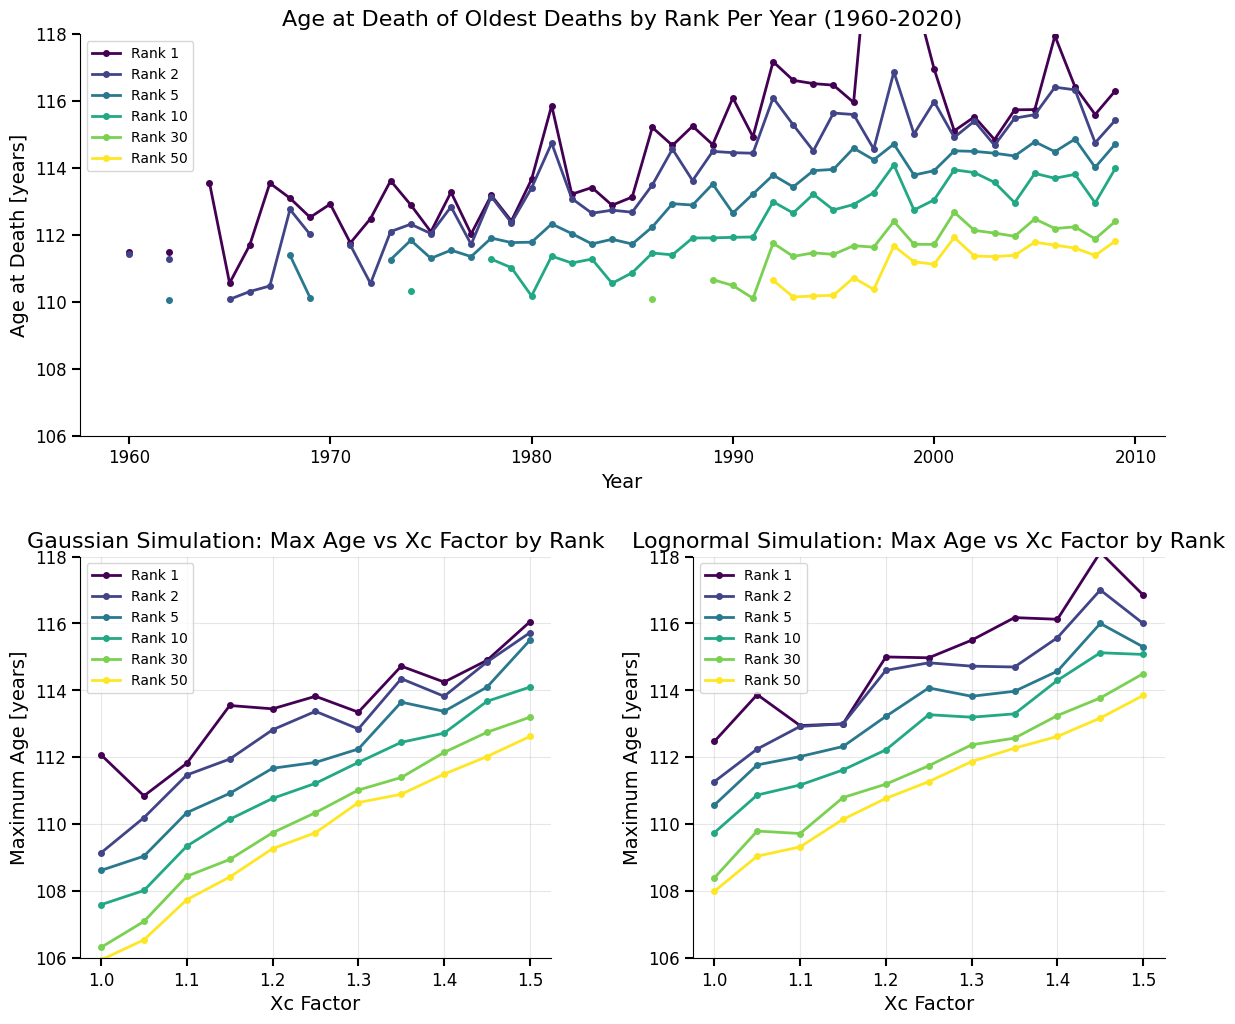

In [ ]:
# Define ranks to track
ranks = [1, 2, 5, 10, 30, 50]

# Calculate age at death of oldest deaths for each rank for each year from 1960 to 2020
years = range(1960, 2010)
ages_by_rank = {rank: [] for rank in ranks}

for year in years:
    # Filter people who died in this year
    died_this_year = df[df['Died'] == year]
    
    if len(died_this_year) > 0:
        # Calculate age at death (death year - birth year + Days/365.25)
        ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
        # Sort ages in descending order
        sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
        
        # For each rank, get the age if it exists
        for rank in ranks:
            if len(sorted_ages) >= rank:
                ages_by_rank[rank].append(sorted_ages[rank - 1])
            else:
                ages_by_rank[rank].append(np.nan)
    else:
        for rank in ranks:
            ages_by_rank[rank].append(np.nan)

# Load saved results
import pickle

# Load the saved results
pickle_filename = 'saved_results/max_lifespan_Xc_factors_1.00to1.50_top50_n10000000_repeats1_both_dists.pkl'

with open(pickle_filename, 'rb') as f:
    results_by_dist = pickle.load(f)

# Create 2x2 subplot figure
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Top plot: Age at death vs year by rank (spans both columns)
ax_top = fig.add_subplot(gs[0, :])
colors = plt.cm.viridis(np.linspace(0, 1, len(ranks)))
for i, rank in enumerate(ranks):
    ax_top.plot(years, ages_by_rank[rank], marker='o', linestyle='-', linewidth=2, markersize=4, 
                color=colors[i], label=f'Rank {rank}')
ax_top.set_xlabel('Year', fontsize=14)
ax_top.set_ylabel('Age at Death [years]', fontsize=14)
ax_top.set_title('Age at Death of Oldest Deaths by Rank Per Year (1960-2020)', fontsize=16)
ax_top.set_ylim(106, 118)
ax_top.legend()

# Bottom left: Gaussian simulation - max age vs Xc factor by rank
ax_bottom_left = fig.add_subplot(gs[1, 0])
gaussian_results = results_by_dist['gaussian']
factors_array = gaussian_results['factors']

for i, rank in enumerate(ranks):
    # Extract mean ages for this rank across all factors
    mean_ages_for_rank = []
    for factor_result in gaussian_results['factor_results']:
        # rank-1 because arrays are 0-indexed (rank 1 is index 0)
        mean_ages_for_rank.append(factor_result['mean_by_rank'][rank - 1])
    
    ax_bottom_left.plot(factors_array, mean_ages_for_rank, marker='o', linestyle='-', 
                        linewidth=2, markersize=4, color=colors[i], label=f'Rank {rank}')

ax_bottom_left.set_xlabel('Xc Factor', fontsize=14)
ax_bottom_left.set_ylabel('Maximum Age [years]', fontsize=14)
ax_bottom_left.set_title('Gaussian Simulation: Max Age vs Xc Factor by Rank', fontsize=16)
ax_bottom_left.set_ylim(106, 118)
ax_bottom_left.legend()
ax_bottom_left.grid(True, alpha=0.3)

# Bottom right: Lognormal simulation - max age vs Xc factor by rank
ax_bottom_right = fig.add_subplot(gs[1, 1])
lognormal_results = results_by_dist['lognormal']

for i, rank in enumerate(ranks):
    # Extract mean ages for this rank across all factors
    mean_ages_for_rank = []
    for factor_result in lognormal_results['factor_results']:
        # rank-1 because arrays are 0-indexed (rank 1 is index 0)
        mean_ages_for_rank.append(factor_result['mean_by_rank'][rank - 1])
    
    ax_bottom_right.plot(factors_array, mean_ages_for_rank, marker='o', linestyle='-', 
                         linewidth=2, markersize=4, color=colors[i], label=f'Rank {rank}')

ax_bottom_right.set_xlabel('Xc Factor', fontsize=14)
ax_bottom_right.set_ylabel('Maximum Age [years]', fontsize=14)
ax_bottom_right.set_title('Lognormal Simulation: Max Age vs Xc Factor by Rank', fontsize=16)
ax_bottom_right.set_ylim(106, 118)
ax_bottom_right.legend()
ax_bottom_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


/var/folders/cn/lhb2c_1j601c1tw27_rr981m0000gp/T/ipykernel_24650/1672268633.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


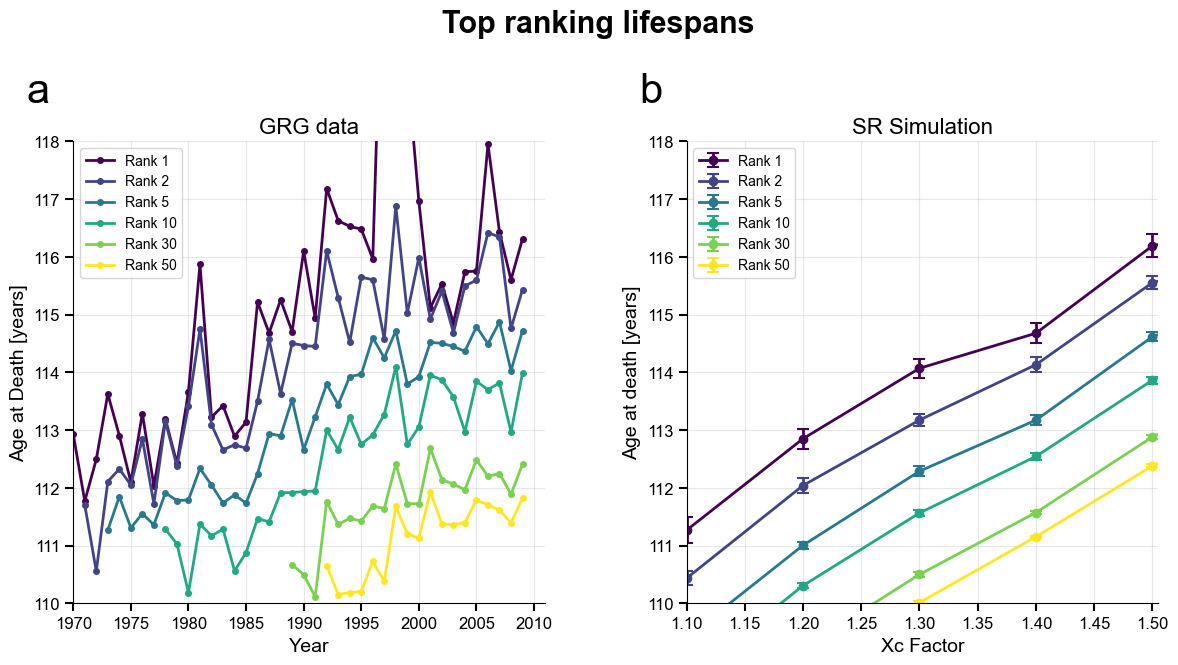

In [197]:
# Set font to Arial for all plots
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Define ranks to track
ranks = [1, 2, 5, 10, 30, 50]

# Calculate age at death of oldest deaths for each rank for each year from 1960 to 2020
years = range(1970, 2010)
ages_by_rank = {rank: [] for rank in ranks}

for year in years:
    # Filter people who died in this year
    died_this_year = df[df['Died'] == year]
    
    if len(died_this_year) > 0:
        # Calculate age at death (death year - birth year + Days/365.25)
        ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
        # Sort ages in descending order
        sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
        
        # For each rank, get the age if it exists
        for rank in ranks:
            if len(sorted_ages) >= rank:
                ages_by_rank[rank].append(sorted_ages[rank - 1])
            else:
                ages_by_rank[rank].append(np.nan)
    else:
        for rank in ranks:
            ages_by_rank[rank].append(np.nan)

# Remove isolated points, i.e., keep only stretches with two or more consecutive non-NaN values for plotting
def get_contiguous_segments(xvalues, yvalues):
    segments_x, segments_y = [], []
    x_seg, y_seg = [], []
    for xi, yi in zip(xvalues, yvalues):
        if not np.isnan(yi):
            x_seg.append(xi)
            y_seg.append(yi)
        else:
            # End of a non-NaN segment
            if len(x_seg) >= 2:
                segments_x.append(x_seg)
                segments_y.append(y_seg)
            x_seg, y_seg = [], []
    # Append last segment if it is long enough
    if len(x_seg) >= 2:
        segments_x.append(x_seg)
        segments_y.append(y_seg)
    return segments_x, segments_y

# Load saved results from the go-with-winners simulation
import pickle
pickle_filename = 'saved_results/go_with_ww_max_lifespan_factors_1.00to1.50_top100_n10000000_repeats50.pkl'

with open(pickle_filename, 'rb') as f:
    all_results = pickle.load(f)

# Create 1x2 subplot figure
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.3)

# Left plot: Age at death vs year by rank (data)
ax_left = fig.add_subplot(gs[0, 0])
colors = plt.cm.viridis(np.linspace(0, 1, len(ranks)))
for i, rank in enumerate(ranks):
    # Remove isolated points: only plot stretches with 2+ consecutive non-nans
    x_segs, y_segs = get_contiguous_segments(list(years), ages_by_rank[rank])
    for x_seg, y_seg in zip(x_segs, y_segs):
        ax_left.plot(x_seg, y_seg, marker='o', linestyle='-', linewidth=2, markersize=4, 
                     color=colors[i], label=f'Rank {rank}' if x_seg is x_segs[0] else None)
ax_left.set_xlabel('Year', fontsize=14)
ax_left.set_ylabel('Age at Death [years]', fontsize=14)
ax_left.set_title('GRG data', fontsize=16)
ax_left.set_xlim(1970, None)
ax_left.set_ylim(110, 118)
ax_left.legend()
ax_left.grid(True, alpha=0.3)

# Right plot: SR simulation - max age vs Xc factor by rank with error bars
ax_right = fig.add_subplot(gs[0, 1])

# Get all factors
factors_array = sorted(all_results.keys())
# Plot with error bars for the selected ranks
for i, rank in enumerate(ranks):
    mean_ages_for_rank = []
    sem_ages_for_rank = []
    
    for factor in factors_array:
        factor_results = all_results[factor]
        mean_ages_for_rank.append(factor_results['sim_means'][rank])
        sem_ages_for_rank.append(factor_results['sim_sems'][rank])
    
    ax_right.errorbar(factors_array, mean_ages_for_rank, yerr=sem_ages_for_rank,
                     marker='o', markersize=6, capsize=4, capthick=1.5,
                     linewidth=2, color=colors[i], label=f'Rank {rank}')

ax_right.set_xlabel('Xc Factor', fontsize=14)
ax_right.set_ylabel('Age at death [years]', fontsize=14)
ax_right.set_title('SR Simulation', fontsize=16)
ax_right.set_ylim(110, 118)
ax_right.set_xlim(1.1, 1.505)
ax_right.legend()
ax_right.grid(True, alpha=0.3)

fig.suptitle('Top ranking lifespans', fontsize=22, fontweight='bold', y=1.1)
# Add panel labels
ax_left.text(-0.1, 1.15, 'a', transform=ax_left.transAxes, fontsize=30, va='top')
ax_right.text(-0.1, 1.15, 'b', transform=ax_right.transAxes, fontsize=30, va='top')

plt.tight_layout()
plt.show()


## Age vs rank

In [293]:
# Load saved results from the go-with-winners simulation
import pickle
pickle_filename = 'saved_results/go_with_ww_log_normal_max_lifespan_factors_1.00to1.50_top100_n10000000_repeats50.pkl'

with open(pickle_filename, 'rb') as f:
    lognormal_results = pickle.load(f)
    
pickle_filename = 'saved_results/go_with_ww_max_lifespan_factors_1.00to1.50_top100_n10000000_repeats50.pkl'

with open(pickle_filename, 'rb') as f:
    gaussian_results = pickle.load(f)


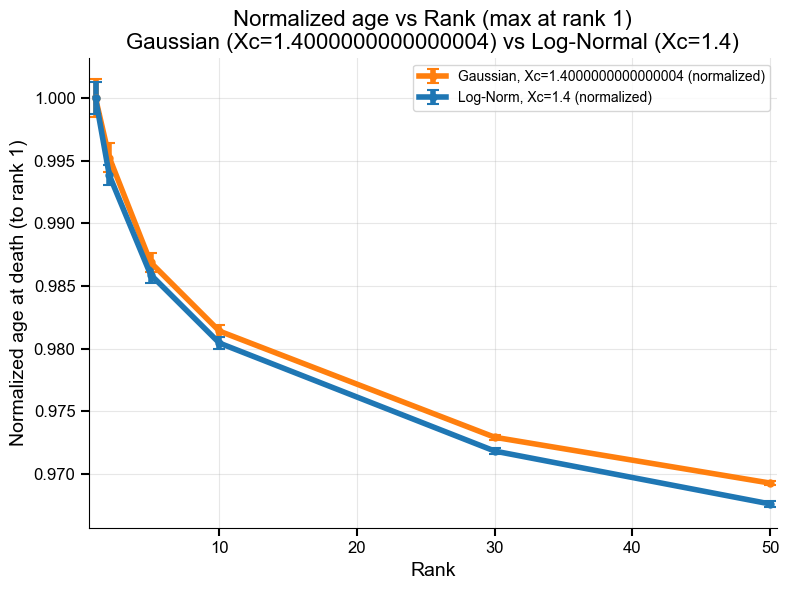

In [296]:
# Compare Gaussian and Log-Normal results for factor 1.4, normalized by their max at rank 1
factor_to_compare = 1.4  # Xc factor to compare
colors_sim = ['C1', 'C0']  # color for gaussian, lognormal

# Utility to find closest factor key in results dict
def get_closest_factor_key(results_dict, factor_val):
    keys = np.array(list(results_dict.keys()))
    # If keys are strings (can happen in pickle), cast them
    if not np.issubdtype(keys.dtype, np.number):
        keys = np.array([float(k) for k in keys])
    closest_idx = np.argmin(np.abs(keys - factor_val))
    return list(results_dict.keys())[closest_idx]

# Find closest available factor in both simulation result dicts
gauss_factor_key = get_closest_factor_key(gaussian_results, factor_to_compare)
logn_factor_key = get_closest_factor_key(lognormal_results, factor_to_compare)

# Gather values for each rank under selected (closest) Xc factor from both Gaussian and Log-Normal
mean_ages_gauss = []
sem_ages_gauss = []
mean_ages_logn = []
sem_ages_logn = []
for rank in ranks:
    mean_ages_gauss.append(gaussian_results[gauss_factor_key]['sim_means'][rank])
    sem_ages_gauss.append(gaussian_results[gauss_factor_key]['sim_sems'][rank])
    mean_ages_logn.append(lognormal_results[logn_factor_key]['sim_means'][rank])
    sem_ages_logn.append(lognormal_results[logn_factor_key]['sim_sems'][rank])

# Normalize by value at rank 1 (i.e., divide all means/sems by value at rank 1 for each model)
norm_factor_gauss = mean_ages_gauss[0]
norm_factor_logn = mean_ages_logn[0]
mean_ages_gauss_norm = np.array(mean_ages_gauss) / norm_factor_gauss
sem_ages_gauss_norm = np.array(sem_ages_gauss) / norm_factor_gauss
mean_ages_logn_norm = np.array(mean_ages_logn) / norm_factor_logn
sem_ages_logn_norm = np.array(sem_ages_logn) / norm_factor_logn

# Plot only normalized simulation curves (with error bars), no data curves
fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(list(ranks), mean_ages_gauss_norm, yerr=sem_ages_gauss_norm, fmt='o-', color=colors_sim[0],
            markersize=5, capsize=4, capthick=1.5, linewidth=4,
            label=f'Gaussian, Xc={gauss_factor_key} (normalized)')
ax.errorbar(list(ranks), mean_ages_logn_norm, yerr=sem_ages_logn_norm, fmt='o-', color=colors_sim[1],
            markersize=5, capsize=4, capthick=1.5, linewidth=4,
            label=f'Log-Norm, Xc={logn_factor_key} (normalized)')

ax.set_xlabel("Rank", fontsize=14)
ax.set_ylabel("Normalized age at death (to rank 1)", fontsize=14)
ax.set_title(f"Normalized age vs Rank (max at rank 1)\n"
             f"Gaussian (Xc={gauss_factor_key}) vs Log-Normal (Xc={logn_factor_key})", fontsize=16)
ax.set_xlim(0.5, 50.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


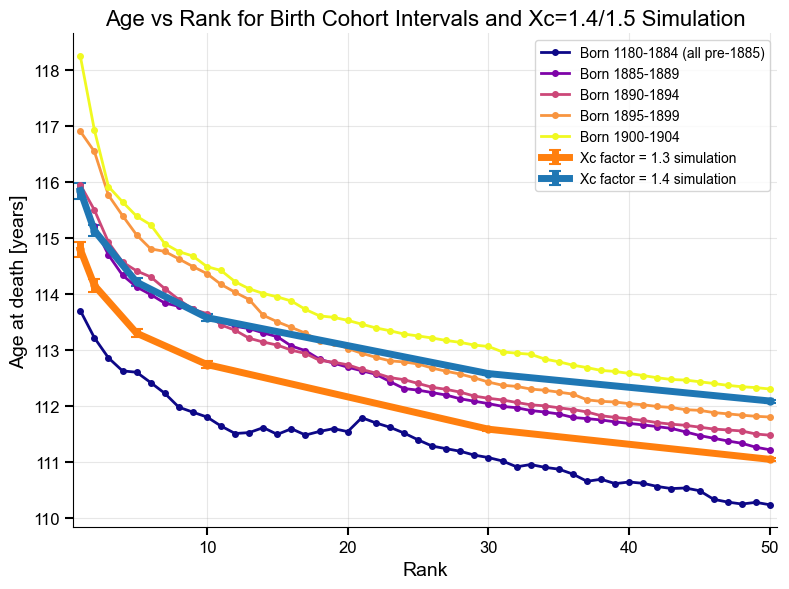

In [292]:
# Plot simulation (Xc=1.4 and Xc=1.5) mean ages vs rank, with sems, and actual data by cohort of birth year

factors_to_plot = [1.3, 1.4]  # Xc factors to plot
colors_sim = ['C1', 'C0']  # one for each factor

# Gather values for each rank under selected Xc factors
sim_curves = []
for i, factor in enumerate(factors_to_plot):
    mean_ages = []
    sem_ages = []
    for rank in ranks:
        mean_ages.append(all_results[factor]['sim_means'][rank])
        sem_ages.append(all_results[factor]['sim_sems'][rank])
    sim_curves.append((mean_ages, sem_ages))
# Plot age at death vs rank for birth year intervals instead of individual years

# Define intervals: [1180,1885), [1885,1890), [1890,1895), [1895,1900), [1900,1905)
interval_bounds = [1180, 1885, 1890, 1895, 1900, 1905]
interval_labels = []
interval_ages_by_rank = []
ranks_50 = range(1, 51)
colors_intervals = plt.cm.plasma(np.linspace(0, 1, len(interval_bounds)-1))

for ivl_idx in range(len(interval_bounds)-1):
    start, end = interval_bounds[ivl_idx], interval_bounds[ivl_idx+1]
    if start < 1885:
        label = f"{start}-{end-1} (all pre-1885)"
    else:
        label = f"{start}-{end-1}"
    interval_labels.append(label)

    # Find all distinct years-of-birth in interval
    in_interval = df[(df['Born'] >= start) & (df['Born'] < end)]
    if len(in_interval) == 0:
        interval_ages_by_rank.append([np.nan]*50)
        continue

    unique_years = sorted(in_interval["Born"].dropna().unique())
    age_ranks_mat = []
    for year in unique_years:
        this_year = in_interval[in_interval["Born"] == year]
        if len(this_year) == 0:
            continue
        ages_at_death = (this_year['Died'] - this_year['Born']) + this_year['Days'] / 365.25
        sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
        ranks_this_year = []
        for rank in ranks_50:
            if len(sorted_ages) >= rank:
                ranks_this_year.append(sorted_ages[rank - 1])
            else:
                ranks_this_year.append(np.nan)
        age_ranks_mat.append(ranks_this_year)
    # Now, take the mean rank curve over years in this interval
    if len(age_ranks_mat) == 0:
        interval_ages_by_rank.append([np.nan]*50)
    else:
        interval_ages_by_rank.append(np.nanmean(age_ranks_mat, axis=0))

# Make a single plot for both simulations and interval cohort curves
fig, ax = plt.subplots(figsize=(8, 6))

# Plot simulation curves (with error bars)
for i, factor in enumerate(factors_to_plot):
    mean_ages, sem_ages = sim_curves[i]
    ax.errorbar(list(ranks), mean_ages, yerr=sem_ages, fmt='o-', color=colors_sim[i],
                markersize=5, capsize=4, capthick=1.5, linewidth=5,
                label=f'Xc factor = {factor:.1f} simulation')

# Plot interval cohort curves: age at death vs rank for each interval
for i, label in enumerate(interval_labels):
    ax.plot(list(ranks_50), interval_ages_by_rank[i], marker='o', linestyle='-', linewidth=2, markersize=4,
            color=colors_intervals[i], label=f'Born {label}')

ax.set_xlabel("Rank", fontsize=14)
ax.set_ylabel("Age at death [years]", fontsize=14)
ax.set_title("Age vs Rank for Birth Cohort Intervals and Xc=1.4/1.5 Simulation", fontsize=16)
ax.set_xlim(0.5, 50.5)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


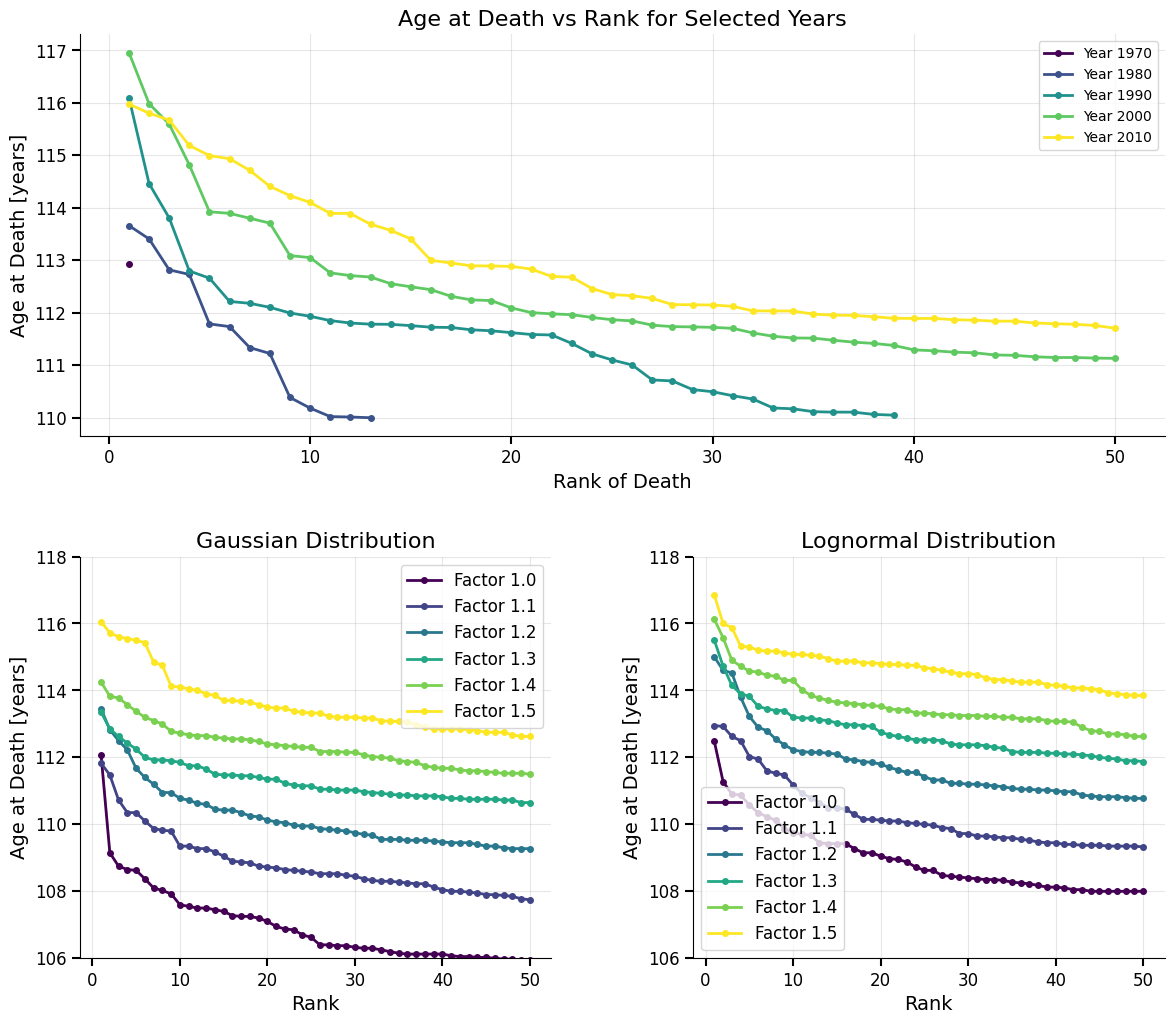

In [7]:
# Define years to plot
years_to_plot = [1970, 1980, 1990, 2000, 2010]

# Define ranks from 1 to 50
ranks = range(1, 51)

# Load saved results
import pickle

# Load the saved results
pickle_filename = 'saved_results/max_lifespan_Xc_factors_1.00to1.50_top50_n10000000_repeats1_both_dists.pkl'

with open(pickle_filename, 'rb') as f:
    results_by_dist = pickle.load(f)

# Create figure with 3 subplots: top row has 1 plot, bottom row has 2 plots
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Top plot: Age at death vs rank for selected years (spans both columns)
ax_top = fig.add_subplot(gs[0, :])
colors_years = plt.cm.viridis(np.linspace(0, 1, len(years_to_plot)))

for i, year in enumerate(years_to_plot):
    # Filter people who died in this year
    died_this_year = df[df['Died'] == year]
    
    if len(died_this_year) > 0:
        # Calculate age at death (death year - birth year + Days/365.25)
        ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
        # Sort ages in descending order
        sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
        
        # Get ages for ranks 1 to 50 (or as many as available)
        ages_for_ranks = []
        for rank in ranks:
            if len(sorted_ages) >= rank:
                ages_for_ranks.append(sorted_ages[rank - 1])
            else:
                ages_for_ranks.append(np.nan)
        
        # Plot the curve for this year
        ax_top.plot(ranks, ages_for_ranks, marker='o', linestyle='-', linewidth=2, markersize=4, 
                    color=colors_years[i], label=f'Year {year}')

ax_top.set_xlabel('Rank of Death', fontsize=14)
ax_top.set_ylabel('Age at Death [years]', fontsize=14)
ax_top.set_title('Age at Death vs Rank for Selected Years', fontsize=16)
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# Factors to plot
factors_to_plot = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
colors_factors = plt.cm.viridis(np.linspace(0, 1, len(factors_to_plot)))

# Ranks (1 to 50)
ranks_sim = np.arange(1, 51)

# Bottom left plot: Gaussian distribution
ax_left = fig.add_subplot(gs[1, 0])
gaussian_results = results_by_dist['gaussian']
for factor, color in zip(factors_to_plot, colors_factors):
    # Find the result for this factor
    for result in gaussian_results['factor_results']:
        if np.isclose(result['factor'], factor, atol=0.01):
            mean_by_rank = result['mean_by_rank']
            sem_by_rank = result['sem_by_rank']
            
            # Plot mean with error bars
            ax_left.plot(ranks_sim, mean_by_rank, marker='o', linestyle='-', linewidth=2, 
                        markersize=4, color=color, label=f'Factor {factor:.1f}')
            ax_left.fill_between(ranks_sim, mean_by_rank - sem_by_rank, mean_by_rank + sem_by_rank, 
                                alpha=0.2, color=color)
            break

ax_left.set_xlabel('Rank', fontsize=14)
ax_left.set_ylabel('Age at Death [years]', fontsize=14)
ax_left.set_title('Gaussian Distribution', fontsize=16)
ax_left.set_ylim(106, 118)
ax_left.legend(fontsize=12)
ax_left.grid(True, alpha=0.3)

# Bottom right plot: Lognormal distribution
ax_right = fig.add_subplot(gs[1, 1])
lognormal_results = results_by_dist['lognormal']
for factor, color in zip(factors_to_plot, colors_factors):
    # Find the result for this factor
    for result in lognormal_results['factor_results']:
        if np.isclose(result['factor'], factor, atol=0.01):
            mean_by_rank = result['mean_by_rank']
            sem_by_rank = result['sem_by_rank']
            
            # Plot mean with error bars
            ax_right.plot(ranks_sim, mean_by_rank, marker='o', linestyle='-', linewidth=2, 
                         markersize=4, color=color, label=f'Factor {factor:.1f}')
            ax_right.fill_between(ranks_sim, mean_by_rank - sem_by_rank, mean_by_rank + sem_by_rank, 
                                 alpha=0.2, color=color)
            break

ax_right.set_xlabel('Rank', fontsize=14)
ax_right.set_ylabel('Age at Death [years]', fontsize=14)
ax_right.set_title('Lognormal Distribution', fontsize=16)
ax_right.set_ylim(106, 118)
ax_right.legend(fontsize=12)
ax_right.grid(True, alpha=0.3)

plt.show()


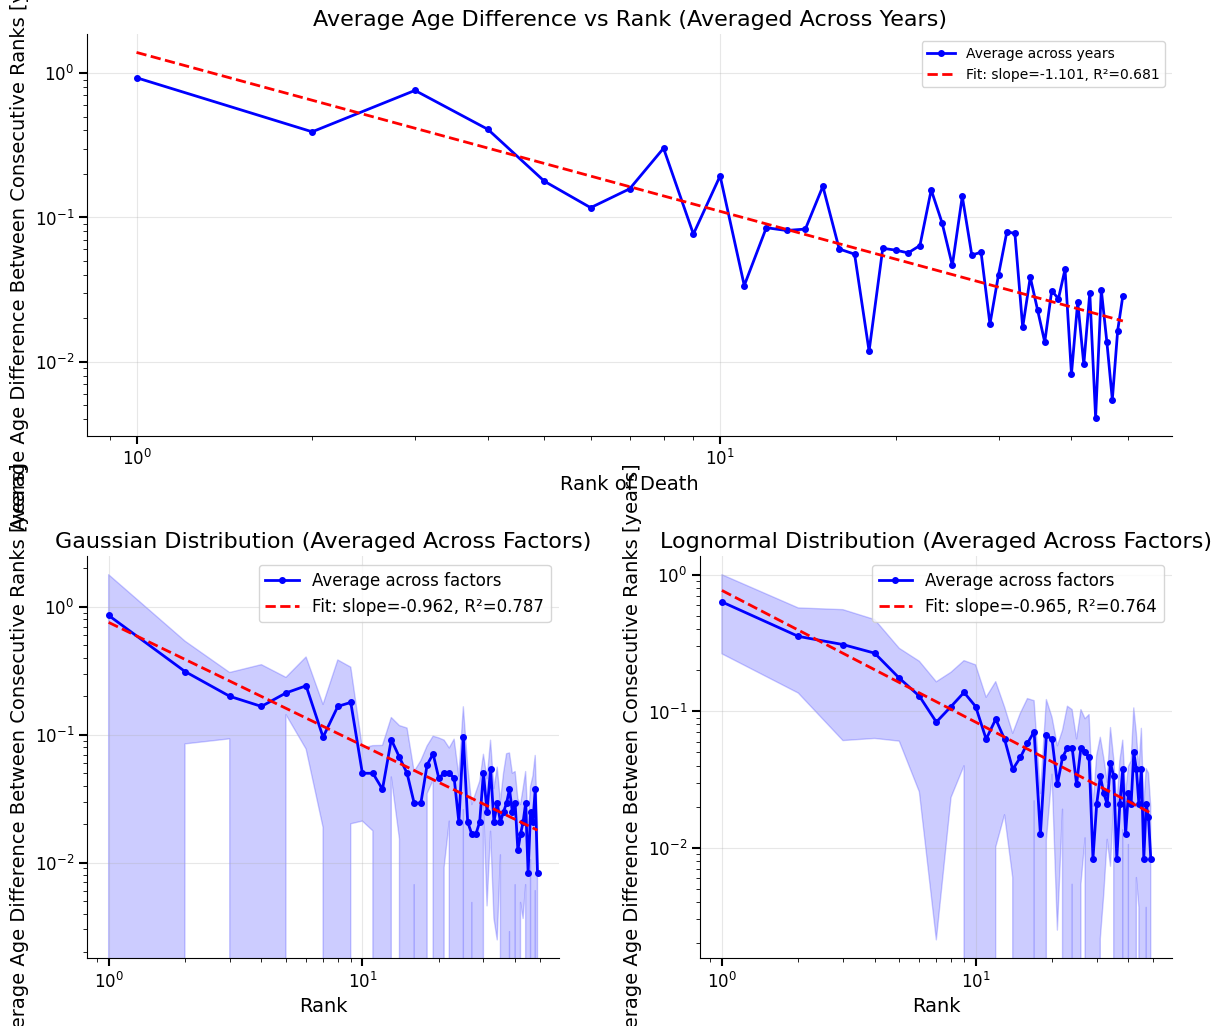

In [10]:
# Define years to plot
years_to_plot = [1990, 2000, 2010]

# Define ranks from 1 to 50
ranks = range(1, 51)

# Load saved results
import pickle
from scipy import stats

# Load the saved results
pickle_filename = 'saved_results/max_lifespan_Xc_factors_1.00to1.50_top50_n10000000_repeats1_both_dists.pkl'

with open(pickle_filename, 'rb') as f:
    results_by_dist = pickle.load(f)

# Create figure with 3 subplots: top row has 1 plot, bottom row has 2 plots
fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Top plot: Average age difference across years for each rank (spans both columns)
ax_top = fig.add_subplot(gs[0, :])

# Collect deltas for each year separately
deltas_by_year = []

for year in years_to_plot:
    # Filter people who died in this year
    died_this_year = df[df['Died'] == year]
    
    if len(died_this_year) > 0:
        # Calculate age at death (death year - birth year + Days/365.25)
        ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
        # Sort ages in descending order
        sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
        
        # Get ages for ranks 1 to 50 (or as many as available)
        ages_for_ranks = []
        for rank in ranks:
            if len(sorted_ages) >= rank:
                ages_for_ranks.append(sorted_ages[rank - 1])
            else:
                ages_for_ranks.append(np.nan)
        
        # Calculate deltas between consecutive ranks for this year
        year_deltas = []
        for j in range(len(ages_for_ranks) - 1):
            if not np.isnan(ages_for_ranks[j]) and not np.isnan(ages_for_ranks[j + 1]):
                delta = ages_for_ranks[j] - ages_for_ranks[j + 1]
                year_deltas.append(delta)
            else:
                year_deltas.append(np.nan)
        
        deltas_by_year.append(year_deltas)

# Calculate average delta for each rank across years
avg_deltas = np.nanmean(deltas_by_year, axis=0)

# Plot the average deltas
ax_top.plot(ranks[:-1], avg_deltas, marker='o', linestyle='-', linewidth=2, markersize=4, 
            color='blue', label='Average across years')

# Fit linear regression on log-log scale
valid_mask = ~np.isnan(avg_deltas) & (avg_deltas > 0)
log_ranks = np.log(np.array(ranks[:-1])[valid_mask])
log_deltas = np.log(avg_deltas[valid_mask])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_ranks, log_deltas)

# Plot the fit
fit_deltas = np.exp(intercept) * np.array(ranks[:-1]) ** slope
ax_top.plot(ranks[:-1], fit_deltas, 'r--', linewidth=2, 
            label=f'Fit: slope={slope:.3f}, R²={r_value**2:.3f}')

ax_top.set_xlabel('Rank of Death', fontsize=14)
ax_top.set_ylabel('Average Age Difference Between Consecutive Ranks [years]', fontsize=14)
ax_top.set_title('Average Age Difference vs Rank (Averaged Across Years)', fontsize=16)
ax_top.set_xscale('log')
ax_top.set_yscale('log')
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# Factors to plot
factors_to_plot = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

# Ranks (1 to 50)
ranks_sim = np.arange(1, 51)

# Bottom left plot: Gaussian distribution - average across factors
ax_left = fig.add_subplot(gs[1, 0])
gaussian_results = results_by_dist['gaussian']

# Collect deltas for each factor separately
all_deltas_gaussian = []
for factor in factors_to_plot:
    # Find the result for this factor
    for result in gaussian_results['factor_results']:
        if np.isclose(result['factor'], factor, atol=0.01):
            mean_by_rank = result['mean_by_rank']
            # Calculate deltas between consecutive ranks
            factor_deltas = -np.diff(mean_by_rank)
            all_deltas_gaussian.append(factor_deltas)
            break

# Average deltas across factors
avg_deltas_gaussian = np.mean(all_deltas_gaussian, axis=0)
std_deltas_gaussian = np.std(all_deltas_gaussian, axis=0)

# Plot average deltas
ax_left.plot(ranks_sim[:-1], avg_deltas_gaussian, marker='o', linestyle='-', linewidth=2, 
            markersize=4, color='blue', label='Average across factors')
ax_left.fill_between(ranks_sim[:-1], avg_deltas_gaussian - std_deltas_gaussian, 
                     avg_deltas_gaussian + std_deltas_gaussian, alpha=0.2, color='blue')

# Fit linear regression on log-log scale
log_ranks_sim = np.log(ranks_sim[:-1])
log_deltas_gaussian = np.log(avg_deltas_gaussian)
slope_g, intercept_g, r_value_g, p_value_g, std_err_g = stats.linregress(log_ranks_sim, log_deltas_gaussian)

# Plot the fit
fit_deltas_gaussian = np.exp(intercept_g) * ranks_sim[:-1] ** slope_g
ax_left.plot(ranks_sim[:-1], fit_deltas_gaussian, 'r--', linewidth=2, 
            label=f'Fit: slope={slope_g:.3f}, R²={r_value_g**2:.3f}')

ax_left.set_xlabel('Rank', fontsize=14)
ax_left.set_ylabel('Average Age Difference Between Consecutive Ranks [years]', fontsize=14)
ax_left.set_title('Gaussian Distribution (Averaged Across Factors)', fontsize=16)
ax_left.set_xscale('log')
ax_left.set_yscale('log')
ax_left.legend(fontsize=12)
ax_left.grid(True, alpha=0.3)

# Bottom right plot: Lognormal distribution - average across factors
ax_right = fig.add_subplot(gs[1, 1])
lognormal_results = results_by_dist['lognormal']

# Collect deltas for each factor separately
all_deltas_lognormal = []
for factor in factors_to_plot:
    # Find the result for this factor
    for result in lognormal_results['factor_results']:
        if np.isclose(result['factor'], factor, atol=0.01):
            mean_by_rank = result['mean_by_rank']
            # Calculate deltas between consecutive ranks
            factor_deltas = -np.diff(mean_by_rank)
            all_deltas_lognormal.append(factor_deltas)
            break

# Average deltas across factors
avg_deltas_lognormal = np.mean(all_deltas_lognormal, axis=0)
std_deltas_lognormal = np.std(all_deltas_lognormal, axis=0)

# Plot average deltas
ax_right.plot(ranks_sim[:-1], avg_deltas_lognormal, marker='o', linestyle='-', linewidth=2, 
             markersize=4, color='blue', label='Average across factors')
ax_right.fill_between(ranks_sim[:-1], avg_deltas_lognormal - std_deltas_lognormal, 
                      avg_deltas_lognormal + std_deltas_lognormal, alpha=0.2, color='blue')

# Fit linear regression on log-log scale
log_deltas_lognormal = np.log(avg_deltas_lognormal)
slope_l, intercept_l, r_value_l, p_value_l, std_err_l = stats.linregress(log_ranks_sim, log_deltas_lognormal)

# Plot the fit
fit_deltas_lognormal = np.exp(intercept_l) * ranks_sim[:-1] ** slope_l
ax_right.plot(ranks_sim[:-1], fit_deltas_lognormal, 'r--', linewidth=2, 
             label=f'Fit: slope={slope_l:.3f}, R²={r_value_l**2:.3f}')

ax_right.set_xlabel('Rank', fontsize=14)
ax_right.set_ylabel('Average Age Difference Between Consecutive Ranks [years]', fontsize=14)
ax_right.set_title('Lognormal Distribution (Averaged Across Factors)', fontsize=16)
ax_right.set_xscale('log')
ax_right.set_yscale('log')
ax_right.legend(fontsize=12)
ax_right.grid(True, alpha=0.3)

plt.show()


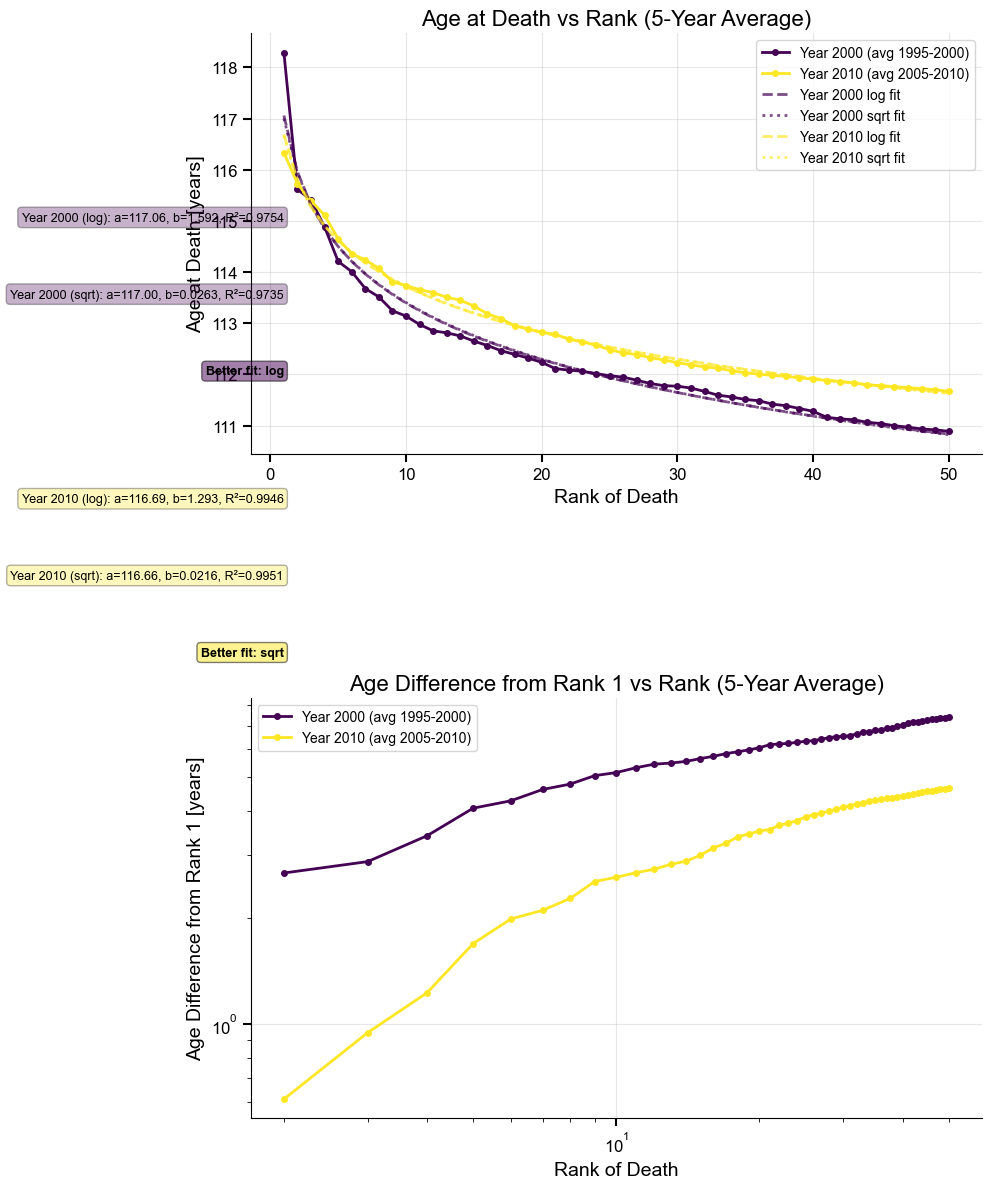

In [53]:
# Define years to plot
years_to_plot = [2000, 2010]

# Define ranks from 1 to 50
ranks = range(1, 51)

# Load saved results
import pickle

# Load the saved results
pickle_filename = 'saved_results/max_lifespan_Xc_factors_1.00to1.50_top50_n10000000_repeats1_both_dists.pkl'

with open(pickle_filename, 'rb') as f:
    results_by_dist = pickle.load(f)

# Create figure with 2 plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# Plot 1: Age at death vs rank for selected years (averaged over 5-year windows)
colors_years = plt.cm.viridis(np.linspace(0, 1, len(years_to_plot)))

# Store data for fitting
fit_data = []

for i, year in enumerate(years_to_plot):
    # Define 5-year window: [year-5, year]
    year_window = range(year - 5, year + 1)
    
    # Collect ages for each rank across all years in the window
    ages_by_rank = {rank: [] for rank in ranks}
    
    for year_in_window in year_window:
        # Filter people who died in this year
        died_this_year = df[df['Died'] == year_in_window]
        
        if len(died_this_year) > 0:
            # Calculate age at death (death year - birth year + Days/365.25)
            ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
            # Sort ages in descending order
            sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
            
            # Get ages for ranks 1 to 50 (or as many as available)
            for rank in ranks:
                if len(sorted_ages) >= rank:
                    ages_by_rank[rank].append(sorted_ages[rank - 1])
    
    # Calculate average age for each rank across the 5-year window
    avg_ages_for_ranks = []
    for rank in ranks:
        if len(ages_by_rank[rank]) > 0:
            avg_ages_for_ranks.append(np.mean(ages_by_rank[rank]))
        else:
            avg_ages_for_ranks.append(np.nan)
    
    # Plot the curve for this year
    ax1.plot(ranks, avg_ages_for_ranks, marker='o', linestyle='-', linewidth=2, markersize=4, 
            color=colors_years[i], label=f'Year {year} (avg {year-5}-{year})')
    
    # Store data for fitting
    fit_data.append({
        'year': year,
        'ranks': np.array(ranks),
        'ages': np.array(avg_ages_for_ranks),
        'color': colors_years[i]
    })

# Fit a - b*log(rank) for each curve
from scipy.optimize import curve_fit

def fit_func_log(rank, a, b):
    return a - b * np.log(rank)

def fit_func_sqrt(rank, a, b):
    return a * np.sqrt(1 - b * np.log(rank))

def calculate_r_squared(y_true, y_pred):
    """Calculate R-squared value"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

for i, data in enumerate(fit_data):
    # Filter out NaN values
    valid_mask = ~np.isnan(data['ages'])
    valid_ranks = data['ranks'][valid_mask]
    valid_ages = data['ages'][valid_mask]
    
    if len(valid_ranks) > 0:
        # Fit the log function
        popt_log, _ = curve_fit(fit_func_log, valid_ranks, valid_ages)
        a_fit_log, b_fit_log = popt_log
        
        # Generate fitted curve for log
        fitted_ages_log = fit_func_log(valid_ranks, a_fit_log, b_fit_log)
        
        # Calculate R-squared for log fit
        r2_log = calculate_r_squared(valid_ages, fitted_ages_log)
        
        # Plot fitted curve for log
        ax1.plot(valid_ranks, fitted_ages_log, linestyle='--', linewidth=2, 
                color=data['color'], alpha=0.7, label=f'Year {data["year"]} log fit')
        
        # Fit the sqrt function
        popt_sqrt, _ = curve_fit(fit_func_sqrt, valid_ranks, valid_ages, p0=[120, 0.01])
        a_fit_sqrt, b_fit_sqrt = popt_sqrt
        
        # Generate fitted curve for sqrt
        fitted_ages_sqrt = fit_func_sqrt(valid_ranks, a_fit_sqrt, b_fit_sqrt)
        
        # Calculate R-squared for sqrt fit
        r2_sqrt = calculate_r_squared(valid_ages, fitted_ages_sqrt)
        
        # Plot fitted curve for sqrt
        ax1.plot(valid_ranks, fitted_ages_sqrt, linestyle=':', linewidth=2, 
                color=data['color'], alpha=0.7, label=f'Year {data["year"]} sqrt fit')
        
        # Determine which fit is better
        better_fit = "log" if r2_log > r2_sqrt else "sqrt"
        
        # Add text annotation with fit parameters and R-squared values
        text_y_pos = 115 - i * 5.5  # Stagger text positions more to accommodate extra line
        ax1.text(0.98, text_y_pos, f'Year {data["year"]} (log): a={a_fit_log:.2f}, b={b_fit_log:.3f}, R²={r2_log:.4f}',
                transform=ax1.transData, fontsize=9, ha='right',
                bbox=dict(boxstyle='round', facecolor=data['color'], alpha=0.3))
        ax1.text(0.98, text_y_pos - 1.5, f'Year {data["year"]} (sqrt): a={a_fit_sqrt:.2f}, b={b_fit_sqrt:.4f}, R²={r2_sqrt:.4f}',
                transform=ax1.transData, fontsize=9, ha='right',
                bbox=dict(boxstyle='round', facecolor=data['color'], alpha=0.3))
        ax1.text(0.98, text_y_pos - 3.0, f'Better fit: {better_fit}',
                transform=ax1.transData, fontsize=9, ha='right', weight='bold',
                bbox=dict(boxstyle='round', facecolor=data['color'], alpha=0.5))

ax1.set_xlabel('Rank of Death', fontsize=14)
ax1.set_ylabel('Age at Death [years]', fontsize=14)
ax1.set_title('Age at Death vs Rank (5-Year Average)', fontsize=16)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Age at death relative to rank 1 (log-log scale)
for i, year in enumerate(years_to_plot):
    # Define 5-year window: [year-5, year]
    year_window = range(year - 5, year + 1)
    
    # Collect ages for each rank across all years in the window
    ages_by_rank = {rank: [] for rank in ranks}
    
    for year_in_window in year_window:
        # Filter people who died in this year
        died_this_year = df[df['Died'] == year_in_window]
        
        if len(died_this_year) > 0:
            # Calculate age at death (death year - birth year + Days/365.25)
            ages_at_death = (died_this_year['Died'] - died_this_year['Born']) + died_this_year['Days'] / 365.25
            # Sort ages in descending order
            sorted_ages = ages_at_death.sort_values(ascending=False).reset_index(drop=True)
            
            # Get ages for ranks 1 to 50 (or as many as available)
            for rank in ranks:
                if len(sorted_ages) >= rank:
                    ages_by_rank[rank].append(sorted_ages[rank - 1])
    
    # Calculate average age for each rank across the 5-year window
    avg_ages_for_ranks = []
    for rank in ranks:
        if len(ages_by_rank[rank]) > 0:
            avg_ages_for_ranks.append(np.mean(ages_by_rank[rank]))
        else:
            avg_ages_for_ranks.append(np.nan)
    
    # Subtract rank 1 value from all ranks
    if not np.isnan(avg_ages_for_ranks[0]):
        rank_1_age = avg_ages_for_ranks[0]
        relative_ages = [rank_1_age - age if not np.isnan(age) else np.nan for age in avg_ages_for_ranks]
        
        # Filter out NaN values and corresponding ranks
        valid_indices = [j for j, age in enumerate(relative_ages) if not np.isnan(age) and age > 0]
        valid_ranks = [ranks[j] for j in valid_indices]
        valid_relative_ages = [relative_ages[j] for j in valid_indices]
        
        # Plot the curve for this year
        ax2.plot(valid_ranks, valid_relative_ages, marker='o', linestyle='-', linewidth=2, markersize=4, 
                color=colors_years[i], label=f'Year {year} (avg {year-5}-{year})')

ax2.set_xlabel('Rank of Death', fontsize=14)
ax2.set_ylabel('Age Difference from Rank 1 [years]', fontsize=14)
ax2.set_title('Age Difference from Rank 1 vs Rank (5-Year Average)', fontsize=16)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
